%pip install seaborn

In [2]:
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np

# Helper Functions

**Note on duplication (added 2026-09-22, Human-PI authorized: Nick, "Делай").** Most figure-generating sections below re-declare their own copy of `reformat_allele`/`get_dynamic_loci`/`build_global_valid`/`score_pair` instead of importing one shared version -- several cells say so explicitly ("COPY OVER BULK-SCORING HELPERS", "verbatim from cell ..."). This is deliberate, not an oversight: each figure's cell stays readable and reproducible on its own, without needing execution order traced across the whole notebook, and ties each figure to `results_summary.md`'s tables "by construction, not by coincidence."

The risk this creates is **drift**, not duplication per se: a fix landing in one copy (like the 2026-07-25 `:xx` fix a few cells down) can silently fail to reach the others, because `def reformat_allele` in one cell and `def reformat_allele` in another are two unrelated Python objects that happen to share a name -- confirmed the hard way this session, twice: once as a genuine miss (Fig 5/6a/6b/6c's copies lacked the fix for two months) and once as a false alarm (a dead diagnostic cell's `calculate_accuracy` was mistaken for a live dependency of Fig 9 because of the name collision, before tracing every call site proved otherwise).

**The invariant, going forward:** every copy of these four functions that can ever see a dataset with a gold-standard `:xx` token (currently only D3: `A*68:xx`, `B*55:xx`) must drop `None` out of `gs_set`/`valid[...]` before using it, and must skip (not crash on, not silently mis-score) a locus-slot whose GS was `:xx`-only. As of 2026-09-22 every remaining copy in this notebook satisfies that, including the ancestry/read-length cells (Fig 8-11) where it was previously missing -- verified inert on their actual data (Fig 8 uses `readlength_gs.csv`, Fig 9-11 are hardcoded to dataset 1, and D3 is the only dataset with `:xx` tokens) but now robust if that ever changes, instead of relying on that being true forever by luck.

### New Accuracy Script

Per‐sample “true” set (gs_set) — the one or two alleles actually present in that sample at that locus

Global reference set (valid_set) — the union of all alleles ever seen in your GS cohort at that locus

Then, for each predicted allele:

If it ∉ global valid_set → it’s truly novel (i.e. “filtered”)

Else if it ∉ sample gs_set → it’s a misprediction of a known allele

Else it’s a correct call

The easiest way to see it is:

Per-sample “true” set (gs_set)

What it is: the exact allele (or small handful of phase-ambiguous alleles) that your gold-standard says that particular sample actually carries at that locus.

Where you get it: directly from the GS spreadsheet for that one sample. For example, if Sample ERR123 has HLA-A = "A*02:01/A*02:04" in your 1_gs.csv, then

gs_raw = ["A*02:01", "A*02:04"]
gs_set = {"A*02:01", "A*02:04"}
That set is “what we believe is truly in that person’s genome here.”

Global reference set (valid_set)

What it is: the universe of all alleles that ever show up in your entire gold-standard cohort at that locus. In other words, “every allele we’ve ever seen in any of our samples’ GS calls.”

Where you get it: by scanning all rows of your GS file once up‐front and collating. For each locus you do something like:
valid_set[locus] = set()
for every sample_row in gs_df:
for each allele in sample_row[locus]_gs and [locus].1_gs:
valid_set[locus].add(formatted_allele)
At the end, valid_set["A"] might be

{"A*01:01", "A*01:02", "A*02:01", "A*02:04", "A*03:01", …}
—everything you’ve ever observed at HLA-A across your cohort.

In [3]:
def reformat_allele(allele: str, resolution: int = 2):
    """
    "xx" 2nd field = unresolved (not corruption): resolution=2 returns None,
    callers must discard it from gs/valid sets; resolution=1 unaffected.
    """
    a = allele.strip()
    if "*" not in a:
        return a
    gene, rest = a.split("*", 1)
    parts = rest.split(":")
    if resolution == 1:
        return f"{gene}*{parts[0]}"
    else:
        if len(parts) < 2:
            return f"{gene}*{parts[0]}"
        if parts[1].lower() == "xx":
            return None
        return f"{gene}*{parts[0]}:{parts[1]}"

In [4]:
def get_dynamic_loci(gs_df: pd.DataFrame) -> list:
    return sorted({c.split(".")[0] for c in gs_df.columns[1:]})

In [5]:
def build_global_valid(gs_df: pd.DataFrame, resolution: int=2) -> dict:
    loci = get_dynamic_loci(gs_df)
    valid = {L:set() for L in loci}
    for _, row in gs_df.iterrows():
        for L in loci:
            for suf in ("", ".1"):
                col = f"{L}{suf}"
                if col in row and pd.notna(row[col]):
                    for a in str(row[col]).split("/"):
                        fa = reformat_allele(a, resolution)
                        if fa is not None:   # CHANGED 2026-07-25: drop ":xx" tokens
                            valid[L].add(fa)
    return valid

In [6]:
def score_pair(gs_raw, pr_raw, valid_global, resolution=2):
    # CHANGED 2026-07-25: drop ":xx"-derived None entries from gs_set. If
    # NOTHING is left (this locus-slot's only GS token(s) were ":xx"), the
    # whole slot is unscorable at this resolution -- signalled by returning
    # None so the caller can skip it entirely (not count it in the
    # denominator at all), rather than silently scoring against an empty set.
    gs_set = {reformat_allele(a, resolution) for a in gs_raw}
    gs_set.discard(None)
    if not gs_set:
        return None
    # normalize predictions to two slots
    if   len(pr_raw)==0:
        pair=[None,None]
    elif len(pr_raw)==1:
        pair=[pr_raw[0],pr_raw[0]]
    else:
        pair=pr_raw[:2]
    correct=miscalled=novel=no_call=0
    for allele in pair:
        if allele is None:
            no_call+=1
        else:
            fmt=reformat_allele(allele, resolution)
            if fmt not in valid_global:
                novel+=1
            elif fmt in gs_set:
                correct+=1
            else:
                miscalled+=1
    return correct, miscalled, novel, no_call

In [7]:
def get_pr_loci(pr_df: pd.DataFrame) -> set:
    s=set()
    for L in ["A","B","C","DRB1","DQB1"]:
        if f"{L}_pre" in pr_df.columns or f"{L}.1_pre" in pr_df.columns:
            s.add(L)
    return s

In [8]:
def aggregate_counts_per_tool_locus(tools, ds_nums, gs_dir, pr_dir,
                                    resolution=2, filter_option=False):
    classical=["A","B","C","DRB1","DQB1"]
    counts={t:{L:{"correct":0,"miscalled":0,"novel":0,"no_call":0,"total_calls":0}
               for L in classical}
            for t in tools}
    for t in tools:
        for ds in ds_nums:
            try:
                gs_df=pd.read_csv(f"{gs_dir}/{ds}_gs.csv",dtype=str)
                pr_df=pd.read_csv(f"{pr_dir}/{t}_d{ds}.csv",dtype=str)
            except FileNotFoundError:
                continue

            # strip IDs
            gs_df.iloc[:,0]=gs_df.iloc[:,0].str.strip()
            pr_df.iloc[:,0]=pr_df.iloc[:,0].str.strip()
            # rename pr columns
            rename={c:f"{c}_pre" for c in pr_df.columns if c!=pr_df.columns[0]}
            pr_df=pr_df.rename(columns=rename)

            supported=get_pr_loci(pr_df)
            all_loci = get_dynamic_loci(gs_df)
            valid    = build_global_valid(gs_df,resolution)
            merged   = pd.merge(gs_df, pr_df,
                                left_on=gs_df.columns[0],
                                right_on=pr_df.columns[0],
                                how="inner")

            for _,row in merged.iterrows():
                # penalize unsupported loci
                for L in classical:
                    if L in all_loci and L not in supported:
                        counts[t][L]["total_calls"]+=2
                        counts[t][L]["no_call"]    +=2

                # score supported
                for L in supported:
                    if L not in all_loci:
                        continue
                    # GS alleles
                    gs_raw=[]
                    for suf in ("",".1"):
                        col=f"{L}{suf}"
                        if col in row and pd.notna(row[col]):
                            gs_raw += [x.strip() for x in str(row[col]).split("/")]
                    if not gs_raw:
                        continue
                    # PR alleles
                    pr_raw=[]
                    for suf in ("_pre",".1_pre"):
                        col=f"{L}{suf}"
                        if col in row and pd.notna(row[col]):
                            pr_raw += [x.strip() for x in str(row[col]).split("/")]
                    result = score_pair(gs_raw,pr_raw,valid[L],resolution)
                    if result is None:
                        # CHANGED 2026-07-25: this slot's only GS token(s) were
                        # ":xx" (field-2-unresolved) -- excluded entirely from
                        # 2-field scoring, not counted in total_calls either.
                        continue
                    counts[t][L]["total_calls"]+=2
                    c,m,n,nc = result
                    if filter_option:
                        counts[t][L]["correct"]   +=c
                        counts[t][L]["miscalled"] +=m
                        counts[t][L]["novel"]     +=n
                        counts[t][L]["no_call"]   +=nc
                    else:
                        counts[t][L]["correct"]   +=c
                        counts[t][L]["miscalled"] +=(m+n)
                        counts[t][L]["no_call"]   +=nc
    return counts

In [9]:
def compute_all_metrics(*, tools, dataset_nums, gs_dir, pr_dir,
                        resolution=2, filter_option=False,
                        with_raw_counts=False):
    classI = ["A","B","C"]
    classII= ["DRB1","DQB1"]
    by_tool = aggregate_counts_per_tool_locus(
        tools, dataset_nums, gs_dir, pr_dir,
        resolution, filter_option
    )
    rows=[]
    for t,lc in by_tool.items():
        ci   = sum(lc[L]["correct"]    for L in classI)
        misI = sum(lc[L]["miscalled"]  for L in classI)
        novI = sum(lc[L]["novel"]      for L in classI)
        ncI  = sum(lc[L]["no_call"]    for L in classI)
        callsI=sum(lc[L]["total_calls"]for L in classI)

        cii   = sum(lc[L]["correct"]    for L in classII)
        misII = sum(lc[L]["miscalled"]  for L in classII)
        novII = sum(lc[L]["novel"]      for L in classII)
        ncII  = sum(lc[L]["no_call"]    for L in classII)
        callsII=sum(lc[L]["total_calls"]for L in classII)

        correct_all = ci + cii
        calls_all   = callsI + callsII
        coverage    = sum(1 for L in ["A","B","C","DRB1","DQB1"]
                          if lc[L]["total_calls"]>0)/5.0

        # filtered: exclude novel from denominator
        denomI    = (callsI    - novI)         if filter_option else callsI
        denomII   = (callsII   - novII)        if filter_option else callsII
        denom_all = (calls_all - novI - novII) if filter_option else calls_all
        base = {
            "Tool":t,
            "ClassI_acc":  None if denomI==0    else ci          /denomI,
            "ClassII_acc": None if denomII==0   else cii         /denomII,
            "Overall_acc": None if denom_all==0 else correct_all /denom_all,
            "Coverage_frac":coverage
        }
        if with_raw_counts:
            base.update({
                "ClassI_Correct":   ci,   "ClassI_Miscalled": misI,
                "ClassI_Novel":     novI, "ClassI_NoCall":    ncI,
                "ClassI_TotalCalls":callsI,
                "ClassII_Correct":  cii,  "ClassII_Miscalled": misII,
                "ClassII_Novel":    novII,"ClassII_NoCall":   ncII,
                "ClassII_TotalCalls":callsII,
                "TotalCorrect":     correct_all,
                "TotalMiscalled":   misI+misII,
                "TotalNovel":       novI+novII,
                "TotalNoCall":      ncI+ncII,
                "TotalCalls":       calls_all
            })
        rows.append(base)
    return pd.DataFrame(rows)

# Color Palette

In [10]:
palette = {
    # HLA name fields
    '1st field':   '#A1D99B',
    '2nd field':   '#31A354',

    # Call types
    'Correct':     '#4CAF50',
    'Miscalled':   '#FF9800',
    'Novel':       '#9C27B0',
    'No-call':     '#F44336',

    # Locus labels
    'A':           '#e41a1c',
    'B':           '#377eb8',
    'C':           '#4daf4a',
    'DQB1':       '#984ea3',
    'DRB1':        '#ff7f00',

    # Populations
    'Europe':      '#1b9e77',
    'Yoruba':      '#d95f02',

    # HLA‐caller tools
    'Optitype':        '#8dd3c7',
    'HLA-HD':          '#ffffb3',
    'PHLAT':           '#bebada',
    'HLAforest':       '#fb8072',
    'arcasHLA':        '#80b1d3',
    'HLAMiner':        '#fdb462',
    'rna2hla':         '#b3de69',
    'seq2HLA':         '#fccde5',
    'HLAvbseq':        '#d9d9d9',
    'Hisat-Genotype':  '#bc80bd',
    'HLApers':         '#ccebc5',
    'T1K':             '#ffed6f',
}


# Plot Settings

In [11]:
# 1) Seaborn theme
sns.set_theme(
    context="paper",   # "paper", "notebook", "talk", "poster"
    style="white",    # "darkgrid", "white", "ticks", …
    font="sans-serif",    # global font family
    font_scale=1.1        # scale all font sizes by this factor
)

# 2) Matplotlib rcParams
plt.rcParams.update({
    # Figure
    "figure.figsize":    (20, 10),
    "figure.dpi":        300,

    # Axes
    "axes.titlesize":    16,
    "axes.titleweight":  "bold",
    "axes.labelsize":    14,

    # Ticks
    "xtick.labelsize":   18,
    "ytick.labelsize":   18,

    # Legend
    "legend.fontsize":   18,
    "legend.title_fontsize": 18,

    # Lines/markers
    "lines.linewidth":   2,
    "lines.markersize":  6,
})

# Accuracy by Dataset

# Figure 3 & 4: Bulk Accuracy Scoring

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# 2) PULL METRICS & BUILD df_plot
# ─────────────────────────────────────────────────────────────────────────────

tools    = ["arcas","optitype","seq2hla","hlaminer",
            "phlat","hlavbseq","hlahd","hisat","hlaforest","hlapers","T1K","rna2hla"]
ds_nums  = list(range(1,7))
gs_dir   = "../datasets"
pr_dir   = "../results/standard"

# unfiltered & filtered at 1- and 2-field, with raw counts
df_unf_1 = compute_all_metrics(tools=tools, dataset_nums=ds_nums,
                                gs_dir=gs_dir, pr_dir=pr_dir,
                                resolution=1, filter_option=False,
                                with_raw_counts=True)
df_flt_1 = compute_all_metrics(tools=tools, dataset_nums=ds_nums,
                                gs_dir=gs_dir, pr_dir=pr_dir,
                                resolution=1, filter_option=True,
                                with_raw_counts=True)
df_unf_2 = compute_all_metrics(tools=tools, dataset_nums=ds_nums,
                                gs_dir=gs_dir, pr_dir=pr_dir,
                                resolution=2, filter_option=False,
                                with_raw_counts=True)
df_flt_2 = compute_all_metrics(tools=tools, dataset_nums=ds_nums,
                                gs_dir=gs_dir, pr_dir=pr_dir,
                                resolution=2, filter_option=True,
                                with_raw_counts=True)

def prep(df, mode, field):
    d = df.copy()
    d["Mode"] = mode
    d["Field"]= field
    d["NoCallRate"] = d["TotalNoCall"] / d["TotalCalls"]
    d = d.rename(columns={"Overall_acc":"Accuracy"})
    return d

pieces = [
    prep(df_unf_1, "pre-filter", "1-field"),
    prep(df_flt_1,  "filtered",   "1-field"),
    prep(df_unf_2, "pre-filter",  "2-field"),
    prep(df_flt_2,  "filtered",    "2-field"),
]
df_plot = pd.concat(pieces, ignore_index=True)


## Figure 3a: Bulk Accuracy

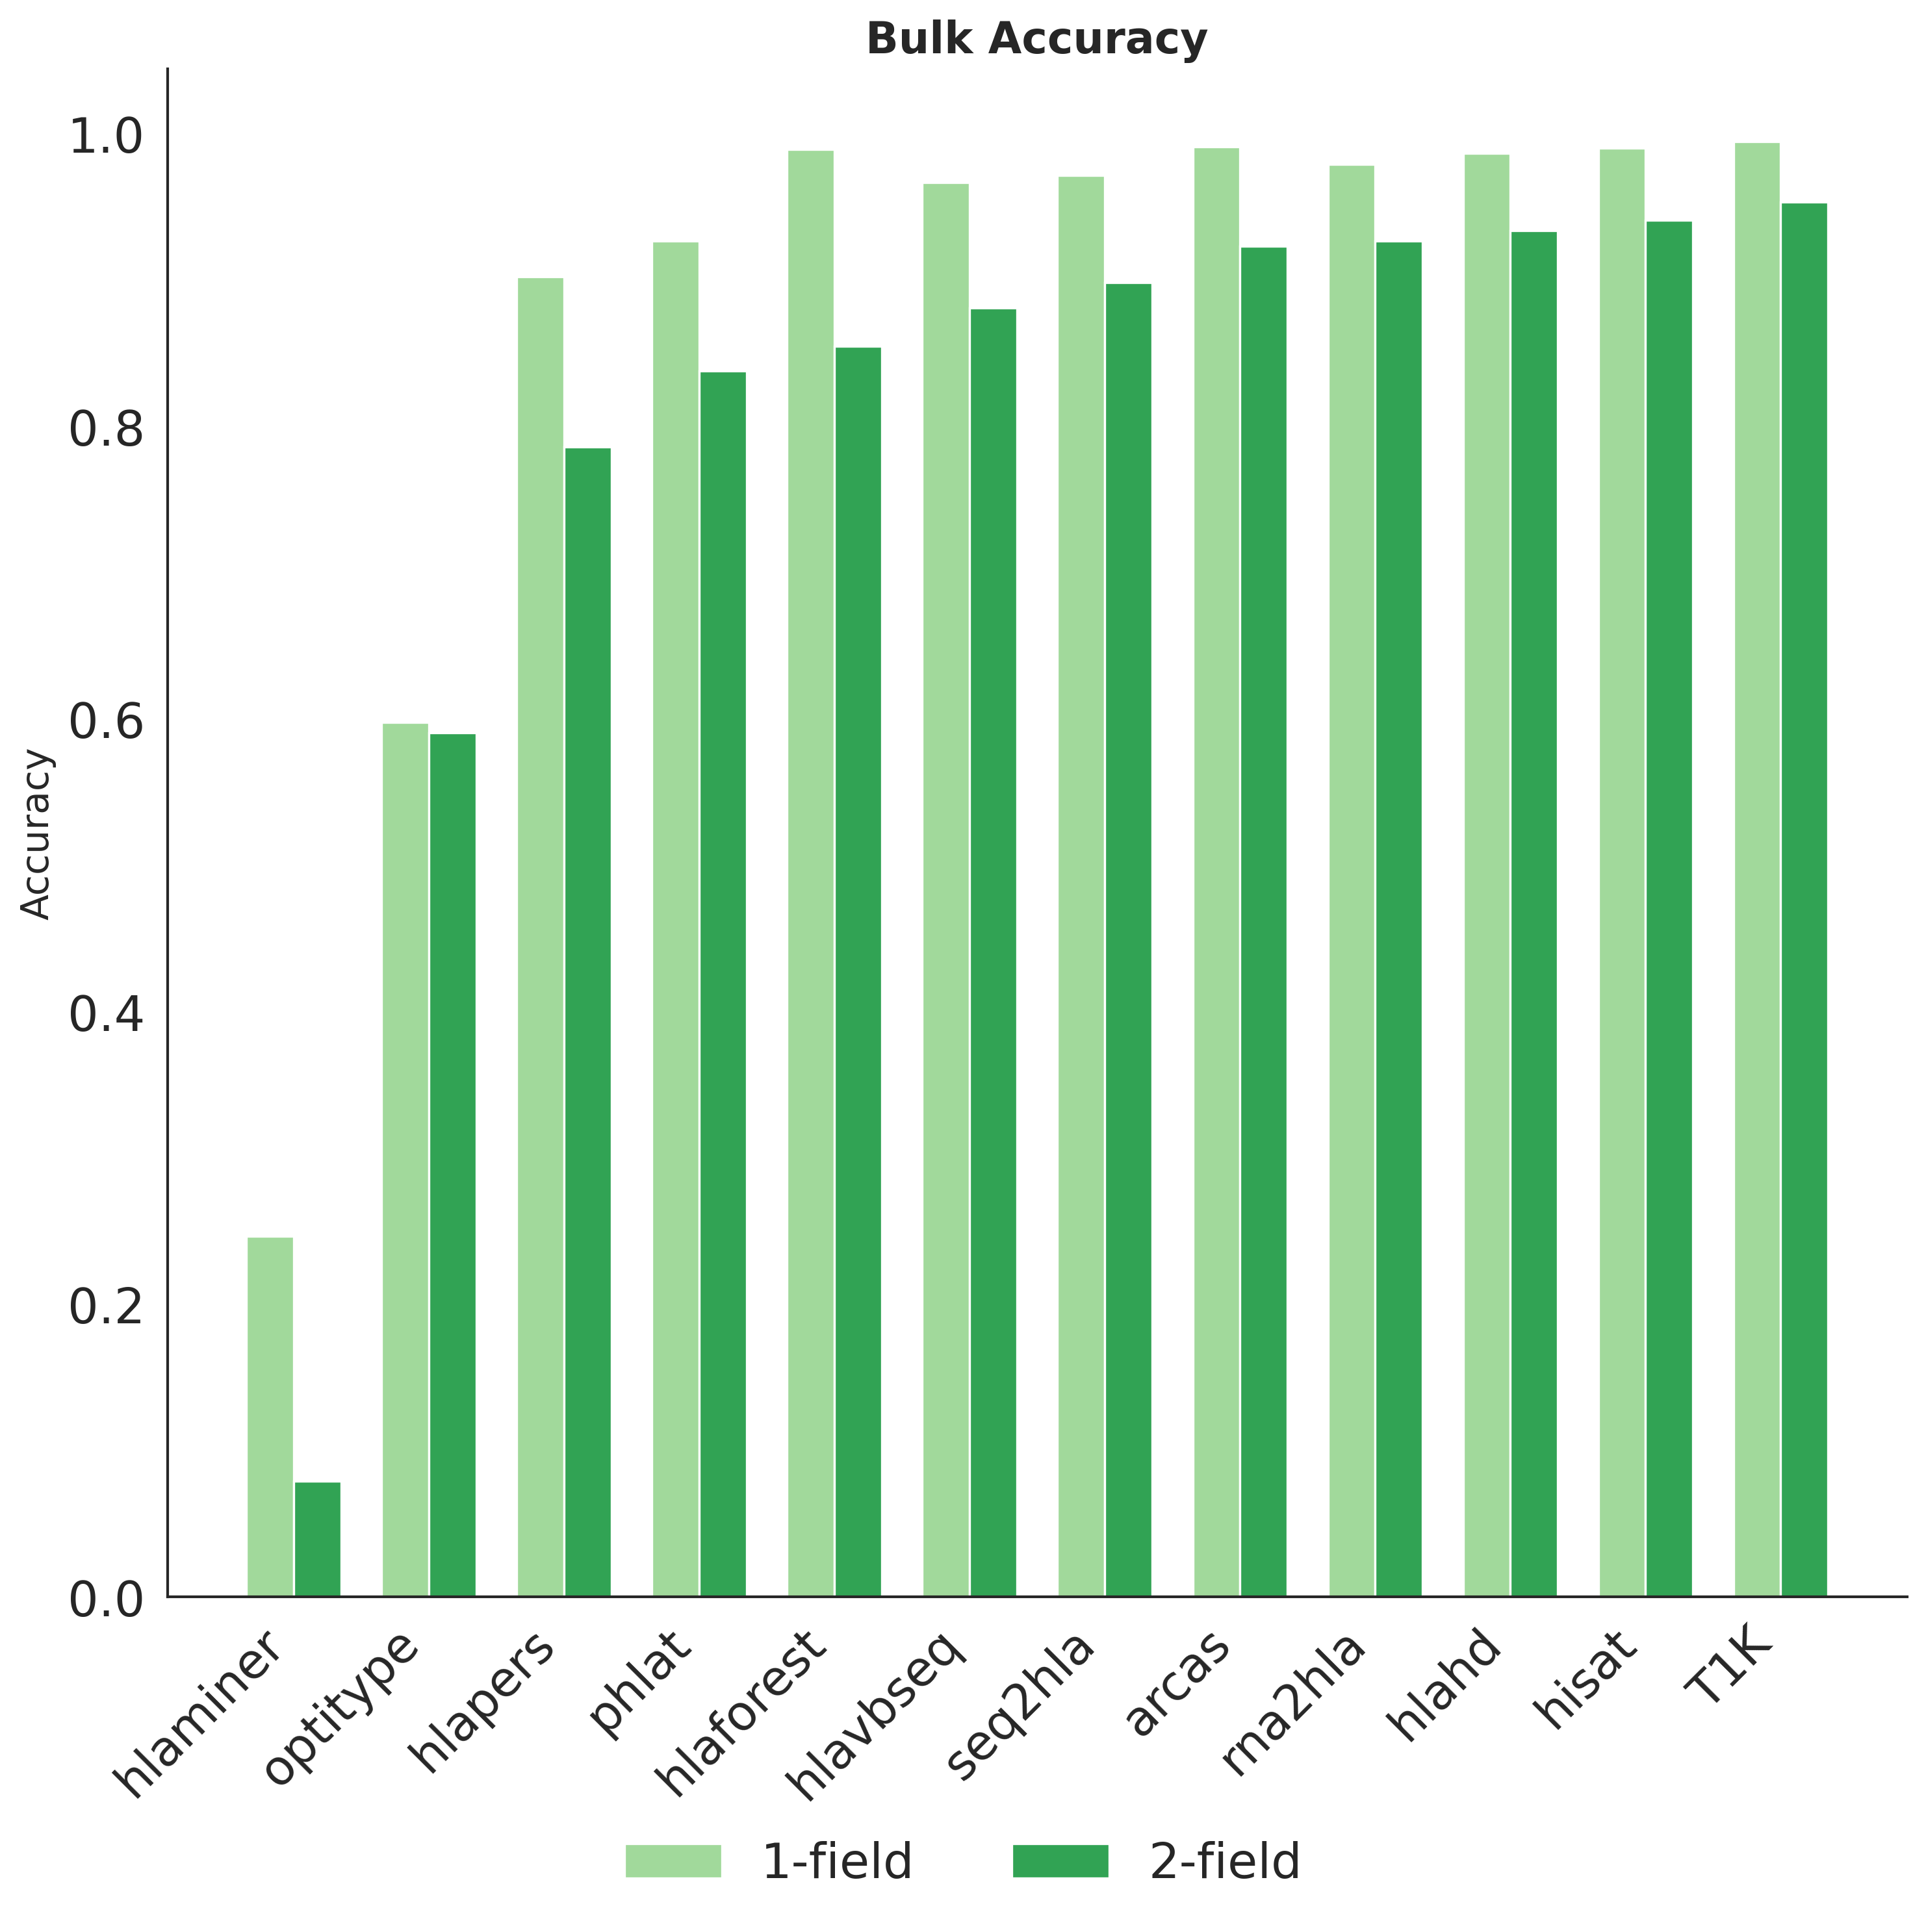

In [13]:
#──────────────────────────────────────────────────────────────────────
# 3) FIGURE 3a: Bulk accuracy (unfiltered),
#    ordered ascending by 2-field accuracy
# ─────────────────────────────────────────────────────────────────────────

# pivot unfiltered accuracy values
dff2 = (
    df_plot
    .query("Mode=='pre-filter' and Field in ['1-field','2-field']")
    .pivot(index="Tool", columns="Field", values="Accuracy")
)

# determine new order by ascending two-field accuracy
tools_order = dff2["2-field"].sort_values(ascending=True).index.tolist()
# reindex so bars follow that order
dff2 = dff2.loc[tools_order]

# x-axis positions
x = np.arange(len(tools_order))
w = 0.35

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# one- vs two-field accuracy
ax.bar(x - w/2, dff2["1-field"], width=w, color=palette["1st field"], label="1-field")
ax.bar(x + w/2, dff2["2-field"], width=w, color=palette["2nd field"], label="2-field")
ax.set_xticks(x)
ax.set_xticklabels(tools_order, rotation=45, ha="right")
ax.set_ylabel("Accuracy")
ax.set_title("Bulk Accuracy")
sns.despine(ax=ax)

# legend
legend_handles = [
    Patch(facecolor=palette["1st field"], label="1-field"),
    Patch(facecolor=palette["2nd field"], label="2-field")
]
fig.legend(handles=legend_handles, loc="lower center", ncol=2, frameon=False)

plt.tight_layout(rect=[0,0.05,1,1])
plt.gcf().savefig("../Figures/fig3a_bulk_accuracy.png", dpi=300, bbox_inches="tight")
plt.gcf().savefig("../Figures/fig3a_bulk_accuracy.svg", bbox_inches="tight")
plt.show()


## Figure 3b: Filtered Bulk Accuracy by Class 

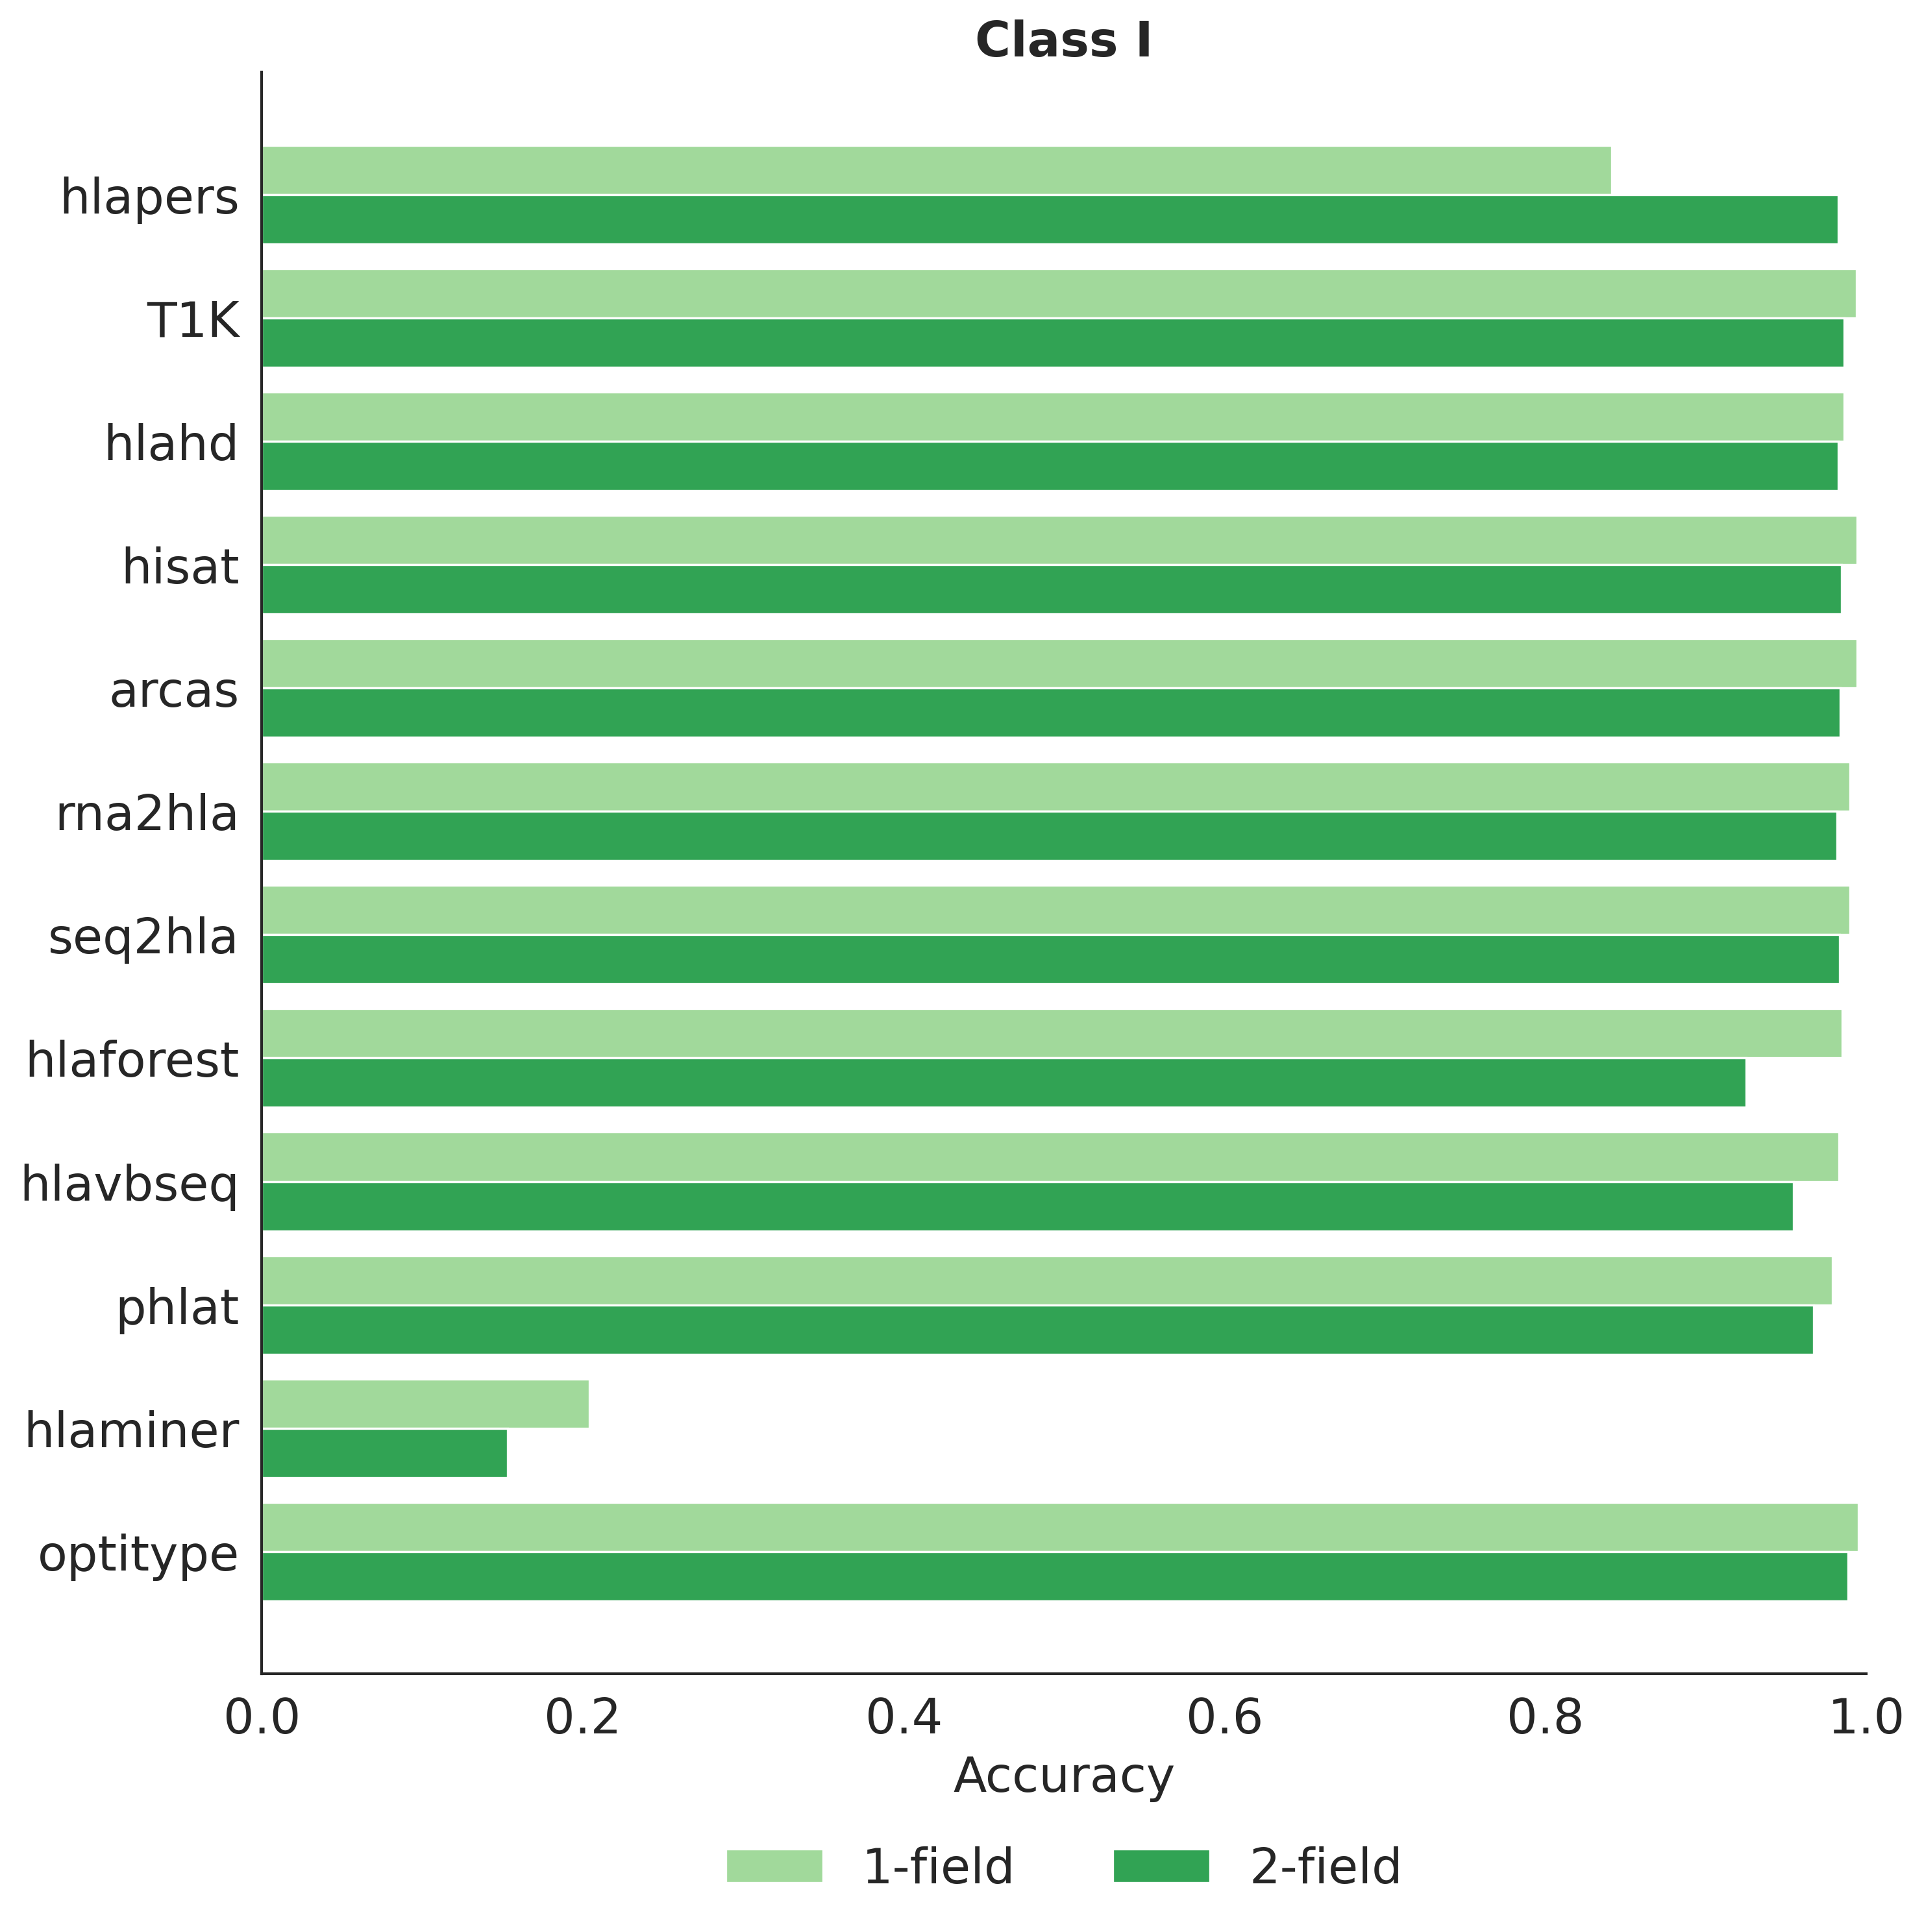

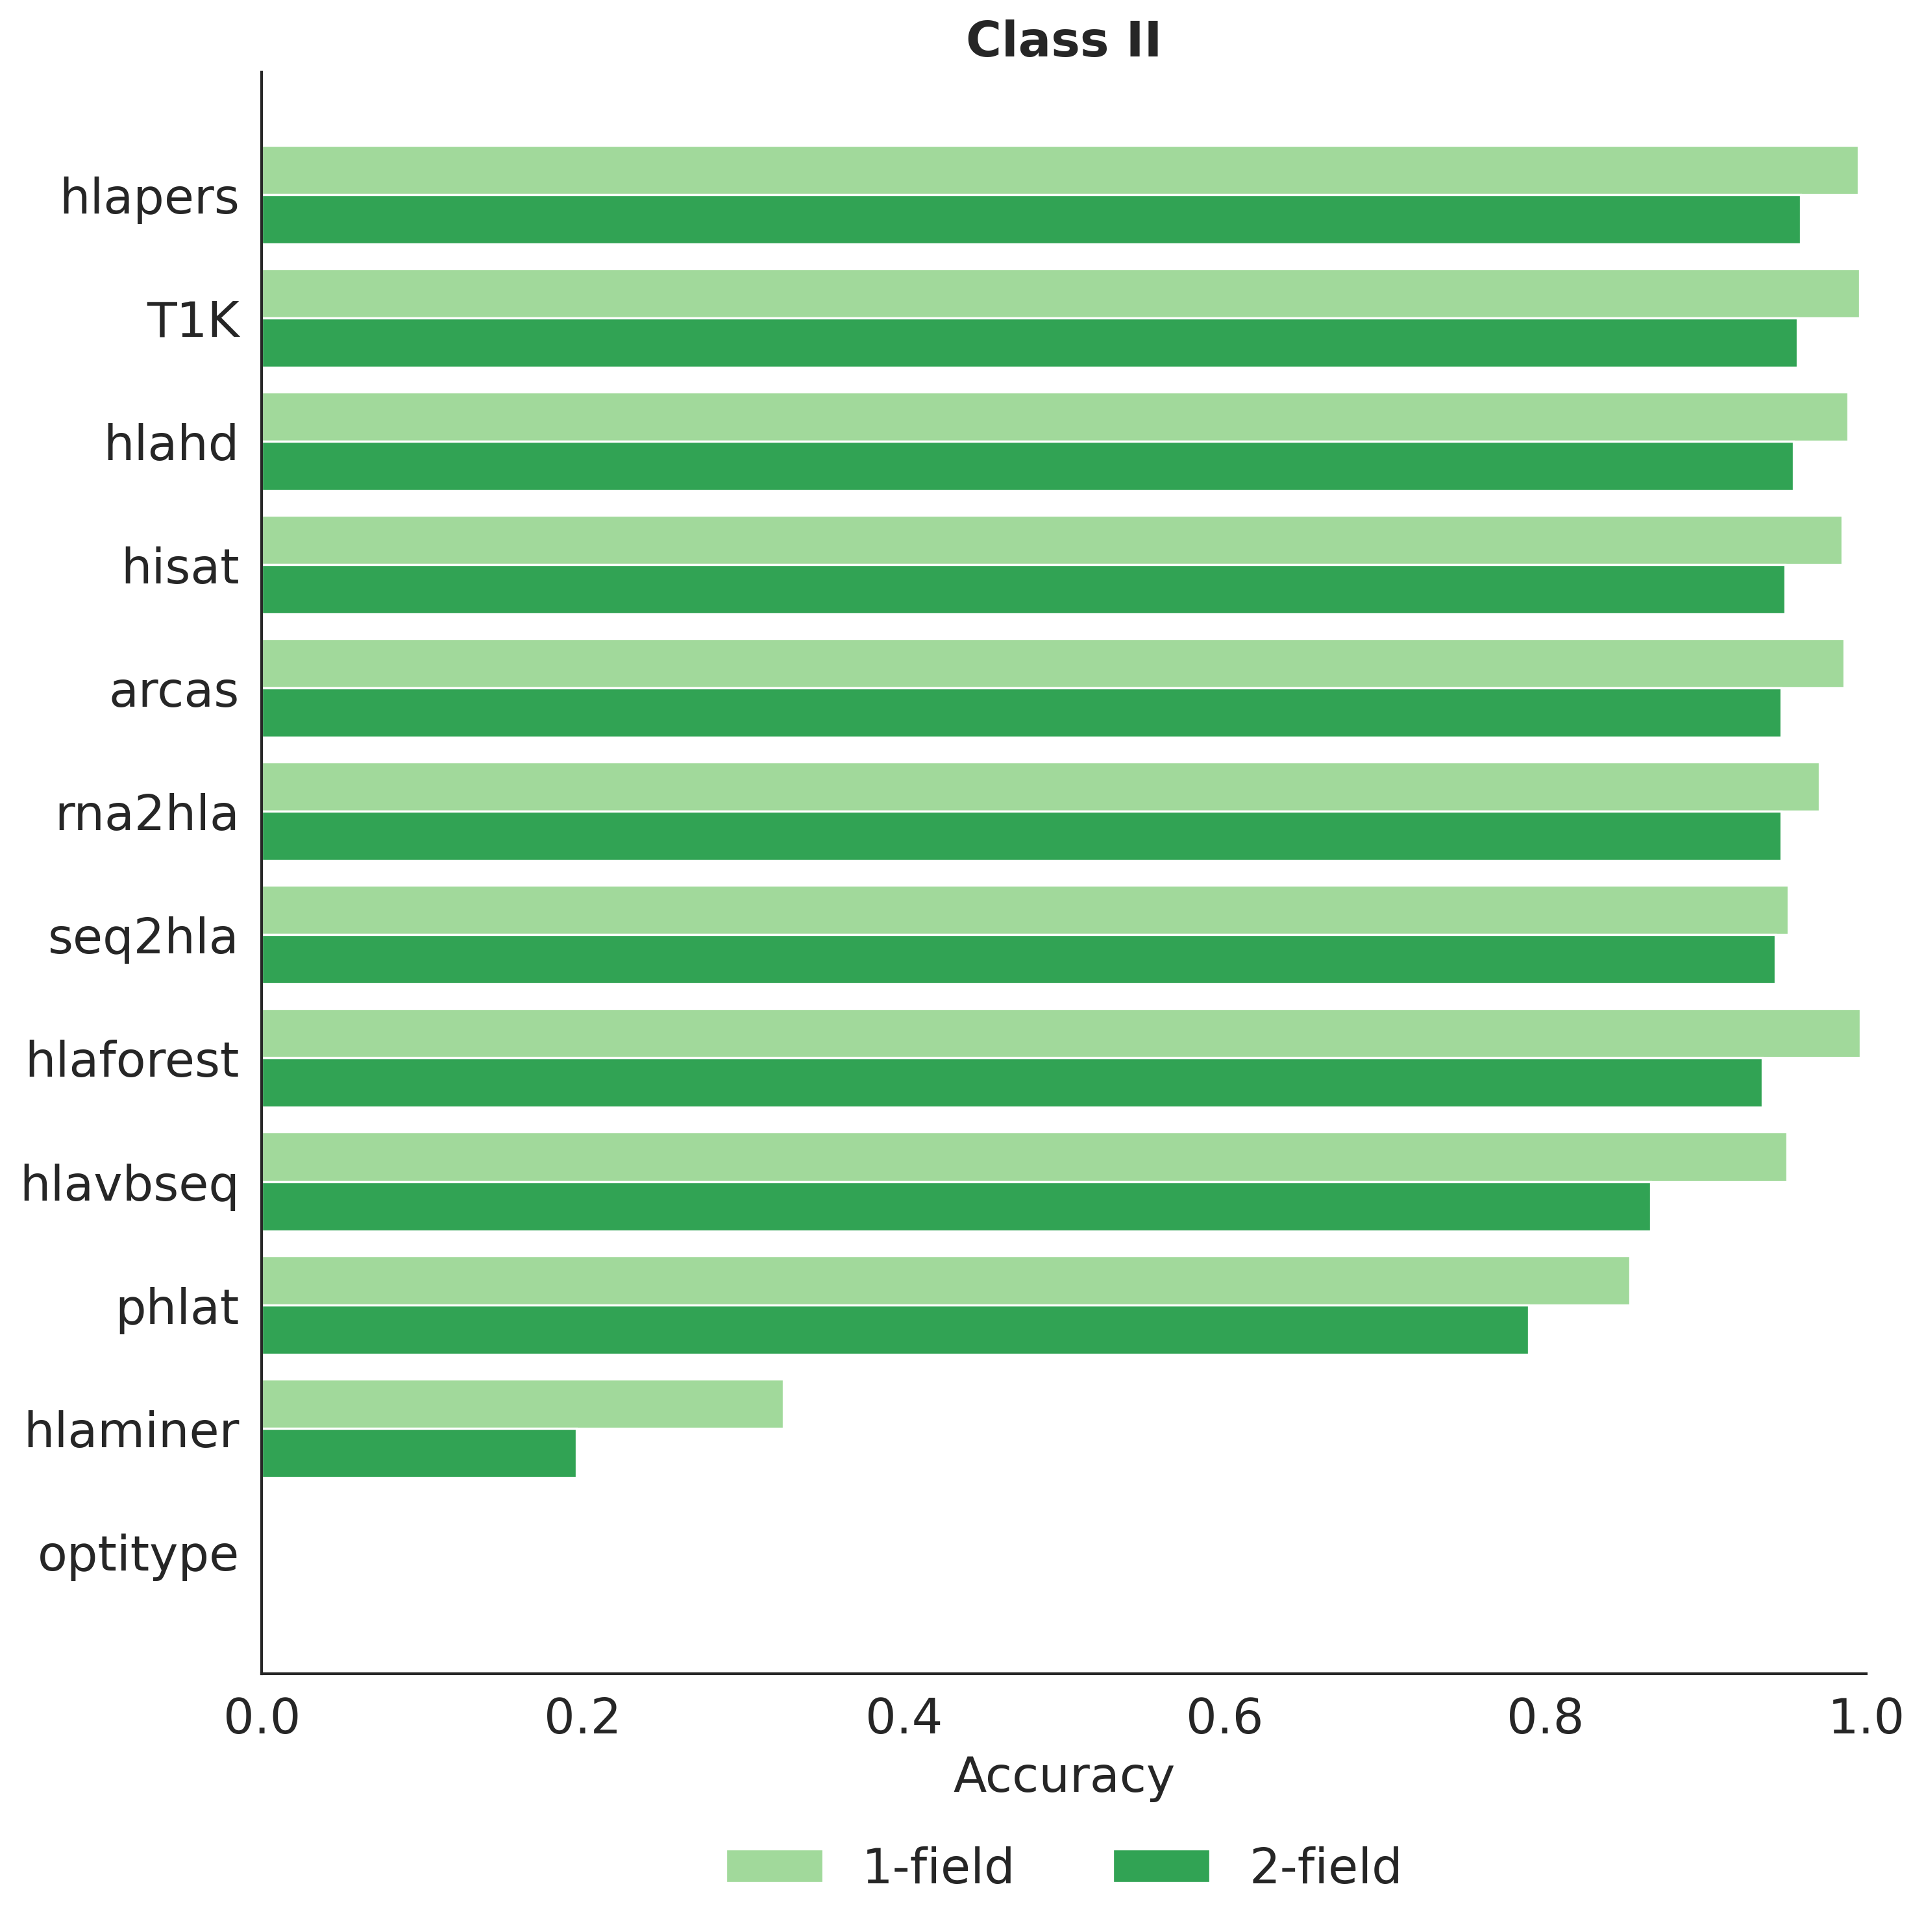

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch

# ─────── Universal plot settings ───────
sns.set_theme(
    context="paper",
    style="white",
    font="sans-serif",
    font_scale=1.1
)
plt.rcParams.update({
    "axes.titlesize":       18,
    "axes.labelsize":       16,
    "xtick.labelsize":      18,
    "ytick.labelsize":      18,
    "legend.fontsize":      18,
    "legend.title_fontsize":18,
    "figure.figsize":       (20, 10),
    "lines.linewidth":      2,
})
# ─────────────────────────────────────────

cls = (
    df_plot
    .query("Mode=='filtered'")
    .pivot_table(index="Tool", columns="Field", values=["ClassI_acc", "ClassII_acc"])
)
tools_order = (
    cls.sort_values(by=[("ClassII_acc", "2-field"), ("ClassI_acc", "2-field")], ascending=[True, True])
    .index.tolist()
)
cls = cls.loc[tools_order]
y = np.arange(len(tools_order))


def fig3b_chart(class_col, title, stem):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.barh(y + 0.2, cls[class_col, "1-field"], 0.4, color=palette["1st field"], label="1-field")
    ax.barh(y - 0.2, cls[class_col, "2-field"], 0.4, color=palette["2nd field"], label="2-field")
    ax.set_yticks(y)
    ax.set_yticklabels(tools_order)
    ax.set_xlim(0, 1)
    ax.set_xlabel("Accuracy", fontsize=18)
    ax.set_title(title, fontsize=18)
    ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=2)
    sns.despine(ax=ax)
    plt.tight_layout()
    fig.savefig(f"../Figures/{stem}.png", dpi=300, bbox_inches="tight")
    fig.savefig(f"../Figures/{stem}.svg", bbox_inches="tight")
    plt.show()


fig3b_chart("ClassI_acc", "Class I", "fig3b_classI")
fig3b_chart("ClassII_acc", "Class II", "fig3b_classII")


## Figure 4: Fraction of Calls

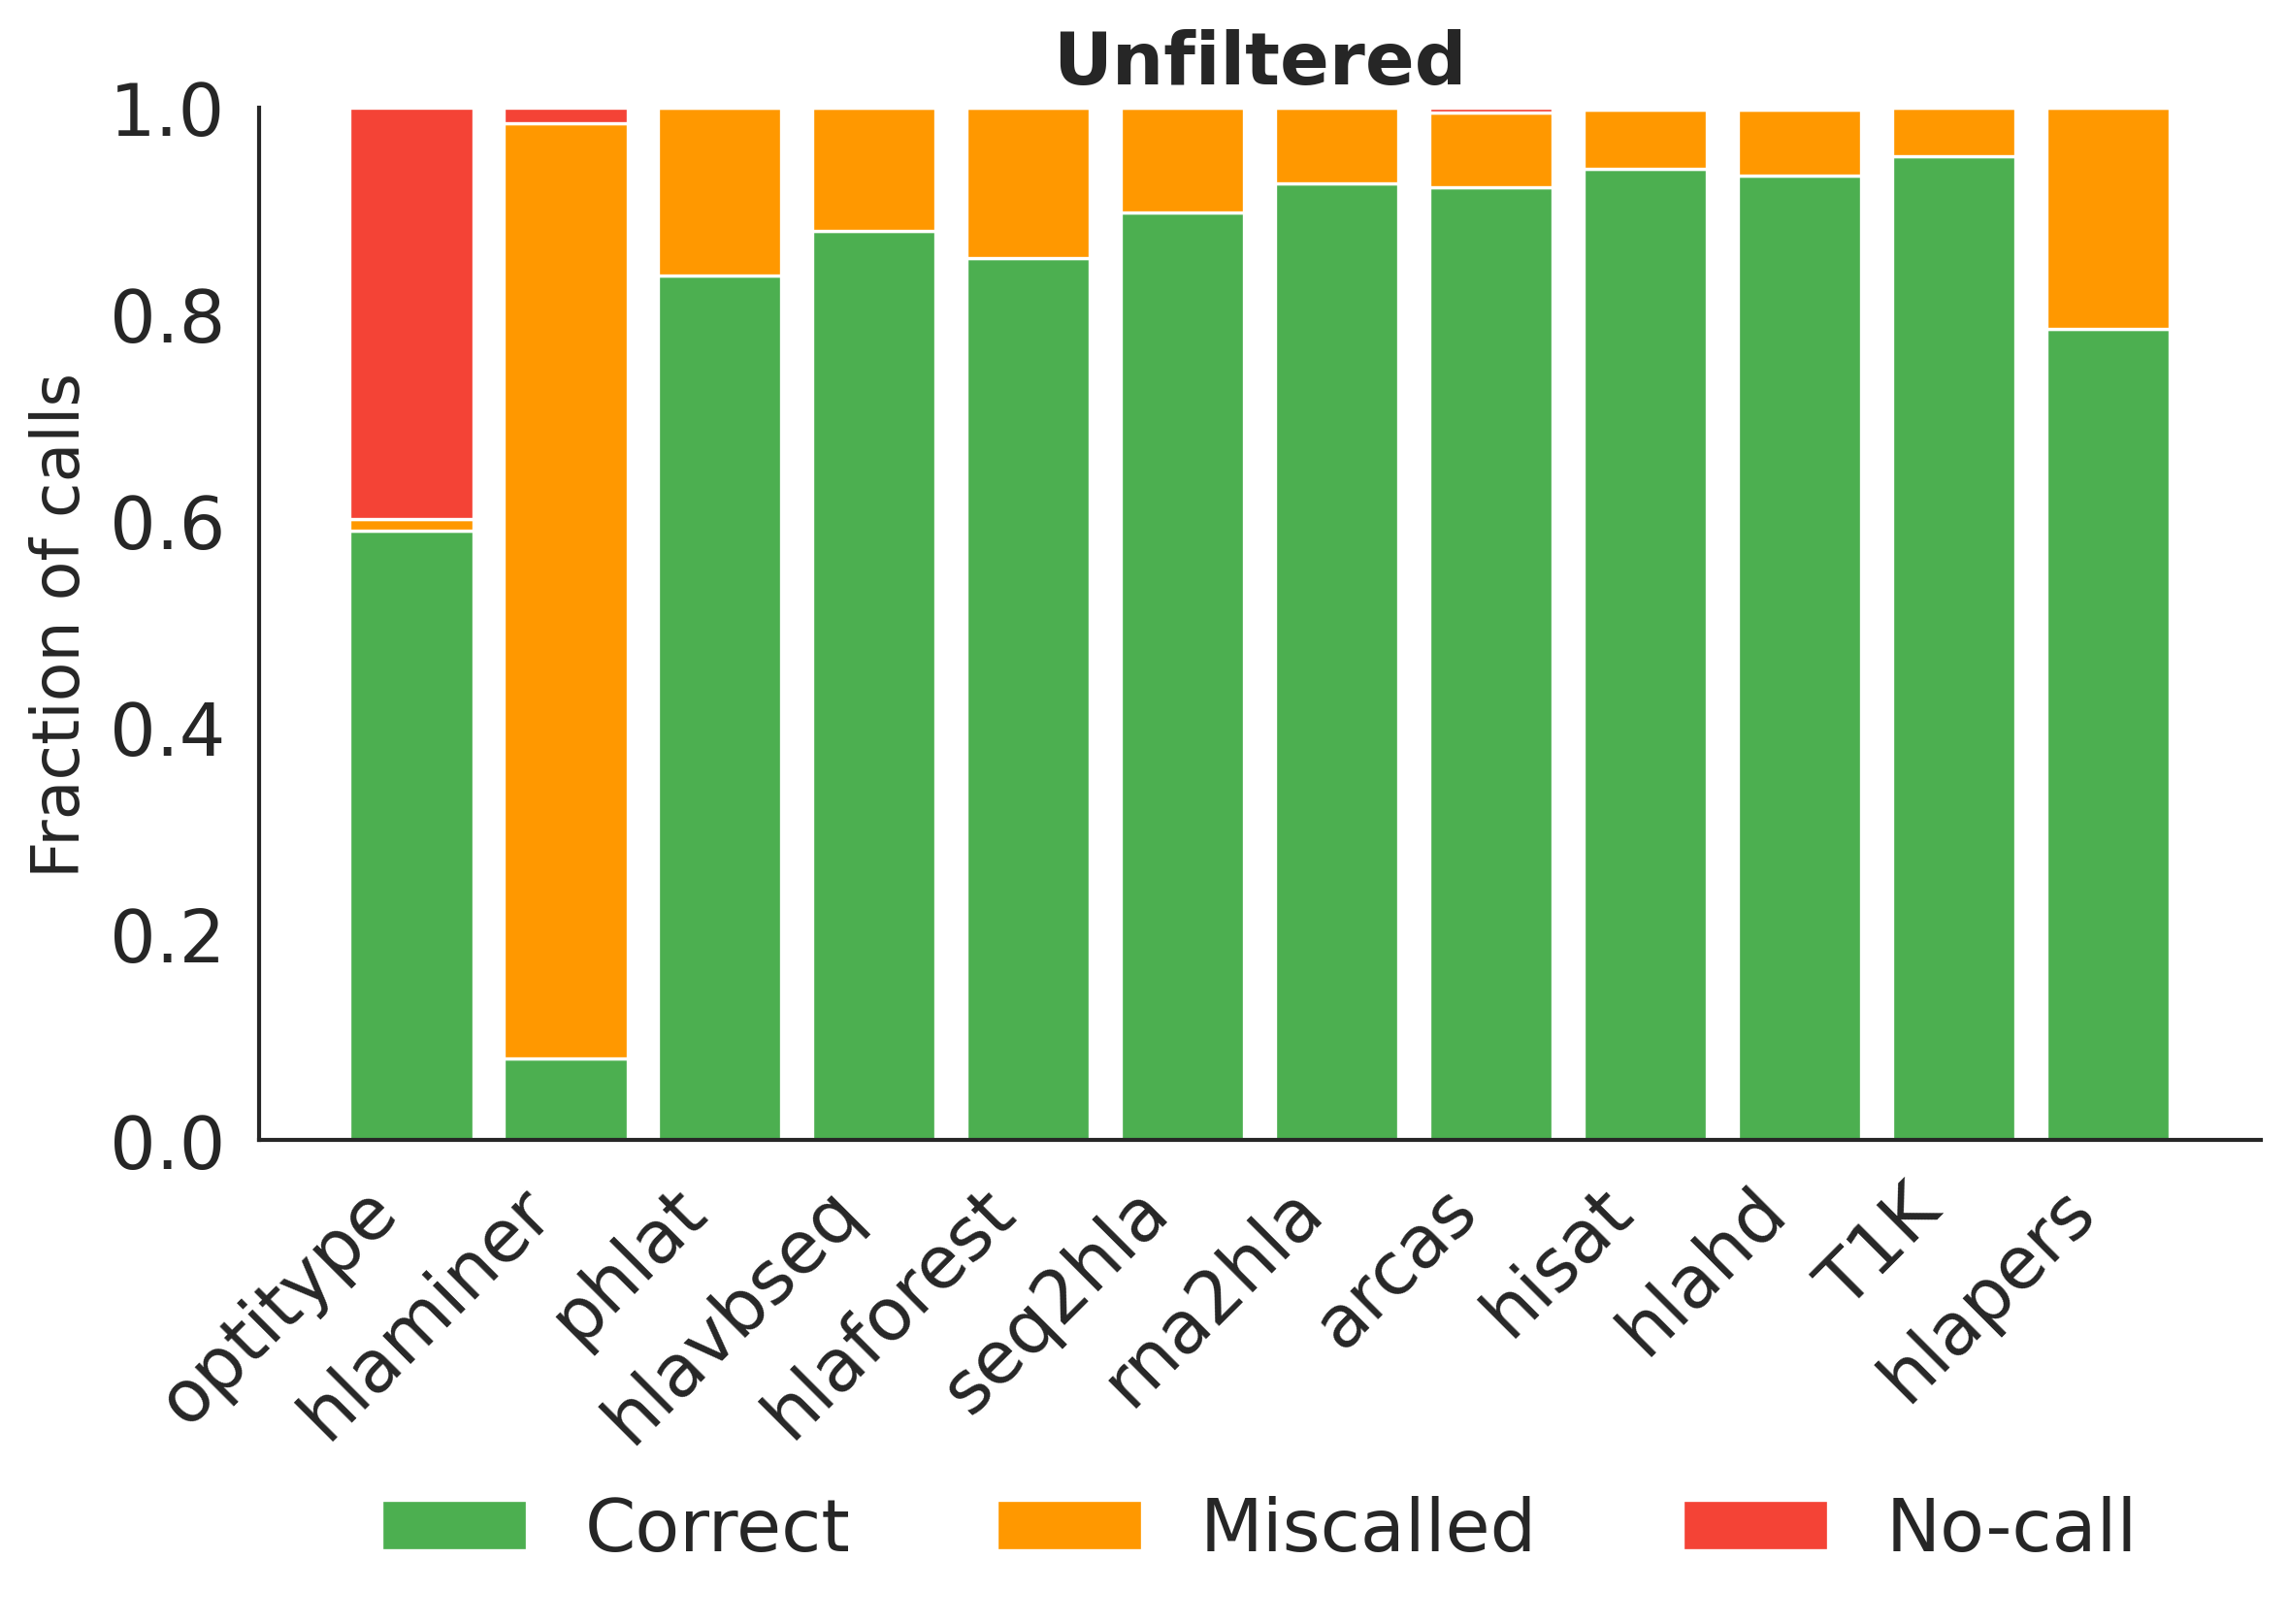

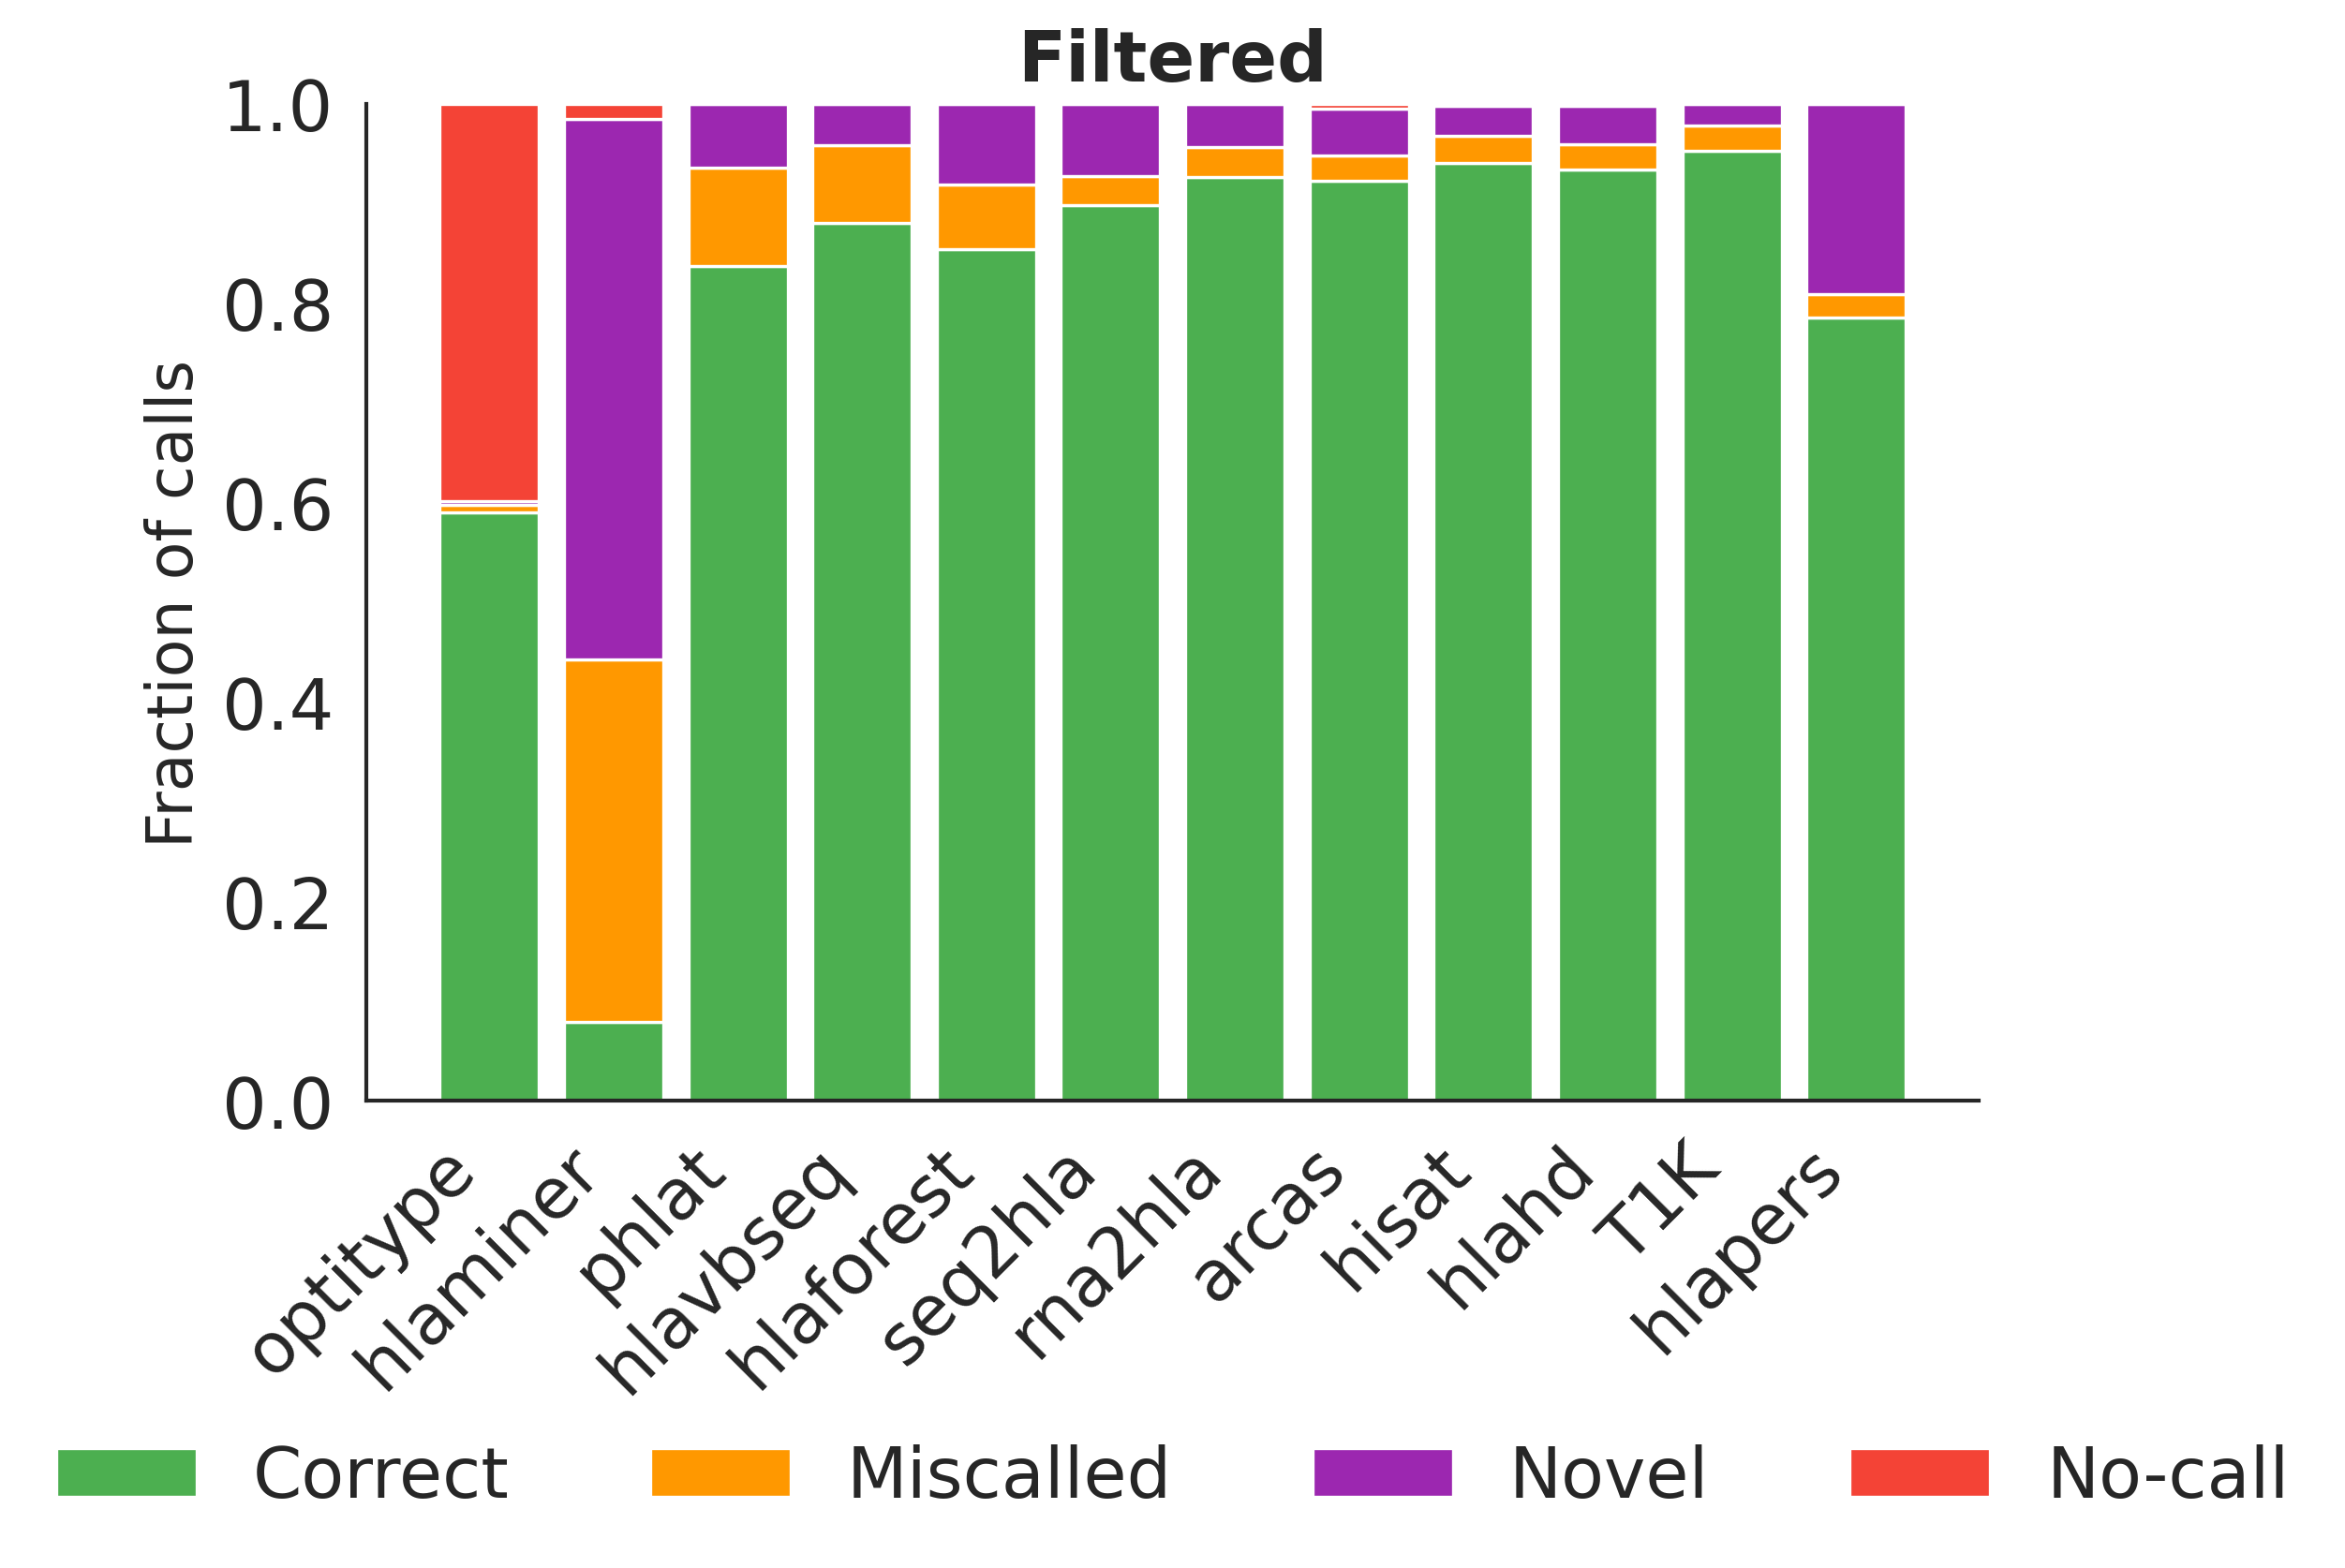

In [14]:
# ─────────────────────────────────────────────────────────────────────────
# 5) FIGURE 3: fraction-of-calls (unfiltered vs filtered)
# ─────────────────────────────────────────────────────────────────────────
# use 2-field aggregated raw counts
fu = df_unf_2.set_index("Tool")
ff = df_flt_2.set_index("Tool")
frac_cols = ["TotalCorrect","TotalMiscalled","TotalNovel","TotalNoCall"]
for df in (fu,ff):
    df["correct_frac"]   = df.TotalCorrect   / df.TotalCalls
    df["miscalled_frac"] = df.TotalMiscalled / df.TotalCalls
    df["novel_frac"]     = df.TotalNovel     / df.TotalCalls
    df["no_call_frac"]   = df.TotalNoCall    / df.TotalCalls

# build plotting frames in tools_order
dfu = fu.loc[tools_order, ["correct_frac","miscalled_frac","no_call_frac"]]
dff = ff.loc[tools_order, ["correct_frac","miscalled_frac","novel_frac","no_call_frac"]]

def fig4_chart(frame, parts, title, stem):
    fig, ax = plt.subplots(figsize=(8, 6))
    bottom = np.zeros(len(tools_order))
    for name, col in parts:
        vals = frame[col].values
        ax.bar(tools_order, vals, bottom=bottom, color=palette[name], label=name)
        bottom += vals
    ax.set_title(title)
    ax.set_ylabel("Fraction of calls")
    ax.set_ylim(0, 1)
    ax.set_xticks(range(len(tools_order)))
    ax.set_xticklabels(tools_order, rotation=45, ha="right")
    sns.despine(ax=ax)
    ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=4)
    plt.tight_layout()
    fig.savefig(f"../Figures/{stem}.png", dpi=300, bbox_inches="tight")
    fig.savefig(f"../Figures/{stem}.svg", bbox_inches="tight")
    plt.show()


fig4_chart(dfu, [("Correct", "correct_frac"), ("Miscalled", "miscalled_frac"), ("No-call", "no_call_frac")],
           "Unfiltered", "fig4a_fraction_calls_unfiltered")
fig4_chart(dff, [("Correct", "correct_frac"), ("Miscalled", "miscalled_frac"),
                 ("Novel", "novel_frac"), ("No-call", "no_call_frac")],
           "Filtered", "fig4b_fraction_calls_filtered")


## Figure 3-4 (manuscript-embedded image): Filtered bulk accuracy + no-call rate

**Added 2026-08-01, at Nick's request** ("Это из манускрипта" / "Делай этот
график тогда") — this two-panel chart ("Filtered bulk accuracy" /
"Filtered bulk + no-call rate") exists in the manuscript as an embedded
image, not generated anywhere in this repo (confirmed by full-text search
across this notebook and its archived predecessors -- zero matches for the
title strings). Likely the source of the "(Fig 3-4)" citation in the
"Performance of HLA Typing Tools" paragraph, which was found to cite stale
pre-fix numbers (see `BACKLOG.md` items E4/E6/E7). Rebuilt here on current
(post-HLApers/gold-standard/`:xx`-fix, D1-D6) data using the same
canonical scoring functions as cell 7 (`aggregate_counts_per_tool_locus`/
`compute_all_metrics`), copied verbatim rather than reimplemented, so this
reproduces `results_summary.md` Table 1 (1-field Overall), Table 3
(2-field filtered Overall) and Table 6/7 (No-call %) exactly -- verified
below before saving. The original chart's tool set omitted `rna2hla`; kept
here for completeness (12/12 tools) since nothing else in this notebook
drops it.

In [ ]:
#!/usr/bin/env python3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────────────────
# 1) CANONICAL SCORING HELPERS (verbatim from cell 7 -- same scoring contract
#    that feeds results_summary.md Tables 1/3/6-7, so this figure agrees with
#    those tables by construction, not by coincidence)
# ─────────────────────────────────────────────────────────────────────────────
def reformat_allele(allele: str, resolution: int = 2):
    a = allele.strip()
    if "*" not in a:
        return a
    gene, rest = a.split("*", 1)
    parts = rest.split(":")
    if resolution == 1:
        return f"{gene}*{parts[0]}"
    else:
        if len(parts) < 2:
            return f"{gene}*{parts[0]}"
        if parts[1].lower() == "xx":
            return None
        return f"{gene}*{parts[0]}:{parts[1]}"

def get_dynamic_loci(gs_df: pd.DataFrame) -> list:
    return sorted({c.split(".")[0] for c in gs_df.columns[1:]})

def build_global_valid(gs_df: pd.DataFrame, resolution: int = 2) -> dict:
    loci = get_dynamic_loci(gs_df)
    valid = {L: set() for L in loci}
    for _, row in gs_df.iterrows():
        for L in loci:
            for suf in ("", ".1"):
                col = f"{L}{suf}"
                if col in row and pd.notna(row[col]):
                    for a in str(row[col]).split("/"):
                        fa = reformat_allele(a, resolution)
                        if fa is not None:
                            valid[L].add(fa)
    return valid

def score_pair(gs_raw, pr_raw, valid_global, resolution=2):
    gs_set = {reformat_allele(a, resolution) for a in gs_raw}
    gs_set.discard(None)
    if not gs_set:
        return None
    if len(pr_raw) == 0:
        pair = [None, None]
    elif len(pr_raw) == 1:
        pair = [pr_raw[0], pr_raw[0]]
    else:
        pair = pr_raw[:2]
    correct = miscalled = novel = no_call = 0
    for allele in pair:
        if allele is None:
            no_call += 1
        else:
            fmt = reformat_allele(allele, resolution)
            if fmt not in valid_global:
                novel += 1
            elif fmt in gs_set:
                correct += 1
            else:
                miscalled += 1
    return correct, miscalled, novel, no_call

def get_pr_loci(pr_df: pd.DataFrame) -> set:
    s = set()
    for L in ["A", "B", "C", "DRB1", "DQB1"]:
        if f"{L}_pre" in pr_df.columns or f"{L}.1_pre" in pr_df.columns:
            s.add(L)
    return s

def aggregate_counts_per_tool_locus(tools, ds_nums, gs_dir, pr_dir, resolution=2, filter_option=False):
    classical = ["A", "B", "C", "DRB1", "DQB1"]
    counts = {t: {L: {"correct": 0, "miscalled": 0, "novel": 0, "no_call": 0, "total_calls": 0}
                  for L in classical} for t in tools}
    for t in tools:
        for ds in ds_nums:
            try:
                gs_df = pd.read_csv(f"{gs_dir}/{ds}_gs.csv", dtype=str)
                pr_df = pd.read_csv(f"{pr_dir}/{t}_d{ds}.csv", dtype=str)
            except FileNotFoundError:
                continue
            gs_df.iloc[:, 0] = gs_df.iloc[:, 0].str.strip()
            pr_df.iloc[:, 0] = pr_df.iloc[:, 0].str.strip()
            rename = {c: f"{c}_pre" for c in pr_df.columns if c != pr_df.columns[0]}
            pr_df = pr_df.rename(columns=rename)
            supported = get_pr_loci(pr_df)
            all_loci = get_dynamic_loci(gs_df)
            valid = build_global_valid(gs_df, resolution)
            merged = pd.merge(gs_df, pr_df, left_on=gs_df.columns[0], right_on=pr_df.columns[0], how="inner")
            for _, row in merged.iterrows():
                for L in classical:
                    if L in all_loci and L not in supported:
                        counts[t][L]["total_calls"] += 2
                        counts[t][L]["no_call"] += 2
                for L in supported:
                    if L not in all_loci:
                        continue
                    gs_raw = []
                    for suf in ("", ".1"):
                        col = f"{L}{suf}"
                        if col in row and pd.notna(row[col]):
                            gs_raw += [x.strip() for x in str(row[col]).split("/")]
                    if not gs_raw:
                        continue
                    pr_raw = []
                    for suf in ("_pre", ".1_pre"):
                        col = f"{L}{suf}"
                        if col in row and pd.notna(row[col]):
                            pr_raw += [x.strip() for x in str(row[col]).split("/")]
                    result = score_pair(gs_raw, pr_raw, valid[L], resolution)
                    if result is None:
                        continue
                    counts[t][L]["total_calls"] += 2
                    c, m, n, nc = result
                    if filter_option:
                        counts[t][L]["correct"] += c
                        counts[t][L]["miscalled"] += m
                        counts[t][L]["novel"] += n
                        counts[t][L]["no_call"] += nc
                    else:
                        counts[t][L]["correct"] += c
                        counts[t][L]["miscalled"] += (m + n)
                        counts[t][L]["no_call"] += nc
    return counts

def compute_all_metrics(*, tools, dataset_nums, gs_dir, pr_dir, resolution=2, filter_option=False, with_raw_counts=False):
    classI = ["A", "B", "C"]
    classII = ["DRB1", "DQB1"]
    by_tool = aggregate_counts_per_tool_locus(tools, dataset_nums, gs_dir, pr_dir, resolution, filter_option)
    rows = []
    for t, lc in by_tool.items():
        ci = sum(lc[L]["correct"] for L in classI)
        novI = sum(lc[L]["novel"] for L in classI)
        callsI = sum(lc[L]["total_calls"] for L in classI)
        cii = sum(lc[L]["correct"] for L in classII)
        novII = sum(lc[L]["novel"] for L in classII)
        callsII = sum(lc[L]["total_calls"] for L in classII)
        ncI = sum(lc[L]["no_call"] for L in classI)
        ncII = sum(lc[L]["no_call"] for L in classII)
        correct_all = ci + cii
        calls_all = callsI + callsII
        denom_all = (calls_all - novI - novII) if filter_option else calls_all
        base = {"Tool": t, "Overall_acc": None if denom_all == 0 else correct_all / denom_all}
        if with_raw_counts:
            base.update({"TotalNoCall": ncI + ncII, "TotalCalls": calls_all})
        rows.append(base)
    return pd.DataFrame(rows)

# ─────────────────────────────────────────────────────────────────────────────
# 2) COMPUTE (D1-D6, filtered -- matches results_summary.md Tables 1/3/6-7)
# ─────────────────────────────────────────────────────────────────────────────
tools_fig34 = ["arcas", "optitype", "seq2hla", "hlaminer", "phlat", "hlavbseq",
               "hlahd", "hisat", "hlaforest", "hlapers", "T1K", "rna2hla"]
datasets_fig34 = list(range(1, 7))

m1 = compute_all_metrics(tools=tools_fig34, dataset_nums=datasets_fig34,
                          gs_dir="../datasets", pr_dir="../results/standard",
                          resolution=1, filter_option=True).set_index("Tool")
m2 = compute_all_metrics(tools=tools_fig34, dataset_nums=datasets_fig34,
                          gs_dir="../datasets", pr_dir="../results/standard",
                          resolution=2, filter_option=True, with_raw_counts=True).set_index("Tool")
m2["NoCallRate"] = m2["TotalNoCall"] / m2["TotalCalls"]

# sanity check against the already-published results_summary.md tables
_expect_1field = {"T1K":0.995,"arcas":0.991,"hisat":0.990,"hlahd":0.987,"rna2hla":0.982,
                   "seq2hla":0.974,"hlaforest":0.989,"phlat":0.929,"hlavbseq":0.970,
                   "hlapers":0.902,"optitype":0.598,"hlaminer":0.253}
_expect_2field = {"T1K":0.974,"arcas":0.969,"hisat":0.970,"hlahd":0.971,"rna2hla":0.968,
                   "seq2hla":0.968,"hlaforest":0.929,"phlat":0.894,"hlavbseq":0.918,
                   "hlapers":0.971,"optitype":0.593,"hlaminer":0.173}
max_dev_1 = max(abs(m1.loc[t, "Overall_acc"] - v) for t, v in _expect_1field.items())
max_dev_2 = max(abs(m2.loc[t, "Overall_acc"] - v) for t, v in _expect_2field.items())
print(f"Sanity check vs results_summary.md Table 1 (1-field): max deviation = {max_dev_1*100:.2f}pp")
print(f"Sanity check vs results_summary.md Table 3 (2-field, filtered): max deviation = {max_dev_2*100:.2f}pp")
assert max_dev_1 < 0.005 and max_dev_2 < 0.005, "computed values diverge from the published tables -- investigate before trusting this figure"

# ─────────────────────────────────────────────────────────────────────────────
# 3) PLOT -- two panels, matching the manuscript-embedded image's layout
# ─────────────────────────────────────────────────────────────────────────────
order = m2["Overall_acc"].sort_values().index.tolist()
x = np.arange(len(order))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, show_nocall, title in zip(axes, [False, True],
                                   ["Filtered bulk accuracy", "Filtered bulk + no-call rate"]):
    ax.bar(x - w/2, [m1.loc[t, "Overall_acc"] for t in order], width=w,
           color="#8FD19E", label="1-field", edgecolor="black", linewidth=0.5)
    ax.bar(x + w/2, [m2.loc[t, "Overall_acc"] for t in order], width=w,
           color="#2E8B57", label="2-field", edgecolor="black", linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(order, rotation=45, ha="right")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1.05)
    ax.set_title(title, fontweight="bold")
    ax.legend(loc="upper left")
    if show_nocall:
        ax2 = ax.twinx()
        nocall = [m2.loc[t, "NoCallRate"] for t in order]
        ax2.plot(x, nocall, color="red", linestyle="--", marker="o", markersize=4,
                 label="No-call rate")
        ax2.set_ylabel("No-call rate", color="red")
        ax2.tick_params(axis="y", colors="red")
        ax2.set_ylim(0, max(0.5, max(nocall) * 1.15))
        ax2.legend(loc="upper right")

plt.tight_layout()
plt.gcf().savefig("../Figures/fig3_4_filtered_bulk_accuracy_nocall.png", dpi=300, bbox_inches="tight")
plt.gcf().savefig("../Figures/fig3_4_filtered_bulk_accuracy_nocall.svg", bbox_inches="tight")
plt.show()


# Figure 14: No-Call Rates and Novel Alleles Analysis

In addition to accuracy, two other important metrics affect clinical utility:

1. **No-call rate**: Proportion of alleles the tool couldn't predict
2. **Novel allele rate**: Proportion of predictions not in the gold standard cohort

High no-call rates reduce utility. Novel alleles are ambiguous - they could be real rare alleles or errors. This section explores these metrics across five complementary visualizations.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 14: Data Preparation
# ─────────────────────────────────────────────────────────────────────────────

# Define Class I-only tools (should not be penalized for Class II no-calls)
CLASS_I_ONLY_TOOLS = ['optitype']

# Get per-locus data for proper no-call calculation
by_tool = aggregate_counts_per_tool_locus(
    tools=tools, 
    ds_nums=ds_nums, 
    gs_dir=gs_dir, 
    pr_dir=pr_dir,
    resolution=2, 
    filter_option=False
)

# Prepare adjusted no-call summary (excluding Class II for Class I-only tools)
loci = ["A", "B", "C", "DRB1", "DQB1"]
class_I_loci = ["A", "B", "C"]
class_II_loci = ["DRB1", "DQB1"]

no_call_data = []
for tool in tools:
    total_no_calls = 0
    total_calls = 0
    
    for locus in loci:
        # Skip Class II loci for Class I-only tools
        if tool in CLASS_I_ONLY_TOOLS and locus in class_II_loci:
            continue
            
        total_calls += by_tool[tool][locus]['total_calls']
        total_no_calls += by_tool[tool][locus]['no_call']
    
    no_call_data.append({
        'Tool': tool,
        'TotalNoCall': total_no_calls,
        'TotalCalls': total_calls,
        'NoCallRate': (total_no_calls / total_calls * 100) if total_calls > 0 else 0
    })

no_call_summary = pd.DataFrame(no_call_data)
no_call_summary = no_call_summary.sort_values('NoCallRate', ascending=True)

# Prepare heatmap data (all tools, all loci - shows design by default)
heatmap_data = []
for tool in tools:
    row = {'Tool': tool}
    for locus in loci:
        total = by_tool[tool][locus]['total_calls']
        no_call = by_tool[tool][locus]['no_call']
        row[locus] = (no_call / total * 100) if total > 0 else 0
    heatmap_data.append(row)
    
heatmap_df = pd.DataFrame(heatmap_data)
heatmap_df = heatmap_df.set_index('Tool')
# Order by overall no-call rate (adjusted)
heatmap_df = heatmap_df.loc[no_call_summary['Tool']]

# Prepare novel allele summary (unchanged)
novel_summary = df_flt_2[['Tool', 'TotalNovel', 'TotalCalls']].copy()
novel_summary['NovelRate'] = (novel_summary['TotalNovel'] / novel_summary['TotalCalls']) * 100
novel_summary = novel_summary.sort_values('NovelRate', ascending=True)

# Prepare accuracy comparison (unchanged)
comparison = pd.merge(
    df_unf_2[['Tool', 'Overall_acc']].rename(columns={'Overall_acc': 'Unfiltered_Acc'}),
    df_flt_2[['Tool', 'Overall_acc']].rename(columns={'Overall_acc': 'Filtered_Acc'}),
    on='Tool'
)
comparison['Impact'] = (comparison['Filtered_Acc'] - comparison['Unfiltered_Acc']) * 100
comparison = comparison.sort_values('Impact', ascending=False)

# Prepare trade-off data (unchanged)
tradeoff = pd.merge(
    df_flt_2[['Tool', 'Overall_acc']],
    novel_summary[['Tool', 'NovelRate']],
    on='Tool'
)

print("Data preparation complete for Figure 14")
print(f"No-call rates range: {no_call_summary['NoCallRate'].min():.1f}% - {no_call_summary['NoCallRate'].max():.1f}%")
print(f"Novel rates range: {novel_summary['NovelRate'].min():.1f}% - {novel_summary['NovelRate'].max():.1f}%")
print(f"\nNote: Class I-only tools ({', '.join(CLASS_I_ONLY_TOOLS)}) exclude Class II no-calls from overall rate")


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 14a: No-Call Rate by Tool
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
y_pos = np.arange(len(no_call_summary))
ax.barh(y_pos, no_call_summary['NoCallRate'], color=palette['No-call'], alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(no_call_summary['Tool'])
ax.set_xlabel('No-Call Rate (%)', fontsize=14)
ax.set_title('No-Call Rate by Tool', fontsize=16, fontweight='bold')
ax.set_xlim(0, 100)
for i, v in enumerate(no_call_summary['NoCallRate']):
    ax.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=10)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("../Figures/fig14a_nocall_rate_by_tool.png", dpi=300, bbox_inches="tight")
plt.savefig("../Figures/fig14a_nocall_rate_by_tool.svg", bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Figure 14b: No-Call Rate Heatmap by Tool and Locus
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(heatmap_df, annot=True, fmt='.1f', cmap='Reds',
            cbar_kws={'label': 'No-Call Rate (%)'},
            vmin=0, vmax=100, ax=ax, linewidths=0.5)
ax.set_xlabel('Locus', fontsize=14)
ax.set_ylabel('Tool', fontsize=14)
ax.set_title('No-Call Rate Heatmap by Tool and Locus', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("../Figures/fig14b_nocall_heatmap.png", dpi=300, bbox_inches="tight")
plt.savefig("../Figures/fig14b_nocall_heatmap.svg", bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Figure 14c: Novel Allele Rate by Tool
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
y_pos = np.arange(len(novel_summary))
ax.barh(y_pos, novel_summary['NovelRate'], color=palette['Novel'], alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(novel_summary['Tool'])
ax.set_xlabel('Novel Allele Rate (%)', fontsize=14)
ax.set_title('Novel Allele Rate by Tool', fontsize=16, fontweight='bold')
ax.set_xlim(0, max(novel_summary['NovelRate']) * 1.15)
for i, v in enumerate(novel_summary['NovelRate']):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("../Figures/fig14c_novel_rate_by_tool.png", dpi=300, bbox_inches="tight")
plt.savefig("../Figures/fig14c_novel_rate_by_tool.svg", bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Figure 14d: Impact of Novel Alleles on Accuracy
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(comparison))
width = 0.35
ax.bar(x_pos - width/2, comparison['Unfiltered_Acc'] * 100, width,
       label='Unfiltered (novel = error)', color=palette['Miscalled'], alpha=0.8)
ax.bar(x_pos + width/2, comparison['Filtered_Acc'] * 100, width,
       label='Filtered (novel ignored)', color=palette['Correct'], alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(comparison['Tool'], rotation=45, ha='right')
ax.set_ylabel('Accuracy (%)', fontsize=14)
ax.set_title('Impact of Novel Alleles on Accuracy', fontsize=16, fontweight='bold')
ax.set_ylim(0, 100)
ax.legend(loc='lower right', fontsize=12)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("../Figures/fig14d_novel_impact_accuracy.png", dpi=300, bbox_inches="tight")
plt.savefig("../Figures/fig14d_novel_impact_accuracy.svg", bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Figure 14e: Accuracy vs Novel Allele Trade-off
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
for _, row in tradeoff.iterrows():
    tool = row['Tool']
    color = palette.get(tool, '#888888')
    ax.scatter(row['NovelRate'], row['Overall_acc'] * 100,
               s=150, color=color, alpha=0.7, edgecolors='black', linewidth=1.5)
    ax.annotate(tool, (row['NovelRate'], row['Overall_acc'] * 100),
                xytext=(5, 5), textcoords='offset points', fontsize=10)
ax.set_xlabel('Novel Allele Rate (%)', fontsize=14)
ax.set_ylabel('Filtered Accuracy (%)', fontsize=14)
ax.set_title('Accuracy vs Novel Allele Trade-off', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(-2, max(tradeoff['NovelRate']) * 1.1)
ax.set_ylim(0, 100)
mid_x = ax.get_xlim()[1] / 2
ax.text(mid_x * 0.3, 85, 'Conservative\n& Accurate', ha='center', fontsize=11,
        style='italic', color='gray', alpha=0.7)
ax.text(mid_x * 1.7, 85, 'Aggressive\n& Accurate', ha='center', fontsize=11,
        style='italic', color='gray', alpha=0.7)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("../Figures/fig14e_accuracy_novel_tradeoff.png", dpi=300, bbox_inches="tight")
plt.savefig("../Figures/fig14e_accuracy_novel_tradeoff.svg", bbox_inches="tight")
plt.show()

## Figure 14 Interpretation

**Important Note**: Class I-only tools (Optitype) are evaluated only on Class I loci (A, B, C) in panels 14a. It would be unfair to penalize such tools for not calling Class II loci (DRB1, DQB1), which they are not designed to support. Panel 14b (heatmap) shows all loci to reveal each tool's intended coverage. (HLA-VBSeq is *not* Class I-only: it calls DRB1/DQB1 with near-zero no-calls and 80.8%/93.4% filtered 2-field accuracy, so it is scored on Class II like the other multi-class tools.)

### Panel A & B: No-Call Rates

The bar plot (14a) and heatmap (14b) reveal systematic patterns in no-call rates:

- **Class I-only tools** (Optitype): Evaluated only on A, B, C loci. The heatmap shows 100% no-call for DRB1/DQB1 by design, which is expected and appropriate.
- **HLApers** shows high no-call rates for Class II loci, suggesting limited DRB1/DQB1 support
- **Best overall coverage**: arcasHLA, HLA-HD, and Hisat-Genotype show low no-call rates across all five classical HLA loci
- **Within-locus gaps**: Some tools struggle with specific loci even when they claim support

After excluding design-based gaps, the adjusted no-call rates reflect true prediction failures rather than scope limitations.

### Panel C: Novel Allele Rates

Tools vary dramatically in their propensity to call novel alleles (alleles not in the gold standard cohort):

- **Conservative tools** (low novel rate): Optitype, HLA-HD - stick to well-characterized alleles
- **Aggressive tools** (high novel rate): HLAMiner, HLApers, T1K - more willing to call rare alleles

Novel allele calls are ambiguous: they could represent:
- True rare alleles present in the sample but absent from the gold standard cohort
- Population-specific alleles (our cohort may not represent all populations)
- Algorithmic errors or reference database differences

### Panel D: Impact on Accuracy

The gap between filtered and unfiltered accuracy shows the penalty for novel allele calls:

- **Large gaps** (e.g., HLAMiner, HLApers): Heavily penalized for calling novel alleles
- **Small gaps** (e.g., Optitype, HLA-HD): Conservative calling minimizes penalty
- **Interpretation**: If the gap is large, the tool either:
  - Calls many novel alleles (most are errors)
  - Has different reference allele nomenclature
  - Uses outdated or different HLA databases

### Panel E: Trade-off Analysis

The scatter plot explores whether there's a trade-off between accuracy and novel calling:

- **Top-left quadrant** (Conservative & Accurate): Best for clinical use - high accuracy, few ambiguous calls. Tools here are reliable and use well-established allele calls.
- **Top-right quadrant** (Aggressive & Accurate): Potentially useful for discovering rare alleles in research settings, though clinical interpretation requires validation.
- **Bottom-left quadrant** (Conservative & Inaccurate): Poor performance despite conservative approach - fundamental accuracy issues.
- **Bottom-right quadrant** (Aggressive & Inaccurate): High error rate compounded by novel calls - avoid for clinical use.

**Key Finding**: The most accurate tools (Optitype, HLA-HD, Hisat-Genotype, arcasHLA) cluster in the top-left quadrant, suggesting conservative calling strategies improve reliability. This makes sense: established alleles have been thoroughly validated, while novel predictions require additional confirmation.

**Clinical Recommendation**: For transplant matching and disease association studies, prioritize tools in the top-left quadrant. For allele discovery or population genetics research, tools in the top-right quadrant may provide additional insights but require careful validation.

# Figure 5: accuracy per locus per dataset

**Fix applied 2026-09-22 (Human-PI-authorized: Nick, "Исправляй").** This section's
`reformat_allele`/`build_global_valid`/`score_pair` did not carry the `":xx"` gold-standard-suffix
fix that was applied to the canonical scorer on 2026-07-25 (see the "New Accuracy Script" section
above and `.claude/memory/KNOWN_BUGS.md`). A gold-standard second field that is literally `"xx"`
(HLA nomenclature for "field 2 unresolved", currently only `A*68:xx`/`B*55:xx` in D3) now returns
`None` from `reformat_allele` and is dropped from `gs_set`/the valid-allele set instead of being
scored as an unwinnable miss for every tool. This is the same contract as the canonical scorer --
copied here, not imported, because this notebook keeps each figure's code self-contained.

This affects `df_locus_stats`, and therefore every figure built from it below: **Fig 5** (this
cell), **Fig 6a**, **Fig 6b** (both proportion and absolute versions).


In [ ]:
#!/usr/bin/env python3
import pandas as pd

# ─────────────────────────────────────────────────────────────────────────────
# 1) COPY OVER BULK-SCORING HELPERS
# ─────────────────────────────────────────────────────────────────────────────
def reformat_allele(allele: str, resolution: int = 2) -> str:
    a = allele.strip()
    if "*" not in a:
        return a
    gene, rest = a.split("*", 1)
    parts = rest.split(":")
    if resolution == 1:
        return f"{gene}*{parts[0]}"
    if len(parts) < 2:
        return f"{gene}*{parts[0]}"
    if parts[1].lower() == "xx":
        return None
    return f"{gene}*{parts[0]}:{parts[1]}"

def get_dynamic_loci(gs_df: pd.DataFrame) -> list:
    return sorted({c.split(".")[0] for c in gs_df.columns[1:]})

def build_global_valid(gs_df: pd.DataFrame, resolution: int=2) -> dict:
    loci = get_dynamic_loci(gs_df)
    valid = {L:set() for L in loci}
    for _, row in gs_df.iterrows():
        for L in loci:
            for suf in ("", ".1"):
                col = f"{L}{suf}"
                if col in row and pd.notna(row[col]):
                    for a in str(row[col]).split("/"):
                        fa = reformat_allele(a, resolution)
                        if fa is not None:
                            valid[L].add(fa)
    return valid

def get_pr_loci(pr_df: pd.DataFrame) -> set:
    s = set()
    for L in get_dynamic_loci(pr_df.rename(columns=lambda c: c.rstrip("_pre"))):
        # look for X_pre or X.1_pre
        if f"{L}_pre" in pr_df.columns or f"{L}.1_pre" in pr_df.columns:
            s.add(L)
    return s

def score_pair(gs_raw, pr_raw, valid_global, resolution=2):
    gs_set = {reformat_allele(a, resolution) for a in gs_raw}
    gs_set.discard(None)
    if not gs_set:
        return None
    if   len(pr_raw) == 0:
        pair = [None, None]
    elif len(pr_raw) == 1:
        pair = [pr_raw[0], pr_raw[0]]
    else:
        pair = pr_raw[:2]
    correct = miscalled = novel = no_call = 0
    for allele in pair:
        if allele is None:
            no_call += 1
        else:
            fmt = reformat_allele(allele, resolution)
            if fmt not in valid_global:
                novel += 1
            elif fmt in gs_set:
                correct += 1
            else:
                miscalled += 1
    return correct, miscalled, novel, no_call

# ─────────────────────────────────────────────────────────────────────────────
# 2) PER-LOCUS ACCURACY AGGREGATOR
# ─────────────────────────────────────────────────────────────────────────────
def compute_locus_metrics(tools, dataset_nums,
                          gs_dir="../datasets", pr_dir="../results/standard",
                          resolution=2, filter_option=False) -> pd.DataFrame:
    # initialize counters: tool -> locus -> dict of counts
    agg = {t:{} for t in tools}

    for tool in tools:
        for ds in dataset_nums:
            try:
                gs_df = pd.read_csv(f"{gs_dir}/{ds}_gs.csv", dtype=str)
                pr_df = pd.read_csv(f"{pr_dir}/{tool}_d{ds}.csv", dtype=str)
            except FileNotFoundError:
                continue

            # strip ID columns
            gs_df.iloc[:,0] = gs_df.iloc[:,0].str.strip()
            pr_df.iloc[:,0] = pr_df.iloc[:,0].str.strip()
            # rename pred columns consistently
            rename = {c:f"{c}_pre" for c in pr_df.columns if c != pr_df.columns[0]}
            pr_df = pr_df.rename(columns=rename)

            loci     = get_dynamic_loci(gs_df)
            supported = get_pr_loci(pr_df)
            valid    = build_global_valid(gs_df, resolution)

            # merge on sample ID
            id_gs = gs_df.columns[0]
            id_pr = pr_df.columns[0]
            merged = pd.merge(gs_df, pr_df,
                              left_on=id_gs, right_on=id_pr, how="inner")

            # ensure counters exist for all loci
            for L in loci:
                agg[tool].setdefault(L, {
                    "correct":0, "miscalled":0, "novel":0, "no_call":0, "total_calls":0
                })

            # first, penalize unsupported loci for every sample
            for L in loci:
                if L not in supported:
                    # two no-calls per sample
                    n_samples = merged.shape[0]
                    agg[tool][L]["total_calls"] += 2*n_samples
                    agg[tool][L]["no_call"]      += 2*n_samples

            # now walk through each sample × supported locus
            for _, row in merged.iterrows():
                for L in supported:
                    if L not in loci:
                        continue

                    # GS alleles
                    gs_raw = []
                    for suf in ("", ".1"):
                        col = f"{L}{suf}"
                        if col in row and pd.notna(row[col]):
                            gs_raw += [x.strip() for x in str(row[col]).split("/")]
                    if not gs_raw:
                        # no truth—skip
                        continue

                    # PR alleles
                    pr_raw = []
                    for suf in ("_pre", ".1_pre"):
                        col = f"{L}{suf}"
                        if col in row and pd.notna(row[col]):
                            pr_raw += [x.strip() for x in str(row[col]).split("/")]
                    
                    result = score_pair(gs_raw, pr_raw, valid[L], resolution)
                    if result is None:
                        continue
                    c, m, n, nc = result
                    if not filter_option:
                        m += n
                        n = 0

                    agg[tool][L]["total_calls"] += 2
                    agg[tool][L]["correct"]     += c
                    agg[tool][L]["miscalled"]   += m
                    agg[tool][L]["novel"]       += n
                    agg[tool][L]["no_call"]     += nc

    # build output DataFrame
    rows = []
    for tool, loci_dict in agg.items():
        for locus, cts in loci_dict.items():
            total = cts["total_calls"]
            rows.append({
                "Tool": tool,
                "Locus": locus,
                "CorrectAlleles":   cts["correct"],
                "MiscalledAlleles": cts["miscalled"],
                "NovelAlleles":     cts["novel"],
                "NoCallAlleles":    cts["no_call"],
                "TotalAlleles":     total,
                "Accuracy":         None if total==0 else cts["correct"]/total
            })
    df = pd.DataFrame(rows)
    return df.sort_values(["Tool","Locus"]).reset_index(drop=True)

# ─────────────────────────────────────────────────────────────────────────────
# 3) EXAMPLE USAGE
# ─────────────────────────────────────────────────────────────────────────────
tools    = ["arcas","optitype","seq2hla","hlaminer",
            "phlat","hlavbseq","hlahd","hisat","hlaforest","hlapers","T1K","rna2hla"]
dataset_nums = list(range(1,7))

# per-locus at 2-field, filtered
df_locus_stats = compute_locus_metrics(
    tools, dataset_nums,
    resolution=2, filter_option=True
)
df_locus_stats


##  Figure

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- assume df_locus_all is ready ---
loci_order = ["A","B","C","DRB1","DQB1"]
df_pivot = (
    df_locus_stats
    .pivot(index="Tool", columns="Locus", values="Accuracy")
    .reindex(columns=loci_order)
    .fillna(0.0)
    .sort_values(by="A", ascending=False)
)

mask_zeros = (df_pivot == 0.0)
nonzero = df_pivot[df_pivot > 0]
min_nonzero = nonzero.min().min() if not nonzero.empty else 1e-3

vmin_linear, vmax = 0.0, 1.0
vmin_log = max(min_nonzero, 1e-3)
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(20, 12), sharey=False)

# 1) Linear
sns.heatmap(
    df_pivot,
    ax=ax1,
    cmap="YlGnBu",
    vmin=vmin_linear, vmax=vmax,
    annot=True, fmt=".2f",
    cbar_kws={"label":"Accuracy"},
    yticklabels=df_pivot.index,  # draw the tool names
    xticklabels=True
)
ax1.set_title("Two-field HLA Accuracy\n(Linear Scale)", fontsize=16)
ax1.set_xlabel("Locus", fontsize=18)
ax1.set_ylabel("")  
ax1.tick_params(axis='y', rotation=0, labelsize=18)

# 2) Log scale
sns.heatmap(
    df_pivot,
    ax=ax2,
    cmap="YlGnBu",
    norm=mcolors.LogNorm(vmin=vmin_log, vmax=vmax),
    annot=True, fmt=".2f",
    cbar_kws={"label":"Accuracy (log scale)"},
    mask=mask_zeros,
    yticklabels=False,          # hide labels on right only
    xticklabels=True
)
ax2.set_title("Two-field HLA Accuracy\n(Log Color Scale)", fontsize=16)
ax2.set_xlabel("Locus", fontsize=18)
ax2.set_ylabel("")

plt.tight_layout()
plt.gcf().savefig("../Figures/fig5_locus_heatmap.png", dpi=300, bbox_inches="tight")
plt.gcf().savefig("../Figures/fig5_locus_heatmap.svg", bbox_inches="tight")
plt.show()






# Figure 6 & 7: misclassification rate

## Figure 6: Miscalled Alleles  at each locus for each tool

### counts plot

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Your custom palette dict (include only the locus colors if you prefer)
locus_palette = {
    'A':     palette['A'],
    'B' :     palette['B'],
    'C':     palette['C'],
    'DQB1': palette['DQB1'],
    'DRB1':  palette['DRB1'],
}

# assume df_locus_stats is already computed and has columns:
# Tool | Locus | CorrectAlleles | MiscalledAlleles | NoCallAlleles | TotalAlleles | Accuracy

# 1) order tools by total miscalls descending (so largest appear at top)
tool_order = (
    df_locus_stats
    .groupby("Tool")["MiscalledAlleles"]
    .sum()
    .sort_values(ascending=False)
    .index
    .tolist()
)

# 2) set up the plot
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# 3) grouped horizontal barplot: one bar per (tool, locus), using your locus colors
ax = sns.barplot(
    data=df_locus_stats,
    y="Tool",
    x="MiscalledAlleles",
    hue="Locus",
    order=tool_order,
    palette=locus_palette,
    dodge=True
)

# 4) styling
ax.set_title("Number of Miscalled Alleles per Locus by Tool", fontsize=16)
ax.set_xlabel("Miscalled Alleles (summed across datasets)", fontsize=14)
ax.set_ylabel("")  # no need for y‐label since names are on the axis
ax.legend(title="Locus", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.gcf().savefig("../Figures/fig6a_miscalled_count.png", dpi=300, bbox_inches="tight")
plt.gcf().savefig("../Figures/fig6a_miscalled_count.svg", bbox_inches="tight")
plt.show()


### proportion plots

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# Your custom palette dict (include only the locus colors if you prefer)
locus_palette = {
    'A':     palette['A'],
    'B' :     palette['B'],
    'C':     palette['C'],
    'DQB1': palette['DQB1'],
    'DRB1':  palette['DRB1'],
}

# --- assume df_locus_stats is already in memory, with columns:
# Tool | Locus | CorrectAlleles | MiscalledAlleles | NoCallAlleles

# 1) compute total miscalls per tool
df = df_locus_stats.copy()
df["TotalMis"] = df.groupby("Tool")["MiscalledAlleles"].transform("sum")

# 2) compute fraction per locus
df["FracMis"] = df["MiscalledAlleles"] / df["TotalMis"]

# 3) pivot so each Tool is a row, columns are Loci, values are the fraction
df_frac = df.pivot(index="Tool", columns="Locus", values="FracMis").fillna(0)

# 4) build a list of colors in the same order as the locus columns
colors = [locus_palette[locus] for locus in df_frac.columns]
sns.set_theme(style="white")
# 5) plot as 100% stacked bar chart using your locus colors
ax = df_frac.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=colors,
    width=0.8
)

# 6) styling
ax.set_ylabel("Fraction of Miscalled Alleles", fontsize=12)
ax.set_xlabel("Tool", fontsize=12)
ax.set_title("Relative Distribution of Miscalled Alleles Across Loci\nfor Each Tool", fontsize=14)
ax.legend(title="Locus", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
sns.despine()
plt.tight_layout()
plt.gcf().savefig("../Figures/fig6b_miscalled_proportion.png", dpi=300, bbox_inches="tight")
plt.gcf().savefig("../Figures/fig6b_miscalled_proportion.svg", bbox_inches="tight")
plt.show()


### absolute-numbers version (2026-07-26, per Serghei's comment on this exact figure: "Let's make a verion of this figue which is absolute numbers not %" -- he also noted "actually i think this is figure 15", figure-numbering not resolved here, filename kept tied to the panel it's a companion to)

In [ ]:
# Same breakdown as the proportion plot above, but with absolute
# MiscalledAlleles counts on the y-axis instead of the per-tool fraction --
# per Serghei's comment on this exact figure ("Let's make a verion of this
# figue which is absolute numbers not %"). Reuses `df`/`locus_palette` from
# the cell above, unchanged (same tools, same loci, same colors/legend/style)
# -- the only difference is which column is pivoted.
df_abs = df.pivot(index="Tool", columns="Locus", values="MiscalledAlleles").fillna(0)

colors = [locus_palette[locus] for locus in df_abs.columns]
sns.set_theme(style="white")
ax = df_abs.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=colors,
    width=0.8
)

ax.set_ylabel("Number of Miscalled Alleles", fontsize=12)
ax.set_xlabel("Tool", fontsize=12)
ax.set_title("Absolute Distribution of Miscalled Alleles Across Loci\nfor Each Tool", fontsize=14)
ax.legend(title="Locus", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
sns.despine()
plt.tight_layout()
plt.gcf().savefig("../Figures/fig6b_miscalled_absolute.png", dpi=300, bbox_inches="tight")
plt.gcf().savefig("../Figures/fig6b_miscalled_absolute.svg", bbox_inches="tight")
plt.show()


### ridge plot 

**Same fix as Fig 5 above, applied here too (2026-09-22).** This cell and the next one each
carry their own copy of `reformat_allele`/`build_global_valid`/`score_pair`, and neither had the
`":xx"` gold-standard-suffix fix from 2026-07-25. Fixed the same way: `reformat_allele` returns
`None` for a literal `"xx"` second field, and callers drop it from the denominator instead of
scoring it as a miss. Affects **Fig 6c v1** (this cell), **v2** (next cell), and **v3** (the cell
after that, which reuses `df_mis_by_ds` computed by v2).


In [ ]:
#!/usr/bin/env python3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ─────────────────────────────────────────────────────────────────────────────
# 1) MISCOUNT FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────
def reformat_allele(allele: str, resolution: int = 2) -> str:
    a = allele.strip()
    if "*" not in a:
        return a
    gene, rest = a.split("*", 1)
    parts = rest.split(":")
    if resolution == 1:
        return f"{gene}*{parts[0]}"
    if len(parts) < 2:
        return f"{gene}*{parts[0]}"
    if parts[1].lower() == "xx":
        return None
    return f"{gene}*{parts[0]}:{parts[1]}"

def get_dynamic_loci(gs_df: pd.DataFrame) -> list:
    return sorted({c.split(".")[0] for c in gs_df.columns[1:]})

def build_global_valid(gs_df: pd.DataFrame, resolution: int=2) -> dict:
    loci = get_dynamic_loci(gs_df)
    valid = {L:set() for L in loci}
    for _, row in gs_df.iterrows():
        for L in loci:
            for suf in ("", ".1"):
                col = f"{L}{suf}"
                if col in row and pd.notna(row[col]):
                    for a in str(row[col]).split("/"):
                        fa = reformat_allele(a, resolution)
                        if fa is not None:
                            valid[L].add(fa)
    return valid

def score_pair(gs_raw, pr_raw, valid_global, resolution=2):
    gs_set = {reformat_allele(a, resolution) for a in gs_raw}
    gs_set.discard(None)
    if not gs_set:
        return None
    if   len(pr_raw) == 0:
        pair = [None, None]
    elif len(pr_raw) == 1:
        pair = [pr_raw[0], pr_raw[0]]
    else:
        pair = pr_raw[:2]
    correct = miscalled = novel = no_call = 0
    for allele in pair:
        if allele is None:
            no_call += 1
        else:
            fmt = reformat_allele(allele, resolution)
            if fmt not in valid_global:
                novel += 1
            elif fmt in gs_set:
                correct += 1
            else:
                miscalled += 1
    return correct, miscalled, novel, no_call

def compute_mis_by_ds_per_locus(
    tools, dataset_nums,
    gs_dir="../datasets", pr_dir="../results/standard",
    resolution=2, filter_option=True
) -> pd.DataFrame:
    rows=[]
    for tool in tools:
        for ds in dataset_nums:
            try:
                gs_df = pd.read_csv(f"{gs_dir}/{ds}_gs.csv", dtype=str)
                pr_df = pd.read_csv(f"{pr_dir}/{tool}_d{ds}.csv", dtype=str)
            except FileNotFoundError:
                continue

            gs_df.iloc[:,0]=gs_df.iloc[:,0].str.strip()
            pr_df.iloc[:,0]=pr_df.iloc[:,0].str.strip()
            pr_df=pr_df.rename(columns={c:f"{c}_pre"
                             for c in pr_df.columns if c!=pr_df.columns[0]})

            loci  = get_dynamic_loci(gs_df)
            valid = build_global_valid(gs_df, resolution)
            merged = pd.merge(gs_df, pr_df,
                              left_on=gs_df.columns[0],
                              right_on=pr_df.columns[0],
                              how="inner")

            # count miscalls per locus in this dataset
            miscounts = {L:0 for L in loci}
            for _,row in merged.iterrows():
                for L in loci:
                    # gather GS
                    gs_raw=[]
                    for suf in ("",".1"):
                        col=f"{L}{suf}"
                        if col in row and pd.notna(row[col]):
                            gs_raw += [x.strip() for x in str(row[col]).split("/")]
                    if not gs_raw: continue

                    # gather PR
                    pr_raw=[]
                    for suf in ("_pre",".1_pre"):
                        col=f"{L}{suf}"
                        if col in row and pd.notna(row[col]):
                            pr_raw += [x.strip() for x in str(row[col]).split("/")]
                    result = score_pair(gs_raw, pr_raw, valid[L], resolution)
                    if result is None:
                        continue
                    _, m, n, _ = result
                    if not filter_option:
                        m += n
                    miscounts[L] += m

            for L,m in miscounts.items():
                rows.append({"Tool":tool,"Dataset":ds,"Locus":L,
                             "MiscalledAlleles":m})
    return pd.DataFrame(rows)

# ─────────────────────────────────────────────────────────────────────────────
# 2) BUILD AND PLOT RIDGELINE PER TOOL WITH TOOL COLORS
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    tools    = ["arcas","optitype","seq2hla","hlaminer",
                "phlat","hlavbseq","hlahd","hisat",
                "hlaforest","hlapers","T1K","rna2hla"]
    datasets = list(range(1,9))

    df = compute_mis_by_ds_per_locus(
        tools, datasets,
        resolution=2, filter_option=True
    )
    if df.empty:
        raise RuntimeError("No data found—check your paths.")

    # decide tool order by total miscalls
    tool_order = (
        df.groupby("Tool")["MiscalledAlleles"]
          .sum()
          .sort_values(ascending=False)
          .index
          .tolist()
    )

    # define your tool color palette
    tool_palette = {
        'optitype':        palette['Optitype'],
        'hlahd':           palette['HLA-HD'],
        'phlat':           palette['PHLAT'],
        'arcas':           palette['arcasHLA'],
        'hlaminer':        palette['HLAMiner'],
        'rna2hla':         palette['rna2hla'],
        'seq2hla':         palette['seq2HLA'],
        'hlavbseq':        palette['HLAvbseq'],
        'hisat':           palette['Hisat-Genotype'],
        'hlaforest':       palette['HLAforest'],
        'hlapers':         palette['HLApers'],
        'T1K':             palette['T1K'],
        'rna2hla':         palette['rna2hla'],
    }

    # prepare for ridgeline
    x_max = df["MiscalledAlleles"].max()
    fig, ax = plt.subplots(figsize=(8, 6))

    for i, tool in enumerate(tool_order):
        vals = df.loc[df.Tool==tool, "MiscalledAlleles"].values
        if len(vals) < 2:
            continue

        # compute KDE
        kde = gaussian_kde(vals)
        x = np.linspace(0, x_max, 200)
        y = kde(x)
        y = (y / y.max()) * 0.8  # scale each ridge to 80% height

        # fetch color for this tool (fallback to gray)
        color = tool_palette.get(tool, "#888888")

        # plot filled ridge with the tool color
        ax.fill_between(x, i, y + i, color=color, alpha=0.6)
        ax.plot(x, i + y, color=color, lw=1)

    # clean up axes
    ax.set_yticks(np.arange(len(tool_order)))
    ax.set_yticklabels(tool_order)
    ax.set_xlim(0, x_max)
    ax.set_xlabel("Miscalled Alleles (per dataset-locus)")
    ax.set_title("Distribution of Miscalled Alleles per Tool")

    for spine in ["top","right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.gcf().savefig("../Figures/fig6c_ridge_v1.png", dpi=300, bbox_inches="tight")
plt.gcf().savefig("../Figures/fig6c_ridge_v1.svg", bbox_inches="tight")
plt.show()


In [ ]:
#!/usr/bin/env python3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────────────────
# 1) BULK-ACCURACY HELPERS & MISCOUNT FUNCTION
# ─────────────────────────────────────────────────────────────────────────────
def reformat_allele(allele: str, resolution: int = 2) -> str:
    a = allele.strip()
    if "*" not in a:
        return a
    gene, rest = a.split("*", 1)
    parts = rest.split(":")
    if resolution == 1:
        return f"{gene}*{parts[0]}"
    if len(parts) < 2:
        return f"{gene}*{parts[0]}"
    if parts[1].lower() == "xx":
        return None
    return f"{gene}*{parts[0]}:{parts[1]}"

def get_dynamic_loci(gs_df: pd.DataFrame) -> list:
    return sorted({c.split(".")[0] for c in gs_df.columns[1:]})

def build_global_valid(gs_df: pd.DataFrame, resolution: int=2) -> dict:
    loci = get_dynamic_loci(gs_df)
    valid = {L:set() for L in loci}
    for _, row in gs_df.iterrows():
        for L in loci:
            for suf in ("", ".1"):
                col = f"{L}{suf}"
                if col in row and pd.notna(row[col]):
                    for a in str(row[col]).split("/"):
                        fa = reformat_allele(a, resolution)
                        if fa is not None:
                            valid[L].add(fa)
    return valid

def score_pair(gs_raw, pr_raw, valid_global, resolution=2):
    gs_set = {reformat_allele(a, resolution) for a in gs_raw}
    gs_set.discard(None)
    if not gs_set:
        return None
    if   len(pr_raw) == 0:
        pair = [None, None]
    elif len(pr_raw) == 1:
        pair = [pr_raw[0], pr_raw[0]]
    else:
        pair = pr_raw[:2]
    correct = miscalled = novel = no_call = 0
    for allele in pair:
        if allele is None:
            no_call += 1
        else:
            fmt = reformat_allele(allele, resolution)
            if fmt not in valid_global:
                novel += 1
            elif fmt in gs_set:
                correct += 1
            else:
                miscalled += 1
    return correct, miscalled, novel, no_call

def compute_mis_by_ds_per_locus(
    tools, dataset_nums,
    gs_dir="../datasets", pr_dir="../results/standard",
    resolution=2, filter_option=True
) -> pd.DataFrame:
    rows = []
    for tool in tools:
        for ds in dataset_nums:
            try:
                gs_df = pd.read_csv(f"{gs_dir}/{ds}_gs.csv", dtype=str)
                pr_df = pd.read_csv(f"{pr_dir}/{tool}_d{ds}.csv", dtype=str)
            except FileNotFoundError:
                continue

            gs_df.iloc[:,0] = gs_df.iloc[:,0].str.strip()
            pr_df.iloc[:,0] = pr_df.iloc[:,0].str.strip()
            pr_df = pr_df.rename(
                columns={c: f"{c}_pre" for c in pr_df.columns if c != pr_df.columns[0]}
            )

            loci  = get_dynamic_loci(gs_df)
            valid = build_global_valid(gs_df, resolution)
            merged = pd.merge(
                gs_df, pr_df,
                left_on=gs_df.columns[0],
                right_on=pr_df.columns[0],
                how="inner"
            )

            miscounts = {L: 0 for L in loci}
            for _, row in merged.iterrows():
                for L in loci:
                    # gather GS alleles
                    gs_raw = []
                    for suf in ("", ".1"):
                        col = f"{L}{suf}"
                        if col in row and pd.notna(row[col]):
                            gs_raw += [x.strip() for x in str(row[col]).split("/")]
                    if not gs_raw:
                        continue

                    # gather predictions
                    pr_raw = []
                    for suf in ("_pre", ".1_pre"):
                        col = f"{L}{suf}"
                        if col in row and pd.notna(row[col]):
                            pr_raw += [x.strip() for x in str(row[col]).split("/")]

                    result = score_pair(gs_raw, pr_raw, valid[L], resolution)
                    if result is None:
                        continue
                    _, m, n, _ = result
                    if not filter_option:
                        m += n
                    miscounts[L] += m

            for L, mis in miscounts.items():
                rows.append({
                    "Tool": tool,
                    "Dataset": ds,
                    "Locus": L,
                    "MiscalledAlleles": mis
                })
    return pd.DataFrame(rows)

# ─────────────────────────────────────────────────────────────────────────────
# 2) COMPUTE DATAFRAME
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    tools    = ["arcas","optitype","seq2hla","hlaminer",
                "phlat","hlavbseq","hlahd","hisat",
                "hlaforest","hlapers","T1K","rna2hla"]
    datasets = list(range(1,9))

    df_mis_by_ds = compute_mis_by_ds_per_locus(
        tools, datasets, resolution=2, filter_option=True
    )
    if df_mis_by_ds.empty:
        raise RuntimeError("No data found. Check your gs_dir/pr_dir paths.")

    # ─────────────────────────────────────────────────────────────────────────
    # 3) CLEAN RIDGELINE PLOT
    # ─────────────────────────────────────────────────────────────────────────
    # order tools by total miscalls
    tool_order = (
        df_mis_by_ds.groupby("Tool")["MiscalledAlleles"]
                     .sum()
                     .sort_values(ascending=False)
                     .index
                     .tolist()
    )
    # define loci & soft palette
    loci    = sorted(df_mis_by_ds["Locus"].unique())
    _lp = sns.color_palette("pastel", n_colors=len(loci))
    locus_colors = dict(zip(loci, _lp))

    sns.set_style("whitegrid")
    fig, axes = plt.subplots(
        len(tool_order), 1,
        figsize=(10, 0.8 * len(tool_order)),
        sharex=True
    )
    x_max = df_mis_by_ds["MiscalledAlleles"].max()

    for ax, tool in zip(axes, tool_order):
        sub = df_mis_by_ds[df_mis_by_ds.Tool == tool]
        for locus in loci:
            vals = sub.loc[sub.Locus == locus, "MiscalledAlleles"]
            if len(vals) < 2:
                continue
            sns.kdeplot(
                data=vals, ax=ax,
                fill=True, alpha=0.5,
                bw_adjust=1, linewidth=1,
                color=locus_colors[locus],
                cut=0, clip=(0, x_max)
            )
        ax.axhline(0, color="gray", lw=0.8)
        ax.text(-0.02, 0.5, tool,
                transform=ax.transAxes,
                ha="right", va="center",
                fontsize=10, fontweight="bold")
        ax.set_yticks([])
        ax.spines["top"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[-1].set_xlabel("Miscalled Alleles (per dataset–locus)", fontsize=12)
    axes[-1].set_xlim(0, x_max)

    # legend outside
    handles = [
        plt.Line2D([], [], marker="s", linestyle="",
                   markersize=8, markerfacecolor=locus_colors[l],
                   label=l)
        for l in loci
    ]
    fig.legend(
        handles=handles, labels=loci, title="Locus",
        bbox_to_anchor=(1.02, 0.5), loc="center left",
        frameon=False
    )

    fig.suptitle(
        "Per‐Locus Miscalled‐Allele Distributions by Tool",
        fontsize=14, fontweight="bold"
    )
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.gcf().savefig("../Figures/fig6c_ridge_v2.png", dpi=300, bbox_inches="tight")
plt.gcf().savefig("../Figures/fig6c_ridge_v2.svg", bbox_inches="tight")
plt.show()


In [ ]:
#!/usr/bin/env python3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────────────────
# (Re)compute or load your miscall DataFrame:
# Must have columns: Tool | Dataset | Locus | MiscalledAlleles
# For brevity, assume `df` is precomputed:
# df = compute_mis_by_ds_per_locus(...)
# ─────────────────────────────────────────────────────────────────────────────

# Example placeholder (remove when using real data):
# df = pd.read_csv("miscounts.csv")  
df=df_mis_by_ds.copy()
# ─────────────────────────────────────────────────────────────────────────────
# Normalize miscalls per tool to [0,1] so that HLAMiner no longer skews x-axis
# ─────────────────────────────────────────────────────────────────────────────
df['MiscalledNorm'] = (
    df.groupby('Tool')['MiscalledAlleles']
      .transform(lambda x: x / x.max())
)

# ─────────────────────────────────────────────────────────────────────────────
# Plotting: one ridge per tool, colored by locus, normalized axis
# ─────────────────────────────────────────────────────────────────────────────
tool_order = (
    df.groupby("Tool")["MiscalledNorm"]
      .sum()
      .sort_values(ascending=False)
      .index
      .tolist()
)

loci    = sorted(df["Locus"].unique())
_lp = sns.color_palette("tab10", n_colors=len(loci))
locus_colors = dict(zip(loci, _lp))

sns.set_style("whitegrid")
fig, axes = plt.subplots(
    len(tool_order), 1,
    figsize=(10, 0.8 * len(tool_order)),
    sharex=True
)

x_max = 1.0  # normalized

for ax, tool in zip(axes, tool_order):
    sub = df[df.Tool == tool]
    for locus in loci:
        vals = sub.loc[sub.Locus == locus, "MiscalledNorm"]
        if len(vals) < 2:
            continue
        sns.kdeplot(
            data=vals, ax=ax,
            fill=True, alpha=0.6,
            bw_adjust=1, linewidth=1,
            color=locus_colors[locus],
            cut=0, clip=(0, x_max)
        )
    ax.axhline(0, color="gray", lw=0.8)
    ax.text(-0.02, 0.5, tool,
            transform=ax.transAxes,
            ha="right", va="center",
            fontsize=10, fontweight="bold")
    ax.set_yticks([])
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Single "Density" label on left
fig.text(0.02, 0.5, "Density",
         rotation=90, va="center", fontsize=12)

axes[-1].set_xlabel("Normalized Miscalled Alleles (fraction of max per tool)", fontsize=12)
axes[-1].set_xlim(0, x_max)

# Legend
handles = [
    plt.Line2D([], [], marker="s", linestyle="",
               markersize=8, markerfacecolor=locus_colors[l],
               label=l)
    for l in loci
]
fig.legend(
    handles=handles, labels=loci, title="Locus",
    bbox_to_anchor=(1.02, 0.5), loc="center left",
    frameon=False
)

fig.suptitle(
    "Per-Locus Miscalled-Allele Distributions by Tool (Normalized)",
    fontsize=14, fontweight="bold"
)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.gcf().savefig("../Figures/fig6c_ridge_v3.png", dpi=300, bbox_inches="tight")
plt.gcf().savefig("../Figures/fig6c_ridge_v3.svg", bbox_inches="tight")
plt.show()


## Figure 7: Misclassification rate of alleles 

In [ ]:
## New
#!/usr/bin/env python3
import pandas as pd

# ─────────────────────────────────────────────────────────────────────────────
# 1) COPY OVER BULK-SCORING HELPERS (with resolution & filter_option)
# ─────────────────────────────────────────────────────────────────────────────
def reformat_allele(allele: str, resolution: int = 2):
    """CHANGED 2026-07-25 (Human-PI-authorized: Nick, ":xx" bug fix) -- see
    the identical fix + full rationale in cell 7's reformat_allele(). A GS
    allele with an "xx" 2nd field (field-2-unresolved nomenclature, e.g.
    "B*55:xx", "A*68:xx" in datasets/3_gs.csv) now returns None at
    resolution=2 instead of round-tripping unchanged; callers must drop
    None from gs_set (see below)."""
    a = allele.strip()
    if "*" not in a:
        return a
    gene, rest = a.split("*", 1)
    parts = rest.split(":")
    if resolution == 1:
        return f"{gene}*{parts[0]}"
    else:
        if len(parts) < 2:
            return f"{gene}*{parts[0]}"
        if parts[1].lower() == "xx":
            return None
        return f"{gene}*{parts[0]}:{parts[1]}"

def get_dynamic_loci(gs_df: pd.DataFrame) -> list:
    # all columns after the first, split on “.” to drop any “.1”
    return sorted({c.split(".")[0] for c in gs_df.columns[1:]})

def build_global_valid(gs_df: pd.DataFrame, resolution: int=2) -> dict:
    # for each locus, collect every allele seen in GS (at given resolution)
    loci = get_dynamic_loci(gs_df)
    valid = {L:set() for L in loci}
    for _, row in gs_df.iterrows():
        for L in loci:
            for suf in ("", ".1"):
                col = f"{L}{suf}"
                if col in row and pd.notna(row[col]):
                    for a in str(row[col]).split("/"):
                        fa = reformat_allele(a, resolution)
                        if fa is not None:   # CHANGED 2026-07-25: drop ":xx" tokens
                            valid[L].add(fa)
    return valid

def get_pr_loci(pr_df: pd.DataFrame) -> set:
    # which loci does this prediction file actually cover?
    s = set()
    for col in pr_df.columns:
        base = col.rstrip("_pre").split(".")[0]
        if col.endswith("_pre"):
            s.add(base)
    return s

# ─────────────────────────────────────────────────────────────────────────────
# 2) MISCLASSIFICATION-RATE AGGREGATOR
# ─────────────────────────────────────────────────────────────────────────────
def compute_allele_misclassification_rate(
    tools, dataset_nums,
    gs_dir="../datasets", pr_dir="../results/standard",
    resolution=2, filter_option=False
) -> pd.DataFrame:
    """
    For each (tool, dataset, locus, GS-allele):
      - total += 1
      - if NO prediction (after optional filtering) hits GS_set, mis += 1
    Returns DataFrame with columns:
      Locus | Allele | Total | Mis | MisclassificationRate
    """
    # tally[locus][allele] = {"total": int, "mis": int}
    tally = {}

    for tool in tools:
        for ds in dataset_nums:
            gs_path = f"{gs_dir}/{ds}_gs.csv"
            pr_path = f"{pr_dir}/{tool}_d{ds}.csv"
            try:
                gs_df = pd.read_csv(gs_path, dtype=str)
                pr_df = pd.read_csv(pr_path, dtype=str)
            except FileNotFoundError:
                continue

            # strip whitespace on the ID column, rename preds to *_pre
            gs_df.iloc[:,0] = gs_df.iloc[:,0].str.strip()
            pr_df.iloc[:,0] = pr_df.iloc[:,0].str.strip()
            rename = {c: f"{c}_pre" for c in pr_df.columns if c != pr_df.columns[0]}
            pr_df = pr_df.rename(columns=rename)

            loci        = get_dynamic_loci(gs_df)
            supported   = get_pr_loci(pr_df)
            valid_global= build_global_valid(gs_df, resolution)

            # merge on sample ID
            id_gs = gs_df.columns[0]
            id_pr = pr_df.columns[0]
            merged = pd.merge(gs_df, pr_df, left_on=id_gs, right_on=id_pr, how="inner")

            # initialize tally entries
            for L in loci:
                tally.setdefault(L, {})

            # walk through every sample × locus
            for _, row in merged.iterrows():
                for L in loci:
                    # 1) BUILD GS_SET at this locus
                    gs_raw = []
                    for suf in ("", ".1"):
                        col = f"{L}{suf}"
                        if col in row and pd.notna(row[col]):
                            gs_raw += [x.strip() for x in str(row[col]).split("/")]
                    if not gs_raw:
                        continue
                    gs_set = { reformat_allele(a, resolution) for a in gs_raw }
                    gs_set.discard(None)   # CHANGED 2026-07-25: drop ":xx" tokens
                    if not gs_set:         # nothing left -- unscorable at this
                        continue           # resolution, skip (not in denominator)

                    # 2) BUILD PRED_SET (up to 2 alleles)
                    pr_raw = []
                    for suf in ("_pre", ".1_pre"):
                        col = f"{L}{suf}"
                        if col in row and pd.notna(row[col]):
                            pr_raw += [x.strip() for x in str(row[col]).split("/")]
                    # normalize to up to two slots
                    if   len(pr_raw) == 0:
                        pred = []
                    elif len(pr_raw) == 1:
                        pred = pr_raw * 2
                    else:
                        pred = pr_raw[:2]
                    # format
                    pred_fmt = [ reformat_allele(a, resolution) for a in pred ]
                    # apply filter_option: drop any preds not in valid_global[L]
                    if filter_option:
                        pred_fmt = [a for a in pred_fmt if a in valid_global[L]]
                    pred_set = set(pred_fmt)

                    # 3) decide hit vs mis
                    hit = bool(pred_set & gs_set)

                    # 4) tally for every TRUE GS allele
                    for allele in gs_set:
                        cnt = tally[L].setdefault(allele, {"total":0, "mis":0})
                        cnt["total"] += 1
                        if not hit:
                            cnt["mis"] += 1

    # build DataFrame
    rows = []
    for locus, alleles in tally.items():
        for allele, cnt in alleles.items():
            total = cnt["total"]
            mis   = cnt["mis"]
            rate  = mis/total if total>0 else 0.0
            rows.append({
                "Locus": locus,
                "Allele": allele,
                "Total": total,
                "Mis": mis,
                "MisclassificationRate": rate
            })
    df = pd.DataFrame(rows)
    return df.sort_values("MisclassificationRate", ascending=False).reset_index(drop=True)

# ─────────────────────────────────────────────────────────────────────────────
# 3) EXAMPLE USAGE
# ─────────────────────────────────────────────────────────────────────────────
tools        = ["arcas","optitype","seq2hla","hlaminer",
                "phlat","hlavbseq","hlahd","hisat",
                "hlaforest","hlapers","T1K","rna2hla"]
datasets     = list(range(1,7))  # CHANGED 2026-07-25: D1-D6 only (was D1-D9/pooled D1-D8),
                                 # Human-PI-authorized (Nick, "Пересчитывай") fix for the
                                 # Figure-7 pooled-scope mismatch -- D7 (6/12 tools) was being
                                 # pooled into the same denominator as D1-D6 (12/12 tools) on
                                 # unequal footing; D8 contributed 0 (no prediction files).
                                 # See .claude/memory/KNOWN_BUGS.md "Figure 7 pooled-scope
                                 # mismatch" entry for the full before/after.

# two-field misclassification, filtering out “novel” first
df_mis = compute_allele_misclassification_rate(
    tools, datasets,
    resolution=2, filter_option=True
)
df_mis['MisclassificationRate%']=df_mis['MisclassificationRate']*100
df_mis


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sort and prepare data
df_sorted = df_mis.sort_values(
    by=["Locus", "MisclassificationRate"],
    ascending=[True, False]
).reset_index(drop=True)

custom_palette = {
    "A":    palette["A"],
    "B":    palette["B"],
    "C":    palette["C"],
    "DRB1": palette["DRB1"],
    "DQB1": palette["DQB1"],
}

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=df_sorted.index,
    y="MisclassificationRate%",
    hue="Locus",
    data=df_sorted,
    palette=custom_palette
)

# Despine (remove top and right)
sns.despine(ax=ax)

# Titles and labels
ax.set_title("Misclassification Rate of Alleles", fontsize=16)
ax.set_ylabel("% of calls that were mispredicted", fontsize=14)
ax.set_xlabel("", fontsize=0)
ax.set_xticks([])  # remove x‐ticks

# Move legend outside to the right
ax.legend(
    title="Locus",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

# Adjust layout to make room for legend
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.gcf().savefig("../Figures/fig7_alt_all_alleles.png", dpi=300, bbox_inches="tight")
plt.gcf().savefig("../Figures/fig7_alt_all_alleles.svg", bbox_inches="tight")
plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# assume df_misclassified has columns:
#   Locus | Allele | MisclassificationRate

# 1) pick the top N
N = 20
df_top = df_mis.nlargest(N, "MisclassificationRate").copy()
# 2) sort so the biggest is at the top of the horizontal bar chart
df_top = df_top.sort_values("MisclassificationRate%", ascending=True)
# 3) define a small palette for your five loci
pal = {
    "A":     palette["A"],
    "B":     palette["B"],
    "C":     palette["C"],
    "DRB1":  palette["DRB1"],
    "DQB1":  palette["DQB1"],
}

# 4) plot
plt.figure(figsize=(8, 6))
sns.barplot(
    x="MisclassificationRate%",
    y="Allele",
    hue="Locus",
    data=df_top,
    palette=pal,
    dodge=False   # all on the same bars
)

plt.xlabel("% of calls mispredicted", fontsize=12)
plt.ylabel("")  # allele names down the side
plt.title(f"Top {N} Most‐Frequently Miscalled Alleles", fontsize=14)
plt.xlim(0, 100)
plt.legend(title="Locus", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
sns.despine()
plt.gcf().savefig("../Figures/fig7_misclassification_rate.png", dpi=300, bbox_inches="tight")
plt.gcf().savefig("../Figures/fig7_misclassification_rate.svg", bbox_inches="tight")
plt.show()


## Figure 7 supplementary: per-dataset/per-allele miscall analysis (panels a-e)

**Migrated into this notebook 2026-07-26, at Nick's request** ("сделай
пожалуйста чтобы фигура 7 делалась как и остальные графики внутри одного
ноутбука") — previously this section lived in a separate
`notebooks/visualizations.ipynb`, the only figure family not generated
alongside the rest of the manuscript's figures in this notebook. That
notebook has been retired; its full content (migrated verbatim, not
retyped, for the same reason noted below) is now the cells that follow.

**Scoring contract, unchanged:** the tally logic (`reformat_allele`,
`build_global_valid`, the hit/miss rule, novel-allele filtering) is the
same cell-41 aggregator directly above, with a `Dataset` dimension added.
An inline `--validate`-equivalent assertion re-derives the pooled figure
from the per-dataset breakdown and checks it matches exactly.

**Output:** 5 panels (a, b, c×7 [D1-D7], d, e), each saved as 300 DPI PNG +
SVG twin to `Figures/fig7_supp_{a,b,c,d,e}_*`. Full design/style history
for this family: `Figures/miscalled_alleles_family_README.md`.

In [ ]:
from __future__ import annotations

import os

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

HERE = os.getcwd()
REPO = os.path.dirname(HERE) if os.path.basename(HERE) == "notebooks" else HERE
GS_DIR = os.path.join(REPO, "datasets")
PR_DIR = os.path.join(REPO, "results", "standard")
FIG_DIR = os.path.join(REPO, "Figures")
OUT_DIR = os.path.join(REPO, "results")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

def show(path, width=900):
    """Each plot_*() function below saves+closes its own figure (Agg
    backend) -- it never reaches IPython's display hook on its own. This
    re-displays the PNG it just wrote, so the notebook shows the actual file
    on disk, not a second in-memory render."""
    display(Image(filename=path, width=width))

print("REPO:", REPO)


## Shared style

**2026-07-24: restyled to match the ACTUAL manuscript/presentation house
style**, at Nick's request ("посмотри какие фигуры в манускрипте и
презентации") -- extracted directly from `notebooks/figures_julia/*.svg`
(the real Figure 3, 5, 6, 7 SVGs), not assumed or guessed. Three concrete,
verified findings from that inspection replace the previous (Wong 2011 /
ggplot2-hue) choices:
1. **Locus palette is ColorBrewer Set1**, confirmed by extracting the exact
   RGB fills from `fig6a_miscalled_count.svg`'s legend swatches:
   `rgb(89.41%,10.20%,10.98%)` = `#E41A1C`,
   `rgb(21.57%,49.41%,72.16%)` = `#377EB8`,
   `rgb(30.20%,68.63%,29.02%)` = `#4DAF4A`,
   `rgb(59.61%,30.59%,63.92%)` = `#984EA3`,
   `rgb(100%,49.80%,0%)` = `#FF7F00` -- these decode EXACTLY to ColorBrewer
   Set1, not the Wong palette this notebook used yesterday.
2. **Every axes has a full black box border** (all four spines visible,
   `stroke="rgb(0%,0%,0%)"`, width 1) -- not the open/despined look used
   previously.
3. **Every legend is boxed**: solid white background, black border
   (`stroke="rgb(0%,0%,0%)"`, width 1), matching `fig3a_bulk_accuracy.svg`'s
   and `fig6a_miscalled_count.svg`'s legends exactly -- not the frameless
   floating legends used previously.
Font registration is unchanged. Migrated from the deleted
`fig7_style_common.py`.

In [ ]:
# Locus palette — ColorBrewer Set1, the EXACT palette used in the real
# manuscript figures (verified 2026-07-24 by extracting RGB fills directly
# from notebooks/figures_julia/fig6a_miscalled_count.svg and fig5's heatmap
# axis labels -- see the markdown cell above for the extraction). This
# replaces an earlier Wong (2011) choice that was defensible in the abstract
# but did not match this project's actual established house style.
LOCUS_PALETTE = {
    "A": "#E41A1C",     # red
    "B": "#377EB8",     # blue
    "C": "#4DAF4A",     # green
    "DQB1": "#984EA3",  # purple
    "DRB1": "#FF7F00",  # orange
}
LOCUS_PAL = LOCUS_PALETTE
LOCI = ("A", "B", "C", "DRB1", "DQB1")

# Manuscript box-border style: full black frame on every axes, legends boxed
# with a black border on a white background (both verified against the real
# SVGs, see markdown cell above). Applied via apply_theme() below and passed
# explicitly to every fig.legend()/ax.legend() call.
BOX_EDGE = "#000000"
LEGEND_KWARGS = dict(frameon=True, edgecolor=BOX_EDGE, facecolor="white",
                     fancybox=False)

# Scope constants shared by every panel below (formerly redefined identically
# in 3-4 files).
MAIN_SCOPE = list(range(1, 7))        # D1-D6, the project's main-analysis scope
DISPLAY_SCOPE = list(range(1, 9))     # + D7, D8, both shown but flagged
MIN_TOTAL = 6                         # min evaluable (tool x sample) calls to score/rank
ELEVATED_THRESHOLD = 30.0             # % miscalled; "elevated" above this
REDUCED_COVERAGE = {
    7: "6/12 tools scored",  # CORRECTED 2026-09-21: 7 prediction files exist but T1K_d7.csv is
                      # defective (blank sample IDs, "."-only calls -> nothing scorable), so 6 tools
                      # (arcasHLA, HLAminer, HLApers, HLA-VBSeq, OptiType, RNA2HLA) score on D7
    8: "11/12 tools; n=3, shallow read depth",  # D8 added 2026-09-11,
                      # Human-PI decision (Nick) -- PHLAT excluded (no working
                      # reference-index mirror), HISAT-genotype broken (produces
                      # empty output, see KNOWN_BUGS.md); shown/displayed like D7
                      # but NOT pooled into MAIN_SCOPE's top-20 ranking, for the
                      # same reason D7 was pulled out of it on 2026-07-24 (an
                      # n=3, partial-tool-coverage cohort skews a ranking
                      # denominator shared with 652 full-coverage samples)
}

LIBERATION_DIR = "/usr/share/fonts/truetype/liberation"
LIBERATION_FILES = ["LiberationSans-Regular.ttf", "LiberationSans-Bold.ttf",
                    "LiberationSans-Italic.ttf", "LiberationSans-BoldItalic.ttf"]
_fonts_added_to_cache = False


def register_fonts() -> None:
    """Register Liberation Sans (Arial-metric clone) with matplotlib's font
    manager and point font.sans-serif at it. MUST be called AFTER
    sns.set_theme() -- that call overwrites rcParams['font.sans-serif'] with
    its own default (Arial-first) list, which would silently re-clobber this
    if called before. Graceful degradation: if Liberation Sans isn't
    installed, falls back through the chain to DejaVu Sans rather than
    raising."""
    global _fonts_added_to_cache
    if not _fonts_added_to_cache:
        _fonts_added_to_cache = True
        found_any = False
        for fname in LIBERATION_FILES:
            path = os.path.join(LIBERATION_DIR, fname)
            if os.path.exists(path):
                fm.fontManager.addfont(path)
                found_any = True
        if not found_any:
            print("  [style] NOTE: Liberation Sans not found -- falling back "
                  "through font.sans-serif=['Liberation Sans','Arial','DejaVu Sans'].")
    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams["font.sans-serif"] = ["Liberation Sans", "Arial", "DejaVu Sans"]


def apply_theme() -> None:
    """White background, FULL BLACK BOX BORDER on every axes (all 4 spines) --
    matching the real manuscript figures (see markdown cell above; verified
    via `stroke="rgb(0%,0%,0%)"` around the axes in figures_julia/*.svg), not
    the open/despined look used before 2026-07-24. Bold titles/labels via
    rcParams, matching notebooks/accuracy_fixed_executed.ipynb cells 9-11's
    own axes.titleweight="bold" convention."""
    plt.style.use("default")
    sns.set_theme(context="paper", style="white", font="sans-serif", font_scale=1.1)
    register_fonts()
    plt.rcParams.update({
        "figure.dpi": 300,
        "axes.titlesize": 16, "axes.titleweight": "bold", "axes.labelsize": 14,
        "lines.linewidth": 2, "lines.markersize": 6,
        "axes.edgecolor": "#000000", "axes.linewidth": 1.0,
        "axes.spines.top": True, "axes.spines.right": True,
        "axes.spines.left": True, "axes.spines.bottom": True,
    })


def full_box(ax):
    """Ensure all 4 spines are visible+black, in case something upstream
    (e.g. a prior sns.despine() call left over from before 2026-07-24, or a
    seaborn plotting function that despines internally) turned any off."""
    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color("#000000")
        ax.spines[side].set_linewidth(1.0)


def add_panel_label(fig, letter, x=0.008, y=0.997):
    """Bold letter panel label, top-left of the figure. Per Serghei Word
    comment #49 (BACKLOG.md A2): panel identifiers must be letters, never
    spatial words like "left"/"right"."""
    fig.text(x, y, letter, fontsize=20, fontweight="bold", ha="left", va="top",
             family="sans-serif")


## Panels a, b — top-20 alleles (ranked on D1-D6), broken down by dataset

Migrated from the deleted `fig7_per_dataset_miscall.py`. Scoring contract
(`reformat_allele`, `build_global_valid`, hit/miss rule, novel-allele filter)
is the cell-41 aggregator of `accuracy_fixed_executed.ipynb` with a Dataset
dimension added — unchanged by this migration.

**2026-07-24, Human-PI-authorized (Nick, "Пересчитывай"):** the top-20
**ranking** now uses D1-D6 only, not the pooled D1-D8 the original manuscript
Figure 7 uses — see the SCOPE DECISION comment in the orchestration cell
below and `KNOWN_BUGS.md` "Figure 7 pooled-scope mismatch" for why (D7 ran
only 6/12 tools but was pooled into the same denominator as D1-D6's 12/12,
and the old #1 allele existed only in D7's gold standard). **This has NOT
been applied to the manuscript's own Figure 7**
(`accuracy_fixed_executed.ipynb`, raw cell 41) — that file is too large for
this session's editing tools to open; see the precise 1-line fix recorded in
`KNOWN_BUGS.md` for whoever applies it by hand. D7 is still fully computed
and shown in panels a/b (separately ruled, asterisked) for transparency — it
just no longer affects which 20 alleles are selected.

In [ ]:
# ---- canonical helpers (verbatim from accuracy_fixed_executed.ipynb c.41,
# INCLUDING the 2026-07-25 ":xx" fix applied there -- see that notebook's
# cell 7/41 for the full rationale) ----
def reformat_allele(allele: str, resolution: int = 2):
    """CHANGED 2026-07-25 (Human-PI-authorized: Nick, ":xx" bug fix): a GS
    allele whose 2nd field is literally "xx" (HLA nomenclature for "field 2
    unresolved", e.g. B*55:xx / A*68:xx in datasets/3_gs.csv -- NOT a
    corrupted value) previously round-tripped unchanged at resolution=2, so
    it was an unwinnable miss for every tool (none can predict the literal
    string "xx"). Now returns None at resolution=2 for such tokens; callers
    must drop None from any gs_set/valid-set built from this (see below).
    Unaffected at resolution=1."""
    a = allele.strip()
    if "*" not in a:
        return a
    gene, rest = a.split("*", 1)
    parts = rest.split(":")
    if resolution == 1:
        return f"{gene}*{parts[0]}"
    else:
        if len(parts) < 2:
            return f"{gene}*{parts[0]}"
        if parts[1].lower() == "xx":
            return None
        return f"{gene}*{parts[0]}:{parts[1]}"


def get_dynamic_loci(gs_df: pd.DataFrame) -> list:
    return sorted({c.split(".")[0] for c in gs_df.columns[1:]})


def build_global_valid(gs_df: pd.DataFrame, resolution: int = 2) -> dict:
    loci = get_dynamic_loci(gs_df)
    valid = {L: set() for L in loci}
    for _, row in gs_df.iterrows():
        for L in loci:
            for suf in ("", ".1"):
                col = f"{L}{suf}"
                if col in row and pd.notna(row[col]):
                    for a in str(row[col]).split("/"):
                        fa = reformat_allele(a, resolution)
                        if fa is not None:   # CHANGED 2026-07-25: drop ":xx" tokens
                            valid[L].add(fa)
    return valid


In [ ]:
# ---- pooled aggregator (validation baseline) ----
def compute_allele_misclassification_rate(
    tools, dataset_nums, gs_dir=GS_DIR, pr_dir=PR_DIR,
    resolution=2, filter_option=False,
) -> pd.DataFrame:
    """Verbatim reproduction of the notebook's pooled Figure-7 aggregator."""
    tally = {}
    for tool in tools:
        for ds in dataset_nums:
            gs_path = f"{gs_dir}/{ds}_gs.csv"
            pr_path = f"{pr_dir}/{tool}_d{ds}.csv"
            try:
                gs_df = pd.read_csv(gs_path, dtype=str)
                pr_df = pd.read_csv(pr_path, dtype=str)
            except FileNotFoundError:
                continue

            gs_df.iloc[:, 0] = gs_df.iloc[:, 0].str.strip()
            pr_df.iloc[:, 0] = pr_df.iloc[:, 0].str.strip()
            rename = {c: f"{c}_pre" for c in pr_df.columns if c != pr_df.columns[0]}
            pr_df = pr_df.rename(columns=rename)

            loci = get_dynamic_loci(gs_df)
            valid_global = build_global_valid(gs_df, resolution)

            id_gs = gs_df.columns[0]
            id_pr = pr_df.columns[0]
            merged = pd.merge(gs_df, pr_df, left_on=id_gs, right_on=id_pr, how="inner")

            for L in loci:
                tally.setdefault(L, {})

            for _, row in merged.iterrows():
                for L in loci:
                    gs_raw = []
                    for suf in ("", ".1"):
                        col = f"{L}{suf}"
                        if col in row and pd.notna(row[col]):
                            gs_raw += [x.strip() for x in str(row[col]).split("/")]
                    if not gs_raw:
                        continue
                    gs_set = {reformat_allele(a, resolution) for a in gs_raw}
                    gs_set.discard(None)   # CHANGED 2026-07-25: drop ":xx" tokens
                    if not gs_set:         # nothing left -- unscorable at this
                        continue           # resolution, skip (not in denominator)

                    pr_raw = []
                    for suf in ("_pre", ".1_pre"):
                        col = f"{L}{suf}"
                        if col in row and pd.notna(row[col]):
                            pr_raw += [x.strip() for x in str(row[col]).split("/")]
                    if len(pr_raw) == 0:
                        pred = []
                    elif len(pr_raw) == 1:
                        pred = pr_raw * 2
                    else:
                        pred = pr_raw[:2]
                    pred_fmt = [reformat_allele(a, resolution) for a in pred]
                    if filter_option:
                        pred_fmt = [a for a in pred_fmt if a in valid_global[L]]
                    pred_set = set(pred_fmt)

                    hit = bool(pred_set & gs_set)

                    for allele in gs_set:
                        cnt = tally[L].setdefault(allele, {"total": 0, "mis": 0})
                        cnt["total"] += 1
                        if not hit:
                            cnt["mis"] += 1

    rows = []
    for locus, alleles in tally.items():
        for allele, cnt in alleles.items():
            total, mis = cnt["total"], cnt["mis"]
            rows.append({
                "Locus": locus, "Allele": allele, "Total": total, "Mis": mis,
                "MisclassificationRate": mis / total if total > 0 else 0.0,
            })
    df = pd.DataFrame(rows)
    return df.sort_values("MisclassificationRate", ascending=False).reset_index(drop=True)


In [ ]:
# ---- per-dataset aggregator (identical logic, Dataset added to the tally key) ----
def compute_allele_misclassification_rate_by_dataset(
    tools, dataset_nums, gs_dir=GS_DIR, pr_dir=PR_DIR,
    resolution=2, filter_option=False,
) -> pd.DataFrame:
    """
    For each (dataset, locus, GS-allele): Total += 1 for every (tool x sample)
    evaluation in which that allele is in the sample's gs_set at that locus;
    Mis += 1 when the (filtered) pred_set does not intersect gs_set. The ONLY
    difference from the pooled function above is the tally key.
    """
    tally = {}
    tools_seen = {}

    for tool in tools:
        for ds in dataset_nums:
            gs_path = f"{gs_dir}/{ds}_gs.csv"
            pr_path = f"{pr_dir}/{tool}_d{ds}.csv"
            try:
                gs_df = pd.read_csv(gs_path, dtype=str)
                pr_df = pd.read_csv(pr_path, dtype=str)
            except FileNotFoundError:
                continue
            tools_seen.setdefault(ds, set()).add(tool)

            gs_df.iloc[:, 0] = gs_df.iloc[:, 0].str.strip()
            pr_df.iloc[:, 0] = pr_df.iloc[:, 0].str.strip()
            rename = {c: f"{c}_pre" for c in pr_df.columns if c != pr_df.columns[0]}
            pr_df = pr_df.rename(columns=rename)

            loci = get_dynamic_loci(gs_df)
            valid_global = build_global_valid(gs_df, resolution)

            id_gs = gs_df.columns[0]
            id_pr = pr_df.columns[0]
            merged = pd.merge(gs_df, pr_df, left_on=id_gs, right_on=id_pr, how="inner")

            for _, row in merged.iterrows():
                for L in loci:
                    gs_raw = []
                    for suf in ("", ".1"):
                        col = f"{L}{suf}"
                        if col in row and pd.notna(row[col]):
                            gs_raw += [x.strip() for x in str(row[col]).split("/")]
                    if not gs_raw:
                        continue
                    gs_set = {reformat_allele(a, resolution) for a in gs_raw}
                    gs_set.discard(None)   # CHANGED 2026-07-25: drop ":xx" tokens
                    if not gs_set:         # nothing left -- unscorable at this
                        continue           # resolution, skip (not in denominator)

                    pr_raw = []
                    for suf in ("_pre", ".1_pre"):
                        col = f"{L}{suf}"
                        if col in row and pd.notna(row[col]):
                            pr_raw += [x.strip() for x in str(row[col]).split("/")]
                    if len(pr_raw) == 0:
                        pred = []
                    elif len(pr_raw) == 1:
                        pred = pr_raw * 2
                    else:
                        pred = pr_raw[:2]
                    pred_fmt = [reformat_allele(a, resolution) for a in pred]
                    if filter_option:
                        pred_fmt = [a for a in pred_fmt if a in valid_global[L]]
                    pred_set = set(pred_fmt)

                    hit = bool(pred_set & gs_set)

                    for allele in gs_set:
                        cnt = tally.setdefault((ds, L, allele), {"total": 0, "mis": 0})
                        cnt["total"] += 1
                        if not hit:
                            cnt["mis"] += 1

    rows = [{
        "Dataset": ds, "Locus": L, "Allele": a,
        "Total": c["total"], "Mis": c["mis"],
        "MisclassificationRate": c["mis"] / c["total"] if c["total"] > 0 else 0.0,
    } for (ds, L, a), c in tally.items()]

    df = pd.DataFrame(rows)
    df["MisclassificationRate%"] = df["MisclassificationRate"] * 100
    df = df.sort_values(["Dataset", "Locus", "MisclassificationRate"],
                        ascending=[True, True, False]).reset_index(drop=True)
    df.attrs["tools_seen"] = {k: sorted(v) for k, v in sorted(tools_seen.items())}
    return df


def build_gs_presence(dataset_nums, gs_dir=GS_DIR, resolution=2) -> pd.DataFrame:
    """(Dataset, Locus, Allele) -> GSCount, derived from the gold standard
    ALONE. Lets a cell be labelled "not present" rather than silently scored
    as 0% miscalled."""
    rows = []
    for ds in dataset_nums:
        gs_path = f"{gs_dir}/{ds}_gs.csv"
        try:
            gs_df = pd.read_csv(gs_path, dtype=str)
        except FileNotFoundError:
            continue
        loci = get_dynamic_loci(gs_df)
        counts, samples = {}, {}
        for _, row in gs_df.iterrows():
            for L in loci:
                present_in_sample = set()
                for suf in ("", ".1"):
                    col = f"{L}{suf}"
                    if col in row and pd.notna(row[col]):
                        for a in str(row[col]).split("/"):
                            fa = reformat_allele(a.strip(), resolution)
                            counts[(L, fa)] = counts.get((L, fa), 0) + 1
                            present_in_sample.add(fa)
                for fa in present_in_sample:
                    samples[(L, fa)] = samples.get((L, fa), 0) + 1
        for (L, a), n in counts.items():
            rows.append({"Dataset": ds, "Locus": L, "Allele": a,
                         "GSSlots": n, "GSSamples": samples[(L, a)]})
    return pd.DataFrame(rows)


UNIVERSAL_MIN_DATASETS = 3  # elevated in >= this many datasets -> universal


def classify_allele(rates: dict) -> tuple:
    """rates: {dataset -> misclassification rate % or None}. None = allele
    not present in that dataset's GS, or present but < MIN_TOTAL evaluable
    calls. Returns (label, n_present, n_elevated)."""
    scored = {d: r for d, r in rates.items() if r is not None}
    n_present = len(scored)
    n_elev = sum(1 for r in scored.values() if r > ELEVATED_THRESHOLD)

    if n_present <= 1:
        return ("not assessable (single dataset)", n_present, n_elev)
    if n_elev >= UNIVERSAL_MIN_DATASETS:
        return ("universal", n_present, n_elev)
    if n_elev == 1:
        return ("dataset-specific", n_present, n_elev)
    if n_elev == 2:
        return ("partially shared", n_present, n_elev)
    return ("not elevated anywhere", n_present, n_elev)


In [ ]:
NOT_PRESENT_COLOR = "#d9d9d9"   # grey: allele absent from that dataset's GS
LOW_N_COLOR = "#f0f0f0"         # near-white: present but < MIN_TOTAL calls


def plot_heatmap(wide_rate, wide_total, presence_wide, order, locus_of, classif,
                 datasets, path, scope_label):
    """Panel a. Allele x Dataset heatmap. 'Not present' cells are visually distinct."""
    apply_theme()
    n_rows, n_cols = len(order), len(datasets)
    fig_w, fig_h = 0.62 * n_cols + 7.0, 0.40 * n_rows + 3.4
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax = fig.add_axes([0.14, 0.16, 0.40, 0.74])
    cax = fig.add_axes([0.14, 0.065, 0.40, 0.018])

    mat = np.full((n_rows, n_cols), np.nan)
    for i, allele in enumerate(order):
        for j, ds in enumerate(datasets):
            r = wide_rate.get((allele, ds))
            if r is not None:
                mat[i, j] = r

    cmap = sns.color_palette("Reds", as_cmap=True).copy()
    cmap.set_bad(color="white")

    sns.heatmap(
        mat, ax=ax, cmap=cmap, vmin=0, vmax=100,
        linewidths=1.1, linecolor="white", square=False,
        cbar_ax=cax,
        cbar_kws={"label": "% of calls mispredicted", "orientation": "horizontal"},
        xticklabels=[(f"D{d}" if d in MAIN_SCOPE else f"D{d} *") for d in datasets],
        yticklabels=order,
    )
    full_box(ax)

    for j, ds in enumerate(datasets):
        if ds not in MAIN_SCOPE:
            ax.axvline(j, color="#333333", lw=2.0, ls="--", zorder=6)
            break

    for i, allele in enumerate(order):
        for j, ds in enumerate(datasets):
            present = presence_wide.get((allele, ds), 0)
            total = wide_total.get((allele, ds), 0)
            if not present:
                ax.add_patch(mpatches.Rectangle((j, i), 1, 1, facecolor=NOT_PRESENT_COLOR,
                                                edgecolor="white", lw=1.1, hatch="///", zorder=3))
            elif total < MIN_TOTAL:
                ax.add_patch(mpatches.Rectangle((j, i), 1, 1, facecolor=LOW_N_COLOR,
                                                edgecolor="white", lw=1.1, zorder=3))
            else:
                ax.text(j + 0.5, i + 0.5, f"{mat[i, j]:.0f}", ha="center", va="center",
                        fontsize=7.5, zorder=4,
                        color="white" if mat[i, j] > 60 else "#333333")

    for tick in ax.get_yticklabels():
        tick.set_color(LOCUS_PAL.get(locus_of.get(tick.get_text(), ""), "#000000"))
        tick.set_fontsize(9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=11)

    for i, allele in enumerate(order):
        lab, n_pres, n_elev = classif[allele]
        ax.text(n_cols + 0.25, i + 0.5, f"{lab}  ({n_elev}/{n_pres})",
                ha="left", va="center", fontsize=8, color="#444444")
    ax.text(n_cols + 0.25, -0.55, "classification, D1-D6 (elevated/present)",
            ha="left", va="center", fontsize=8.5, style="italic", color="#444444")

    handles = [
        mpatches.Patch(facecolor=NOT_PRESENT_COLOR, hatch="///", edgecolor="white",
                       label="not present in this dataset's gold standard"),
        mpatches.Patch(facecolor=LOW_N_COLOR, edgecolor="#cccccc",
                       label=f"present but <{MIN_TOTAL} evaluable calls (rate not scored)"),
        mpatches.Patch(facecolor="none", edgecolor="#333333", ls="--",
                       label="* D7 (scRNA-seq, 6/12 tools): outside the D1-D6 main scope;\n"
                             "   shown for transparency, excluded from the classification"),
    ]
    fig.legend(handles=handles, loc="lower left", bbox_to_anchor=(0.60, 0.02),
               fontsize=8.5, ncol=1, **LEGEND_KWARGS)

    fig.suptitle(f"Misclassification rate of the top-20 pooled-miscalled alleles,\n"
                 f"broken down by dataset ({scope_label}; 2-field, novel-filtered)",
                 fontsize=12.5, fontweight="bold", y=0.975)
    ax.set_xlabel("")
    ax.set_ylabel("")
    add_panel_label(fig, "a")
    fig.savefig(path, dpi=300)
    fig.savefig(os.path.splitext(path)[0] + ".svg")
    plt.close(fig)
    print(f"  wrote {path}")


def plot_small_multiples(wide_rate, wide_total, presence_wide, order, locus_of,
                         datasets, path, scope_label):
    """Panel b. One small bar chart per allele; bars coloured by locus."""
    apply_theme()
    n = len(order)
    ncol = 4
    nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.1 * ncol, 2.1 * nrow), sharey=True)
    axes = np.atleast_1d(axes).ravel()

    for k, allele in enumerate(order):
        ax = axes[k]
        color = LOCUS_PAL.get(locus_of.get(allele, ""), "#888888")
        xs, ys, cs = [], [], []
        for j, ds in enumerate(datasets):
            present = presence_wide.get((allele, ds), 0)
            total = wide_total.get((allele, ds), 0)
            xs.append(j)
            if not present or total < MIN_TOTAL:
                ys.append(0.0)
                cs.append(NOT_PRESENT_COLOR)
            else:
                ys.append(wide_rate.get((allele, ds), 0.0))
                cs.append(color)
        ax.bar(xs, ys, color=cs, width=0.72)
        for j, ds in enumerate(datasets):
            if not presence_wide.get((allele, ds), 0):
                ax.text(j, 3, "n/p", ha="center", va="bottom", fontsize=6.5,
                        color="#777777", rotation=90)
            elif wide_total.get((allele, ds), 0) < MIN_TOTAL:
                ax.text(j, 3, f"n<{MIN_TOTAL}", ha="center", va="bottom", fontsize=6.5,
                        color="#aaaaaa", rotation=90)
        ax.axhline(ELEVATED_THRESHOLD, ls=":", lw=1, color="#999999")
        ax.set_title(allele, fontsize=9, color=color, fontweight="bold")
        ax.set_xticks(range(len(datasets)))
        ax.set_xticklabels([(f"D{d}" if d in MAIN_SCOPE else f"D{d}*") for d in datasets],
                           fontsize=7)
        for j, ds in enumerate(datasets):
            if ds not in MAIN_SCOPE:
                ax.axvline(j - 0.5, color="#333333", lw=1.0, ls="--")
                break
        ax.set_ylim(0, 105)
        ax.tick_params(axis="y", labelsize=7)
        full_box(ax)

    for k in range(n, len(axes)):
        axes[k].axis("off")

    fig.suptitle(f"Per-dataset misclassification rate of the top-20 pooled-miscalled alleles\n"
                 f"({scope_label}; 2-field, novel-filtered; 'n/p' = not present in that "
                 f"dataset's gold standard; dotted line = {ELEVATED_THRESHOLD:.0f}%; "
                 f"* = outside D1-D6 main scope)",
                 fontsize=11, fontweight="bold", y=0.995)
    fig.supylabel("% of calls mispredicted", fontsize=10)
    fig.tight_layout(rect=[0.02, 0, 1, 0.965])
    add_panel_label(fig, "b")
    fig.savefig(path, bbox_inches="tight", dpi=300)
    fig.savefig(os.path.splitext(path)[0] + ".svg", bbox_inches="tight")
    plt.close(fig)
    print(f"  wrote {path}")


In [ ]:
# ---- orchestration: compute, validate, write CSVs, plot a/b ----
TOOLS = ["arcas", "optitype", "seq2hla", "hlaminer", "phlat", "hlavbseq",
         "hlahd", "hisat", "hlaforest", "hlapers", "T1K", "rna2hla"]

# SCOPE DECISION (CHANGED 2026-07-24, Human-PI-authorized: Nick, "Пересчитывай")
# -- see KNOWN_BUGS.md "Figure 7 pooled-scope mismatch". The ORIGINAL Figure 7
# (and this notebook, until 2026-07-24) ranked the top-20 on D1-D8 pooled --
# D7 (then 6/12 tools) was being pooled into the SAME denominator as D1-D6
# (12/12 tools) on unequal footing, which materially changed the ranking: the
# old #1 allele, B*82:01 (75%), existed ONLY in D7's gold standard. The
# RANKING now uses MAIN_SCOPE (D1-D6) only. D7 and D8 are still fully
# COMPUTED and DISPLAYED (panels a/b show them in separately-ruled,
# asterisked columns) -- they just don't influence which 20 alleles are
# selected.
#
# UPDATED 2026-09-11 (Human-PI decision, Nick, "d8 должен быть в анализе"):
# D8 previously contributed nothing here because it had zero prediction
# files; this session's D7/D8 tooling work produced results/standard/*_d8.csv
# for 11/12 tools, so D8 now has real data flowing through DISPLAY_SCOPE
# (see cell defining REDUCED_COVERAGE for D8's own caveats: n=3, shallow read
# depth, PHLAT/HISAT-genotype missing). D8 is added to DISPLAY_SCOPE, not to
# MAIN_SCOPE -- pooling an n=3, partial-tool-coverage cohort into the ranking
# denominator would repeat the exact D7-pooling problem this SCOPE DECISION
# already fixed once.
POOLED_SCOPE = list(range(1, 9))   # kept for the validation assertion below and
                                   # for populating D7's display data in a/b
RESOLUTION = 2
FILTER_OPTION = True   # novel-allele filter on (matches the manuscript's Figure 7)

print("[1] Computing per-(Dataset, Locus, Allele) tally ...")
per_ds = compute_allele_misclassification_rate_by_dataset(
    TOOLS, POOLED_SCOPE, resolution=RESOLUTION, filter_option=FILTER_OPTION)
print(f"    {len(per_ds):,} rows across datasets {sorted(per_ds['Dataset'].unique())}")

print("\n[2] Validation: sum(per-dataset) must equal the verbatim pooled function")
pooled_all_scope = compute_allele_misclassification_rate(
    TOOLS, POOLED_SCOPE, resolution=RESOLUTION, filter_option=FILTER_OPTION)
pooled_all_scope["MisclassificationRate%"] = pooled_all_scope["MisclassificationRate"] * 100

rebuilt = per_ds.groupby(["Locus", "Allele"], as_index=False)[["Total", "Mis"]].sum()
cmp = pooled_all_scope[["Locus", "Allele", "Total", "Mis"]].merge(
    rebuilt, on=["Locus", "Allele"], how="outer", suffixes=("_pooled", "_rebuilt"))
bad = cmp[(cmp["Total_pooled"] != cmp["Total_rebuilt"]) | (cmp["Mis_pooled"] != cmp["Mis_rebuilt"])]
assert len(bad) == 0, f"PER-DATASET EXTENSION DRIFTED FROM THE POOLED CONTRACT:\n{bad}"
print(f"    PASS -- {len(cmp):,} (Locus, Allele) keys agree exactly on Total and Mis.")

def top20(df):
    d = df.sort_values(["MisclassificationRate", "Total", "Allele"],
                       ascending=[False, False, True])
    return d.head(20).reset_index(drop=True)

print("\n[2b] Ranking: D1-D6 only (was D1-D8 pooled -- see SCOPE DECISION above)")
pooled_main = compute_allele_misclassification_rate(
    TOOLS, MAIN_SCOPE, resolution=RESOLUTION, filter_option=FILTER_OPTION)
pooled_main["MisclassificationRate%"] = pooled_main["MisclassificationRate"] * 100
top_pooled = top20(pooled_main)
top_pooled_old_d1d8 = top20(pooled_all_scope)
overlap = set(top_pooled["Allele"]) & set(top_pooled_old_d1d8["Allele"])
print(f"    New (D1-D6) top-20 vs old (D1-D8 pooled) top-20: {len(overlap)}/20 alleles shared")
print(f"    Entered: {sorted(set(top_pooled['Allele']) - set(top_pooled_old_d1d8['Allele']))}")
print(f"    Dropped: {sorted(set(top_pooled_old_d1d8['Allele']) - set(top_pooled['Allele']))}")

presence = build_gs_presence(POOLED_SCOPE, resolution=RESOLUTION)
presence_wide = {(r.Allele, r.Dataset): r.GSSlots for r in presence.itertuples()}

datasets = DISPLAY_SCOPE
scope_label = "D1-D6 main scope; D7 shown separately"
order_desc = list(top_pooled["Allele"])
locus_of = dict(zip(top_pooled["Allele"], top_pooled["Locus"]))

rate_lu = {(r.Allele, r.Dataset): r for r in per_ds.itertuples()}
wide_rate, wide_total, rows = {}, {}, []
classif = {}
for allele in order_desc:
    rates_main = {}
    for ds in datasets:
        rec = rate_lu.get((allele, ds))
        total = int(rec.Total) if rec is not None else 0
        mis = int(rec.Mis) if rec is not None else 0
        present = presence_wide.get((allele, ds), 0)
        wide_total[(allele, ds)] = total
        if total > 0:
            wide_rate[(allele, ds)] = 100.0 * mis / total
        if not present:
            state, rate = "not present in dataset", None
        elif total < MIN_TOTAL:
            state, rate = "present, too few evaluable calls", None
        else:
            state, rate = "scored", 100.0 * mis / total
        if ds in MAIN_SCOPE:
            rates_main[ds] = rate
        rows.append({
            "Allele": allele, "Locus": locus_of[allele], "Dataset": ds,
            "InMainScope(D1-D6)": ds in MAIN_SCOPE,
            "GSSlotsInDataset": present, "State": state,
            "Total": total, "Mis": mis,
            "MisclassificationRate%": (round(rate, 2) if rate is not None else None),
        })
    classif[allele] = classify_allele(rates_main)

breakdown = pd.DataFrame(rows)
p_break = os.path.join(OUT_DIR, "allele_miscall_top20_by_dataset.csv")
breakdown.to_csv(p_break, index=False)

p_long = os.path.join(OUT_DIR, "allele_miscall_by_dataset.csv")
per_ds.merge(presence, on=["Dataset", "Locus", "Allele"], how="left").to_csv(p_long, index=False)

class_rows = []
for allele in order_desc:
    lab, n_pres, n_elev = classif[allele]
    pooled_row = top_pooled[top_pooled["Allele"] == allele].iloc[0]
    where = [f"D{d}" for d in DISPLAY_SCOPE if presence_wide.get((allele, d), 0)]
    class_rows.append({
        "Allele": allele, "Locus": locus_of[allele],
        "PooledMisclassificationRate%": round(pooled_row["MisclassificationRate%"], 2),
        "PooledTotalCalls": int(pooled_row["Total"]),
        "PresentInDatasets": "+".join(where) if where else "(none in D1-D7)",
        "DatasetsPresent_D1toD6": n_pres,
        f"DatasetsElevated_D1toD6(>{ELEVATED_THRESHOLD:.0f}%)": n_elev,
        "Classification_D1toD6": lab,
    })
classification = pd.DataFrame(class_rows)
p_class = os.path.join(OUT_DIR, "allele_miscall_top20_classification.csv")
classification.to_csv(p_class, index=False)
print(f"\n[3] wrote {p_long}\n    wrote {p_break}\n    wrote {p_class}")


In [ ]:
# ---- panel a ----
path_a = os.path.join(FIG_DIR, "fig7_supp_a_heatmap.png")
plot_heatmap(wide_rate, wide_total, presence_wide, order_desc, locus_of,
            classif, datasets, path_a, scope_label)
show(path_a)


In [ ]:
# ---- panel b -- restricted to alleles scorable (>=MIN_TOTAL evaluable calls)
# in >=2 datasets: for the rest, "dataset-specific vs universal" isn't an
# answerable question, so including them just clutters the panel. Display-only
# filter -- order_desc/panel a/tables are unaffected.
n_scorable = {a: sum(1 for ds in datasets if wide_total.get((a, ds), 0) >= MIN_TOTAL)
             for a in order_desc}
order_b = [a for a in order_desc if n_scorable[a] >= 2]
print(f"panel b: {len(order_b)}/{len(order_desc)} alleles scorable in >=2 datasets -> {order_b}")

path_b = os.path.join(FIG_DIR, "fig7_supp_b_small_multiples.png")
plot_small_multiples(wide_rate, wide_total, presence_wide, order_b, locus_of,
                     datasets, path_b, scope_label)
show(path_b)


## Panel c — each dataset's own independent top-N ranking

Migrated from the deleted `fig7_per_dataset_top_alleles.py`. Reads the
`allele_miscall_by_dataset.csv` written above (no rescoring) and re-ranks
each dataset independently. One standalone figure per dataset (see
`Figures/miscalled_alleles_family_README.md` §2d for why this isn't one
combined panel).

In [ ]:
TALLY_CSV = os.path.join(OUT_DIR, "allele_miscall_by_dataset.csv")
N_MAX = 20   # the original Figure 7's N


def load_tally(path: str = TALLY_CSV) -> pd.DataFrame:
    df = pd.read_csv(path)
    need = {"Dataset", "Locus", "Allele", "Total", "Mis", "MisclassificationRate%"}
    missing = need - set(df.columns)
    if missing:
        raise ValueError(f"{path} is missing required columns: {sorted(missing)}")
    recomputed = 100.0 * df["Mis"] / df["Total"]
    if not np.allclose(recomputed, df["MisclassificationRate%"], atol=1e-6):
        raise AssertionError(f"{path} is internally inconsistent: rate != 100*Mis/Total.")
    if (df["Mis"] > df["Total"]).any():
        raise AssertionError(f"{path}: Mis > Total for some rows.")
    return df


def top_n_for_dataset(df: pd.DataFrame, ds: int,
                      n_max: int = N_MAX, min_total: int = MIN_TOTAL) -> pd.DataFrame:
    """That dataset's OWN ranking: rank only its own rows, by its own rate.
    Deterministic tie-break (rate desc, Total desc, Allele asc)."""
    sub = df[(df["Dataset"] == ds) & (df["Total"] >= min_total)].copy()
    sub = sub.sort_values(["MisclassificationRate%", "Total", "Allele"],
                          ascending=[False, False, True])
    n = min(n_max, len(sub))
    out = sub.head(n).reset_index(drop=True)
    out["RankInDataset"] = np.arange(1, len(out) + 1)
    return out


In [ ]:
# Layout packed in INCHES so one bar is the same physical height in every
# dataset's figure -- a 2-bar chart and a 20-bar chart use the same bar scale.
BAR_H = 0.22
COL_W = 4.75
AX_LEFT_IN = 1.30
AX_RIGHT_IN = 0.55
FIG_TOP_SINGLE = 0.30   # title only (subtitle removed 2026-07-23)
XLABEL_TICKS_IN = 0.45
LEGEND_GAP_IN = 0.12
LEGEND_BLOCK_IN = 0.40
BOTTOM_MARGIN_IN = 0.10
FIG_BOT_SINGLE = XLABEL_TICKS_IN + LEGEND_GAP_IN + LEGEND_BLOCK_IN + BOTTOM_MARGIN_IN


def plot_single_dataset(ds: int, d, path: str):
    """Panel c, one dataset. Original Figure 7's bar-chart grammar, ranked on
    that dataset's own data only."""
    apply_theme()
    n = len(d)
    reduced = REDUCED_COVERAGE.get(ds)

    fig_h = n * BAR_H + FIG_TOP_SINGLE + FIG_BOT_SINGLE
    fig_w = COL_W
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax_x0 = AX_LEFT_IN / fig_w
    ax_w = (COL_W - AX_LEFT_IN - AX_RIGHT_IN) / fig_w
    ax_h = (n * BAR_H) / fig_h
    ax_y0 = FIG_BOT_SINGLE / fig_h
    ax = fig.add_axes([ax_x0, ax_y0, ax_w, ax_h])

    dd = d.sort_values(["MisclassificationRate%", "Total", "Allele"],
                       ascending=[True, True, False]).reset_index(drop=True)
    ypos = np.arange(len(dd))
    colors = [LOCUS_PAL.get(L, "#888888") for L in dd["Locus"]]
    ax.barh(ypos, dd["MisclassificationRate%"], color=colors, height=0.72)

    for y, (rate, mis, tot) in enumerate(
            zip(dd["MisclassificationRate%"], dd["Mis"], dd["Total"])):
        if rate > 86:
            ax.text(rate - 1.5, y, f"{int(mis)}/{int(tot)}", va="center",
                    ha="right", fontsize=6.5, color="white")
        else:
            ax.text(rate + 1.5, y, f"{int(mis)}/{int(tot)}", va="center",
                    ha="left", fontsize=6.5, color="#666666")

    ax.set_yticks(ypos)
    ax.set_yticklabels(dd["Allele"], fontsize=8)
    for tick, L in zip(ax.get_yticklabels(), dd["Locus"]):
        tick.set_color(LOCUS_PAL.get(L, "#000000"))
    ax.set_xlim(0, 100)
    ax.set_ylim(-0.7, len(dd) - 0.3)
    ax.set_xlabel("% of calls mispredicted", fontsize=9.5)
    ax.tick_params(axis="x", labelsize=8.5)
    ax.set_ylabel("")

    title = f"D{ds} — Top {n} Most-Frequently Miscalled Alleles"
    ax.set_title(title, fontsize=11.5, fontweight="bold", pad=14,
                color="#000000" if reduced is None else "#7a4a00")
    full_box(ax)

    handles = [mpatches.Patch(facecolor=LOCUS_PAL[L], label=L) for L in LOCI]
    legend_y = BOTTOM_MARGIN_IN / fig_h
    fig.legend(handles=handles, title="Locus", loc="lower center",
               bbox_to_anchor=(0.5, legend_y), ncol=len(LOCI),
               fontsize=8.5, title_fontsize=9, **LEGEND_KWARGS)

    fig.savefig(path, dpi=300, bbox_inches="tight")
    fig.savefig(os.path.splitext(path)[0] + ".svg", bbox_inches="tight")
    plt.close(fig)
    print(f"  wrote {path}")


In [ ]:
df_c = load_tally()

tops = {ds: top_n_for_dataset(df_c, ds, N_MAX, MIN_TOTAL) for ds in DISPLAY_SCOPE}

for ds in DISPLAY_SCOPE:
    if len(tops[ds]) == 0:
        print(f"D{ds}: no rankable alleles -- skipped")
        continue
    path_c = os.path.join(FIG_DIR, f"fig7_supp_c_D{ds}.png")
    plot_single_dataset(ds, tops[ds], path_c)
    show(path_c, width=700)


In [ ]:
# ---- panel c side tables (recurrence across datasets' own top-N lists) ----
plotted = pd.concat(
    [t.assign(InMainScope=(ds in MAIN_SCOPE),
              ToolCoverage=REDUCED_COVERAGE.get(ds, "12/12 tools"))
     for ds, t in tops.items() if len(t)],
    ignore_index=True)
cols = ["Dataset", "InMainScope", "ToolCoverage", "RankInDataset", "Locus",
        "Allele", "Total", "Mis", "MisclassificationRate%", "GSSlots", "GSSamples"]
plotted = plotted[[c for c in cols if c in plotted.columns]]
p_plotted = os.path.join(OUT_DIR, "allele_miscall_top_per_dataset_own_ranking.csv")
plotted.to_csv(p_plotted, index=False)

main_tops = {ds: tops[ds] for ds in MAIN_SCOPE if len(tops[ds])}
in_top = {}
for ds, t in main_tops.items():
    for r in t.itertuples():
        in_top.setdefault(r.Allele, []).append(ds)

rankable_in = {}
for ds in MAIN_SCOPE:
    sub = df_c[(df_c["Dataset"] == ds) & (df_c["Total"] >= MIN_TOTAL)]
    for a in sub["Allele"]:
        rankable_in.setdefault(a, []).append(ds)

rec_rows = []
for a, dss in sorted(in_top.items()):
    rec_rows.append({
        "Allele": a,
        "Locus": plotted.loc[plotted["Allele"] == a, "Locus"].iloc[0],
        "NDatasetsInOwnTopN_D1toD6": len(dss),
        "DatasetsInOwnTopN": "+".join(f"D{d}" for d in sorted(dss)),
        "NDatasetsRankable_D1toD6": len(rankable_in.get(a, [])),
        "DatasetsRankable": "+".join(f"D{d}" for d in sorted(rankable_in.get(a, []))),
        "Recurring": len(dss) >= 2,
        "HadTheOpportunity": len(rankable_in.get(a, [])) >= 2,
    })
rec = pd.DataFrame(rec_rows).sort_values(
    ["NDatasetsInOwnTopN_D1toD6", "Allele"], ascending=[False, True])
p_rec = os.path.join(OUT_DIR, "allele_miscall_recurring_across_own_topN.csv")
rec.to_csv(p_rec, index=False)

print(f"wrote {p_plotted}\nwrote {p_rec}")
print(f"Union of D1-D6 own-top-N lists: {len(rec)} distinct alleles; "
     f"{int(rec['Recurring'].sum())} recurring in >=2 datasets.")


## Panels d, e — grouped bars / slope plot, cross-dataset comparison

Migrated from the deleted `fig7_miscall_variants.py`. No scoring — reads the
CSVs panels a/b already wrote.

In [ ]:
# Dataset encoding for panel d: a single-hue ORDINAL ramp (light->dark =
# D1->D7) -- datasets are an ordered axis, and one hue keeps this categorically
# distinct from the multi-hue locus palette.
DATASET_COLORS = {d: c for d, c in zip(
    DISPLAY_SCOPE, sns.color_palette("Blues", n_colors=len(DISPLAY_SCOPE) + 2)[2:])}
LOW_N_EDGE = "#999999"


def load_de():
    brk = pd.read_csv(os.path.join(OUT_DIR, "allele_miscall_top20_by_dataset.csv"))
    cls = pd.read_csv(os.path.join(OUT_DIR, "allele_miscall_top20_classification.csv"))
    order = list(cls["Allele"])
    locus_of = dict(zip(cls["Allele"], cls["Locus"]))
    pooled = dict(zip(cls["Allele"], cls["PooledMisclassificationRate%"]))
    return brk, order, locus_of, pooled


In [ ]:
def plot_variant1(brk, order, locus_of, pooled, path):
    """Panel d. Horizontal grouped/clustered bars -- one cluster per allele,
    one sub-bar per dataset in which it is scorable. Locus reads down the
    row-label column (text color + left-margin swatch); dataset reads as bar
    fill (ordinal ramp); the pooled D1-D6 rate (the ranking basis, 2026-07-24
    -- see SCOPE DECISION in the orchestration cell above) is a thin grey
    reference tick per row."""
    apply_theme()
    rows = [a for a in order]
    n = len(rows)

    # Legend lives in a two-row block below the axes, sized in inches so it
    # works for any n.
    old_fig_h = 0.62 * n + 2.9
    LEGEND_IN = 0.85
    fig_h = old_fig_h + LEGEND_IN
    bottom_gap_in = 0.085 * old_fig_h
    top_gap_in = (1 - 0.930) * old_fig_h
    ax_bottom = (bottom_gap_in + LEGEND_IN) / fig_h
    ax_top = 1 - top_gap_in / fig_h
    fig = plt.figure(figsize=(13.6, fig_h))
    ax = fig.add_axes([0.20, ax_bottom, 0.76, ax_top - ax_bottom])

    bar_h = 0.74
    any_low_n = False

    for i, allele in enumerate(rows):
        sub = brk[brk["Allele"] == allele]
        scored = sub[sub["State"] == "scored"]
        lown = sub[sub["State"] == "present, too few evaluable calls"]
        present = pd.concat([scored, lown]).sort_values("Dataset")
        k = len(present)
        if k == 0:
            continue
        h = min(bar_h / k, 0.20)
        offs = (np.arange(k) - (k - 1) / 2.0) * h

        for (off, (_, r)) in zip(offs, present.iterrows()):
            ds = int(r["Dataset"])
            y = i + off
            if r["State"] == "scored":
                val = float(r["MisclassificationRate%"])
                ax.barh(y, val, height=h * 0.92, color=DATASET_COLORS[ds],
                        edgecolor="#3a3a3a" if ds not in MAIN_SCOPE else "none",
                        linewidth=1.1 if ds not in MAIN_SCOPE else 0,
                        linestyle="--" if ds not in MAIN_SCOPE else "-", zorder=3)
                lab = (f"D{ds}{'*' if ds not in MAIN_SCOPE else ''} "
                       f"{val:.0f} (n={int(r['Total'])})")
                if val > 78:
                    ax.text(val - 0.9, y, lab, va="center", ha="right", fontsize=6.6,
                            color="white", zorder=4)
                else:
                    ax.text(val + 0.9, y, lab, va="center", ha="left", fontsize=6.6,
                            color="#444444", zorder=4)
            else:
                any_low_n = True
                ax.barh(y, 2.0, height=h * 0.92, facecolor="none",
                        edgecolor=LOW_N_EDGE, linewidth=0.7, linestyle=":", zorder=2)
                ax.text(3.0, y, f"D{ds}{'*' if ds not in MAIN_SCOPE else ''}: "
                                f"present, n={int(r['Total'])}<{MIN_TOTAL} — rate not scored",
                        va="center", ha="left", fontsize=6.4, style="italic",
                        color="#8a8a8a", zorder=4)

        ax.plot([pooled[allele]] * 2, [i - bar_h / 2, i + bar_h / 2],
                color="#666666", lw=1.3, ls=(0, (2, 1.6)), zorder=5)

    ax.axvline(ELEVATED_THRESHOLD, color="#c0392b", lw=1.1, ls=":", zorder=1)
    ax.text(ELEVATED_THRESHOLD, n - 0.35, f" {ELEVATED_THRESHOLD:.0f}% 'elevated'",
            fontsize=7.5, color="#c0392b", va="bottom", ha="left")

    ax.set_yticks(range(n))
    ax.set_yticklabels(rows)
    for tick in ax.get_yticklabels():
        tick.set_color(LOCUS_PAL.get(locus_of.get(tick.get_text(), ""), "#000000"))
        tick.set_fontsize(9.5)
        tick.set_fontweight("bold")
    ax.tick_params(axis="y", length=0, pad=24)
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.set_ylim(n - 0.5, -0.5)
    ax.set_xlabel("% of calls mispredicted")
    ax.tick_params(axis="x", labelsize=9)
    full_box(ax)

    for i, allele in enumerate(rows):
        ax.add_patch(mpatches.Rectangle(
            (-3.4, i - bar_h / 2), 1.9, bar_h, transform=ax.transData,
            facecolor=LOCUS_PAL.get(locus_of[allele], "#888888"),
            edgecolor="none", clip_on=False, zorder=6))

    ds_handles = [mpatches.Patch(facecolor=DATASET_COLORS[d], edgecolor="none",
                                 label=f"D{d}" + (" *" if d not in MAIN_SCOPE else ""))
                  for d in DISPLAY_SCOPE]
    loc_handles = [mpatches.Patch(facecolor=LOCUS_PAL[L], edgecolor="none", label=L)
                   for L in LOCI]
    extra = [mlines.Line2D([], [], color="#666666", lw=1.3, ls=(0, (2, 1.6)),
                           label="pooled rate (D1-D6; ranking basis, 2026-07-24)")]
    if any_low_n:
        extra.append(mpatches.Patch(facecolor="none", edgecolor=LOW_N_EDGE, ls=":",
                                    label=f"present but <{MIN_TOTAL} evaluable calls\n(rate not scored)"))

    row1_y = (LEGEND_IN * 0.62) / fig_h
    row2_y = (LEGEND_IN * 0.14) / fig_h
    leg1 = fig.legend(handles=ds_handles, title="Dataset (bar fill)",
                      loc="lower center", bbox_to_anchor=(0.5, row1_y),
                      ncol=len(ds_handles), fontsize=8,
                      title_fontsize=8.5, **LEGEND_KWARGS)
    fig.legend(handles=loc_handles + extra, title="Locus (row label & swatch)",
              loc="lower center", bbox_to_anchor=(0.5, row2_y),
              ncol=len(loc_handles) + len(extra), fontsize=7.6,
              title_fontsize=8.5, **LEGEND_KWARGS)
    fig.add_artist(leg1)

    fig.suptitle(
        "Per-dataset misclassification rate of the top-20 pooled-miscalled alleles\n"
        "(2-field, novel-filtered; one bar per dataset in which the allele is scorable;\n"
        "* D7 = scRNA-seq, 6/12 tools, outside the D1-D6 main scope)",
        fontsize=11.5, fontweight="bold", y=0.988)
    add_panel_label(fig, "d")
    fig.savefig(path, dpi=300, bbox_inches="tight")
    fig.savefig(os.path.splitext(path)[0] + ".svg", bbox_inches="tight")
    plt.close(fig)
    print(f"  wrote {path}")


In [ ]:
def plot_variant2(brk, order, locus_of, path):
    """Panel e. Slope/dot plot: x = dataset, y = % miscalled. Color encodes
    LOCUS only; allele identity is carried by direct labels (legible because
    the data are sparse -- only a handful of the 20 alleles are scorable in
    more than one dataset). Segments join ONLY adjacent scored datasets --
    never interpolated across an absent one."""
    apply_theme()
    fig = plt.figure(figsize=(11.5, 7.4))
    ax = fig.add_axes([0.075, 0.165, 0.70, 0.735])

    multi, single, lown_pts = [], [], []
    for allele in order:
        sub = brk[(brk["Allele"] == allele) & (brk["State"] == "scored")]
        sub = sub.sort_values("Dataset")
        pts = [(int(r["Dataset"]), float(r["MisclassificationRate%"]), int(r["Total"]))
               for _, r in sub.iterrows()]
        if len(pts) >= 2:
            multi.append((allele, pts))
        elif len(pts) == 1:
            single.append((allele, pts))
        low = brk[(brk["Allele"] == allele) &
                  (brk["State"] == "present, too few evaluable calls")]
        for _, r in low.iterrows():
            lown_pts.append((allele, int(r["Dataset"]), int(r["Total"])))

    def col(a):
        return LOCUS_PAL.get(locus_of.get(a, ""), "#888888")

    n_with_segment = 0
    no_segment = set()
    for allele, pts in multi:
        xs = [p[0] for p in pts]
        ys = [p[1] for p in pts]
        c = col(allele)
        drew = False
        for (x0, y0, _), (x1, y1, _) in zip(pts, pts[1:]):
            if x1 - x0 == 1:
                ax.plot([x0, x1], [y0, y1], color=c, lw=2.1, alpha=0.85,
                        solid_capstyle="round", zorder=3)
                drew = True
        n_with_segment += int(drew)
        if not drew:
            no_segment.add(allele)
        ax.scatter(xs, ys, s=52, color=c, edgecolor="white", lw=1.1, zorder=4)

    for allele, pts in single:
        x, y, _ = pts[0]
        ax.scatter([x], [y], s=46, color=col(allele), edgecolor="white", lw=1.1,
                   marker="o", zorder=4, alpha=0.95)

    used = {}

    def place(x, y, text, colr, weight, fs, ha="left", dx=0.09):
        ys = used.setdefault(round(x, 3), [])
        yy = y
        step = 2.4
        guard = 0
        while any(abs(yy - v) < step for v in ys) and guard < 80:
            yy += step
            guard += 1
        ys.append(yy)
        ax.annotate(text, xy=(x, y), xytext=(x + dx, yy),
                    fontsize=fs, color=colr, va="center", ha=ha,
                    fontweight=weight, zorder=6,
                    arrowprops=dict(arrowstyle="-", lw=0.5, color=colr, alpha=0.55,
                                    shrinkA=0, shrinkB=2)
                    if abs(yy - y) > 0.8 else None)

    for allele, pts in multi:
        targets = pts if allele in no_segment else [pts[-1]]
        for (x, y, _) in targets:
            place(x, y, f" {allele}", col(allele), "bold", 8.4)
    for allele, pts in single:
        x, y, _ = pts[0]
        place(x, y, f" {allele}", col(allele), "normal", 7.6)

    if lown_pts:
        by_ds = {}
        for allele, ds, tot in lown_pts:
            by_ds.setdefault(ds, []).append(f"{allele} (n={tot})")
        parts = "; ".join(f"D{ds}: " + ", ".join(v) for ds, v in sorted(by_ds.items()))
        fig.text(0.075, 0.012,
                 f"Present in the gold standard but with <{MIN_TOTAL} evaluable calls, so no "
                 f"rate is scored and no point is plotted —\n{parts}.",
                 fontsize=7.4, color="#8a8a8a", style="italic", ha="left", va="bottom")

    ax.axhline(ELEVATED_THRESHOLD, color="#c0392b", lw=1.1, ls=":", zorder=1)
    ax.text(7.55, ELEVATED_THRESHOLD + 1.2, f"{ELEVATED_THRESHOLD:.0f}% 'elevated'",
            fontsize=8, color="#c0392b", va="bottom", ha="right")

    ax.axvline(6.5, color="#333333", lw=1.8, ls="--", zorder=2)
    ax.text(6.55, 97, "D7: outside\nD1-D6 main scope", fontsize=7.6,
            color="#333333", va="top", ha="left", style="italic")

    ax.set_xticks(DISPLAY_SCOPE)
    ax.set_xticklabels([f"D{d}" + ("\n*" if d not in MAIN_SCOPE else "")
                        for d in DISPLAY_SCOPE], fontsize=11)
    ax.set_xlim(0.6, 7.6)
    ax.set_ylim(-2, 102)
    ax.set_yticks(range(0, 101, 10))
    ax.set_ylabel("% of calls mispredicted")
    ax.set_xlabel("Dataset")
    ax.tick_params(axis="y", labelsize=9)
    full_box(ax)

    loc_handles = [mlines.Line2D([], [], color=LOCUS_PAL[L], marker="o", lw=2.1,
                                 markersize=7, markeredgecolor="white", label=L)
                   for L in LOCI]
    shape_handles = [
        mlines.Line2D([], [], color="#555555", marker="o", lw=2.1, markersize=7,
                      markeredgecolor="white",
                      label=f"joined by a segment ({n_with_segment} alleles):\n"
                            "scorable in two ADJACENT datasets"),
        mlines.Line2D([], [], color="none", marker="o", markerfacecolor="#555555",
                      markersize=7, markeredgecolor="white", lw=0,
                      label=f"unconnected point ({len(single)} alleles scorable in\n"
                            "only 1 dataset, plus non-adjacent pairs):\n"
                            "no cross-dataset claim possible"),
    ]
    leg1 = fig.legend(handles=loc_handles, title="Locus", loc="upper left",
                      bbox_to_anchor=(0.79, 0.89),
                      fontsize=9, title_fontsize=9.5, **LEGEND_KWARGS)
    fig.legend(handles=shape_handles, loc="upper left", bbox_to_anchor=(0.79, 0.60),
               fontsize=7.4, **LEGEND_KWARGS)
    fig.add_artist(leg1)

    fig.suptitle(
        "Cross-dataset profile of the top-20 pooled-miscalled alleles\n"
        "(2-field, novel-filtered; a flat high line = universal, an isolated point = dataset-specific;\n"
        "segments are drawn only between datasets where the allele is scorable — gaps are not interpolated)",
        fontsize=11.5, fontweight="bold", y=0.985)
    add_panel_label(fig, "e")
    fig.savefig(path, dpi=300, bbox_inches="tight")
    fig.savefig(os.path.splitext(path)[0] + ".svg", bbox_inches="tight")
    plt.close(fig)
    print(f"  wrote {path}")
    return multi, single


In [ ]:
brk_de, order_de, locus_of_de, pooled_de = load_de()

path_d = os.path.join(FIG_DIR, "fig7_supp_d_grouped_bars.png")
plot_variant1(brk_de, order_de, locus_of_de, pooled_de, path_d)
show(path_d)

path_e = os.path.join(FIG_DIR, "fig7_supp_e_slopeplot.png")
multi, single = plot_variant2(brk_de, order_de, locus_of_de, path_e)
show(path_e)

print(f"alleles scorable in >=2 datasets: {len(multi)} ({', '.join(a for a, _ in multi)})")
print(f"alleles scorable in exactly 1 dataset: {len(single)}")


## Summary

All 5 figures (a, b, c×7, d, e) regenerated above, entirely from within this
notebook — no external `.py` script involved. The scoring/aggregation and
plotting code is now defined once, here, rather than split across four files
with several constants and helper functions previously duplicated 2-4×.

# Figure 8: read length accuracy

In [ ]:
import re
import os
import pandas as pd

# -------------------------------------------------------
# 1) Helper to normalize any allele string to two‐field.
# -------------------------------------------------------
def reformat_allele(allele: str, resolution: int = 2) -> str:
    a = allele.strip()
    if "*" not in a:
        return a
    gene, rest = a.split("*", 1)
    parts = rest.split(":")
    if resolution == 1:
        return f"{gene}*{parts[0]}"
    if len(parts) < 2:
        return f"{gene}*{parts[0]}"
    if parts[1].lower() == "xx":
        return None
    return f"{gene}*{parts[0]}:{parts[1]}"

# -------------------------------------------------------
# 2) Compute accuracy by read length
# -------------------------------------------------------
def compute_readlength_accuracy(
    tools:       list,
    read_lengths:list,
    gs_file:     str  = "../datasets/readlength_gs.csv",
    results_dir: str  = "../results/read_length/standard"
) -> pd.DataFrame:
    """
    For each tool in `tools` and each read length in `read_lengths`:
      - load predictions from results_dir/{tool}_{rl}.csv
      - merge with gs_file on `Run` vs `ERR`
      - for each sample×locus, split GS ambiguities on '/', split predictions on '/',
        reformat to two‐field, and then count:
          total_calls   += 1 per predicted allele
          correct_calls += 1 if that allele is in the GS set
      - finally compute accuracy = correct_calls / total_calls
    Returns a DataFrame with columns:
      Tool | ReadLength | CorrectCalls | TotalCalls | Accuracy
    """
    # load the single GS file
    gs_df = pd.read_csv(gs_file)
    id_col = "Run"

    # dynamically find your loci
    loci = sorted({c.split(".")[0] for c in gs_df.columns if c != id_col})

    rows = []
    for tool in tools:
        for rl in read_lengths:
            pred_path = os.path.join(results_dir, f"{tool}_{rl}.csv")
            if not os.path.exists(pred_path):
                print(f"[!] Missing predictions: {pred_path}")
                continue

            pre_df = pd.read_csv(pred_path)
            id_pre = pre_df.columns[0]
            # Skip files where the first column is a sample ID (non-standard format)
            if re.match(r'^(ERR|SRR|DRR)\d+$', id_pre):
                print(f"[!] Skipping {pred_path}: non-standard format (samples as columns)")
                continue
            merged = pd.merge(
                gs_df, pre_df,
                left_on=id_col, right_on=id_pre,
                suffixes=("_gs","_pre"),
                how="inner"
            )

            correct_calls = 0
            total_calls   = 0

            for _, row in merged.iterrows():
                for locus in loci:
                    # build the GS set (allowing "/")
                    gvals = []
                    for col in (f"{locus}_gs", f"{locus}.1_gs"):
                        v = row.get(col)
                        if isinstance(v, str) and v.strip():
                            gvals += v.split("/")
                    if not gvals:
                        continue
                    gs_set = {reformat_allele(x) for x in gvals}
                    gs_set.discard(None)
                    if not gs_set:
                        continue

                    # build the predicted list (allowing "/")
                    pvals = []
                    for col in (f"{locus}_pre", f"{locus}.1_pre"):
                        v = row.get(col)
                        if isinstance(v, str) and v.strip():
                            pvals += v.split("/")
                    # if no call, skip this locus
                    if not pvals:
                        continue
                    # enforce exactly two tries
                    if len(pvals) == 1:
                        pvals = pvals * 2
                    else:
                        pvals = pvals[:2]

                    # reformat and tally
                    for allele in pvals:
                        reform = reformat_allele(allele)
                        total_calls += 1
                        if reform in gs_set:
                            correct_calls += 1

            accuracy = correct_calls / total_calls if total_calls else 0.0
            rows.append({
                "Tool":         tool,
                "ReadLength":   rl,
                "CorrectCalls": correct_calls,
                "TotalCalls":   total_calls,
                "Accuracy":     accuracy
            })

    return pd.DataFrame(rows)

# -------------------------------------------------------
# 3) Example invocation & quick plot
# -------------------------------------------------------
if __name__ == "__main__":
    tools        = ["arcas", "optitype", "seq2hla",
                    "phlat", "hlavbseq", "hlahd", "hlaforest",
                    "hlapers", "hlaminer", "rna2hla"]
    read_lengths = [36, 51, 76, 101, 126]

    df_rl_acc = compute_readlength_accuracy(
        tools, read_lengths,
        gs_file="../datasets/readlength_gs.csv",
        results_dir="../results/read_length/standard"
    )
df_rl_acc

## Figure 8: Accuracy Against Read Length

In [ ]:
import matplotlib.colors as mcolors
import seaborn as sns
import matplotlib.pyplot as plt

# define your tool color palette
tool_palette = {
    'optitype':   palette['Optitype'],
    'hlahd':      palette['HLA-HD'],
    'phlat':      palette['PHLAT'],
    'arcas':      palette['arcasHLA'],
    'hlaminer':   palette['HLAMiner'],
    'rna2hla':    palette['rna2hla'],
    'seq2hla':    palette['seq2HLA'],
    'hlavbseq':   palette['HLAvbseq'],
    'hisat':      palette['Hisat-Genotype'],
    'hlaforest':  palette['HLAforest'],
    'hlapers':    palette['HLApers'],
    'T1K':        palette['T1K'],
    'hlaminer':   palette['HLAMiner'],
    'rna2hla':    palette['rna2hla'],
}

# helper to darken
def darken_color(hex_color, factor=0.6):
    rgb = mcolors.to_rgb(hex_color)
    dark_rgb = tuple(c * factor for c in rgb)
    return mcolors.to_hex(dark_rgb)

dark_palette = {tool: darken_color(col, factor=0.6)
                for tool, col in tool_palette.items()}

sns.set(style="white", font_scale=1.1)
plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    data=df_rl_acc,
    x="ReadLength",
    y="Accuracy",
    hue="Tool",
    palette=dark_palette,
    marker="o"
)

# set x‐ticks to exactly the read lengths present
read_lengths = sorted(df_rl_acc["ReadLength"].unique())
ax.set_xticks(read_lengths)
ax.set_xticklabels(read_lengths)

# labels, legend, despine
ax.set_title("Accuracy by Read Length for Each HLA Typing Tool")
ax.set_ylabel("Allele-level Accuracy")
ax.set_xlabel("Read Length (bp)")
ax.legend(title="Tool", bbox_to_anchor=(1.02, 1), loc="upper left")
sns.despine(ax=ax)

plt.tight_layout()
plt.gcf().savefig("../Figures/fig8_readlength_accuracy.png", dpi=300, bbox_inches="tight")
plt.gcf().savefig("../Figures/fig8_readlength_accuracy.svg", bbox_inches="tight")
plt.show()



# Figure 9: Accuracy between Europeans and Yoruban Samples


## Ancestry Bulk Accuracy

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from statsmodels.stats.proportion import proportions_ztest

# -----------------------------------------------------------------------------
# 1) Accuracy machinery (unchanged)
# -----------------------------------------------------------------------------
def reformat_allele(allele: str, resolution: int = 2) -> str:
    a = allele.strip()
    if "*" not in a:
        return a
    gene, rest = a.split("*", 1)
    parts = rest.split(":")
    if resolution == 1:
        return f"{gene}*{parts[0]}"
    if len(parts) < 2:
        return f"{gene}*{parts[0]}"
    if parts[1].lower() == "xx":
        return None
    return f"{gene}*{parts[0]}:{parts[1]}"

def get_dynamic_loci(gs_df: pd.DataFrame) -> list:
    return sorted({c.split(".")[0] for c in gs_df.columns[1:]})

def build_global_valid(gs_df: pd.DataFrame, resolution: int = 2) -> dict:
    loci = get_dynamic_loci(gs_df)
    valid = {L:set() for L in loci}
    for _, row in gs_df.iterrows():
        for L in loci:
            for suf in ("", ".1"):
                col = f"{L}{suf}"
                if col in row and pd.notna(row[col]):
                    for a in str(row[col]).split("/"):
                        fa = reformat_allele(a, resolution)
                        if fa is not None:
                            valid[L].add(fa)
    return valid

def score_pair(gs_raw, pr_raw, valid_global, resolution=2):
    gs_set = {reformat_allele(a, resolution) for a in gs_raw}
    gs_set.discard(None)
    if not gs_set:
        return None
    if   len(pr_raw)==0:
        pair=[None,None]
    elif len(pr_raw)==1:
        pair=[pr_raw[0],pr_raw[0]]
    else:
        pair=pr_raw[:2]
    correct=mis=nov=nc=0
    for allele in pair:
        if allele is None:
            nc+=1
        else:
            fmt=reformat_allele(allele, resolution)
            if fmt not in valid_global:
                nov+=1
            elif fmt in gs_set:
                correct+=1
            else:
                mis+=1
    return correct, mis, nov, nc

def calculate_accuracy(gs_file, pre_file, resolution=2, filter_option=False):
    gs_df = pd.read_csv(gs_file, dtype=str)
    pr_df = pd.read_csv(pre_file, dtype=str)
    id_gs, id_pr = gs_df.columns[0], pr_df.columns[0]
    gs_df[id_gs]=gs_df[id_gs].str.strip()
    pr_df[id_pr]=pr_df[id_pr].str.strip()
    pr_df=pr_df.rename(columns={c:f"{c}_pre" for c in pr_df.columns if c!=id_pr})
    loci = get_dynamic_loci(gs_df)
    valid= build_global_valid(gs_df, resolution)
    merged = pd.merge(gs_df, pr_df, left_on=id_gs, right_on=id_pr, how="inner")

    total=correct=mis=nov=nc=0
    for _, row in merged.iterrows():
        for L in loci:
            gs_raw=[]
            for suf in ("",".1"):
                col=f"{L}{suf}"
                if col in row and pd.notna(row[col]):
                    gs_raw += [x.strip() for x in str(row[col]).split("/")]
            if not gs_raw:
                continue
            pr_raw=[]
            for suf in ("_pre",".1_pre"):
                col=f"{L}{suf}"
                if col in row and pd.notna(row[col]):
                    pr_raw += [x.strip() for x in str(row[col]).split("/")]
            result = score_pair(gs_raw, pr_raw, valid[L], resolution)
            if result is None:
                continue
            total+=2
            c,m,n,z = result
            if filter_option:
                correct+=c; mis+=m; nov+=n; nc+=z
            else:
                correct+=c; mis+=(m+n); nc+=z

    return (correct/total if total else 0,
            correct, total, nc, mis, nov)

# -----------------------------------------------------------------------------
# 2) Build Europe / Yorùba gold standards
# -----------------------------------------------------------------------------
runs = pd.read_csv("../datasets/archive/SraRunTableD1.txt")
gs   = pd.read_csv("../datasets/1_gs.csv")
euro = runs.loc[runs.Population.isin(["CEU","FIN","GBR","TSI"]), "Run"]
yri  = runs.loc[runs.Population=="YRI", "Run"]
gs[gs.Run.isin(euro)].to_csv("europe_gs.csv",  index=False)
gs[gs.Run.isin(yri)].to_csv("yoruba_gs.csv", index=False)

# -----------------------------------------------------------------------------
# 3) Compute accuracy + raw counts for 1‑field and 2‑field
# -----------------------------------------------------------------------------
tools   = ["arcas","optitype","seq2hla","hlaminer","phlat","hlavbseq","hlahd","hisat","hlaforest","hlapers","T1K","rna2hla"]
records = {1: [], 2: []}
counts  = {1: {}, 2: {}}

for res in (1,2):
    for t in tools:
        pred = f"../results/standard/{t}_d1.csv"
        try:
            ae, ce, te, nce, mi, no = calculate_accuracy("europe_gs.csv", pred, resolution=res)
            ay, cy, ty, ncy, miy, noy = calculate_accuracy("yoruba_gs.csv",  pred, resolution=res)
        except FileNotFoundError:
            continue

        records[res].append({
            "Tool":   t,
            "Europe": ae,
            "Yorùba": ay
        })
        counts[res][t] = (ce, te, cy, ty)

df1 = pd.DataFrame(records[1]).set_index("Tool")
df2 = pd.DataFrame(records[2]).set_index("Tool")

# -----------------------------------------------------------------------------
# 4) Two‐proportion Z‐tests → p‑values
# -----------------------------------------------------------------------------
pvals1 = {}
pvals2 = {}

for t in df1.index:
    ce, te, cy, ty = counts[1][t]
    _, pvals1[t]   = proportions_ztest([ce, cy], [te, ty])
for t in df2.index:
    ce, te, cy, ty = counts[2][t]
    _, pvals2[t]   = proportions_ztest([ce, cy], [te, ty])

def p_to_stars(p):
    if   p<1e-4: return "****"
    elif p<1e-3: return "***"
    elif p<1e-2: return "**"
    elif p<0.05: return "*"
    return "ns"

In [ ]:
# 1) Seaborn theme
sns.set_theme(
    context="paper",   # "paper", "notebook", "talk", "poster"
    style="white",    # "darkgrid", "white", "ticks", …
    font="sans-serif",    # global font family
    font_scale=1.1        # scale all font sizes by this factor
)

# 2) Matplotlib rcParams
plt.rcParams.update({
    # Figure
    "figure.figsize":    (20, 10),
    "figure.dpi":        300,

    # Axes
    "axes.titlesize":    16,
    "axes.titleweight":  "bold",
    "axes.labelsize":    14,

    # Ticks
    "xtick.labelsize":   18,
    "ytick.labelsize":   18,

    # Legend
    "legend.fontsize":   18,
    "legend.title_fontsize": 18,

    # Lines/markers
    "lines.linewidth":   2,
    "lines.markersize":  6,
})
# -----------------------------------------------------------------------------
# 5) Plot two panels with Seaborn white style, despine, brackets + p‑values
# -----------------------------------------------------------------------------
#sns.set_style("white")
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,6), sharey=True)
x = np.arange(len(tools))
w = 0.4

for ax, (df, pvals, title) in zip(
    (ax1, ax2),
    ((df1, pvals1, "1‑field"), (df2, pvals2, "2‑field"))
):
    # draw bars
    ax.bar(x - w/2, df["Europe"], width=w, color=palette["Europe"])
    ax.bar(x + w/2, df["Yorùba"], width=w, color=palette["Yoruba"])

    # annotate brackets + p‑values
    for i, t in enumerate(tools):
        y1, y2 = df.at[t, "Europe"], df.at[t, "Yorùba"]
        y_max   = max(y1, y2)
        p       = pvals[t]
        if p < 0.05:
            star = p_to_stars(p)
            p_label = f"p={p:.1e}" if p < 1e-3 else f"p={p:.3f}"

            # vertical offsets above the taller bar
            h_bracket = 0.03
            h_star    = h_bracket + 0.02
            h_pvalue  = h_star    + 0.02

            # little bracket
            ax.plot(
                [i - w/2, i - w/2, i + w/2, i + w/2],
                [y_max + h_bracket,
                 y_max + h_bracket + 0.005,
                 y_max + h_bracket + 0.005,
                 y_max + h_bracket],
                lw=1.2, c="k"
            )
            # star
            ax.text(
                i, y_max + h_star,
                star,
                ha="center", va="bottom",
                fontsize=12
            )
            # p‑value
            ax.text(
                i, y_max + h_pvalue,
                p_label,
                ha="center", va="top",
                fontsize=8
            )

    # styling
    ax.set_title(f"{title} accuracy", pad=12)
    ax.set_xticks(x)
    ax.set_xticklabels(tools, rotation=45, ha="right")
    if ax is ax1:
        ax.set_ylabel("Accuracy")
    ax.set_xlabel("Tool")
    ax.set_ylim(0,1.1)
    sns.despine(ax=ax, left=False, bottom=False)

# -----------------------------------------------------------------------------
# 6) Single figure legend via patches
# -----------------------------------------------------------------------------
handles = [
    mpatches.Patch(color=palette["Europe"], label="Europe"),
    mpatches.Patch(color=palette["Yoruba"], label="Yorùba"),
]
labels = [h.get_label() for h in handles]

fig.legend(
    handles=handles,
    labels=labels,
    ncol=2,
    loc="lower center",
    frameon=False
)

plt.tight_layout(rect=[0,0.05,1,1])
plt.gcf().savefig("../Figures/fig9_ancestry_accuracy.png", dpi=300, bbox_inches="tight")
plt.gcf().savefig("../Figures/fig9_ancestry_accuracy.svg", bbox_inches="tight")
plt.show()


## Ancestry Bulk Accuracy by Class

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from statsmodels.stats.proportion import proportions_ztest

# ——————————————————————————————————————————————————————————————————————
# 1) Copy over the `reformat_allele`, `get_dynamic_loci`, `build_global_valid`,
#    `score_pair` helpers, unchanged from before.
# ——————————————————————————————————————————————————————————————————————

def reformat_allele(allele: str, resolution: int = 2) -> str:
    a = allele.strip()
    if "*" not in a:
        return a
    gene, rest = a.split("*", 1)
    parts = rest.split(":")
    if resolution == 1:
        return f"{gene}*{parts[0]}"
    if len(parts) < 2:
        return f"{gene}*{parts[0]}"
    if parts[1].lower() == "xx":
        return None
    return f"{gene}*{parts[0]}:{parts[1]}"

def get_dynamic_loci(gs_df) -> list:
    return sorted({c.split(".")[0] for c in gs_df.columns[1:]})

def build_global_valid(gs_df, resolution: int = 2) -> dict:
    loci = get_dynamic_loci(gs_df)
    valid = {L: set() for L in loci}
    for _, row in gs_df.iterrows():
        for L in loci:
            for suf in ("", ".1"):
                col = f"{L}{suf}"
                if col in row and pd.notna(row[col]):
                    for a in str(row[col]).split("/"):
                        fa = reformat_allele(a, resolution)
                        if fa is not None:
                            valid[L].add(fa)
    return valid

def score_pair(gs_raw, pr_raw, valid_global, resolution=2):
    gs_set = {reformat_allele(a, resolution) for a in gs_raw}
    gs_set.discard(None)
    if not gs_set:
        return None
    if   len(pr_raw) == 0: pair = [None, None]
    elif len(pr_raw) == 1: pair = [pr_raw[0], pr_raw[0]]
    else:                  pair = pr_raw[:2]
    correct = mis = nov = nc = 0
    for allele in pair:
        if allele is None:
            nc += 1
        else:
            fmt = reformat_allele(allele, resolution)
            if fmt not in valid_global:  nov += 1
            elif fmt in gs_set:          correct += 1
            else:                        mis += 1
    return correct, mis, nov, nc

# ——————————————————————————————————————————————————————————————————————
# 2) A new helper to compute Class I/II counts for one GS vs one PRE file
# ——————————————————————————————————————————————————————————————————————
CLASS_I  = {"A", "B", "C"}
CLASS_II = {"DRB1", "DQB1"}

def calculate_class_counts(gs_file, pre_file, resolution=2, filter_option=False):
    """
    Returns: (ci, ti, cii, tii)
      ci   = # correct Class I alleles
      ti   = total Class I calls
      cii  = # correct Class II alleles
      tii  = total Class II calls
    """
    gs_df = pd.read_csv(gs_file, dtype=str)
    pr_df = pd.read_csv(pre_file, dtype=str)
    id_gs, id_pr = gs_df.columns[0], pr_df.columns[0]
    gs_df[id_gs] = gs_df[id_gs].str.strip()
    pr_df[id_pr] = pr_df[id_pr].str.strip()
    pr_df = pr_df.rename(columns={c:f"{c}_pre" for c in pr_df.columns if c!=id_pr})

    loci  = get_dynamic_loci(gs_df)
    valid = build_global_valid(gs_df, resolution)
    merged = pd.merge(gs_df, pr_df, left_on=id_gs, right_on=id_pr, how="inner")

    ci=ti=cii=tii=0
    for _, row in merged.iterrows():
        for L in loci:
            # gather GS
            gs_raw = []
            for suf in ("",".1"):
                col = f"{L}{suf}"
                if col in row and pd.notna(row[col]):
                    gs_raw += [x.strip() for x in str(row[col]).split("/")]
            if not gs_raw:
                continue

            # gather PR
            pr_raw = []
            for suf in ("_pre",".1_pre"):
                col = f"{L}{suf}"
                if col in row and pd.notna(row[col]):
                    pr_raw += [x.strip() for x in str(row[col]).split("/")]
            result = score_pair(gs_raw, pr_raw, valid[L], resolution)
            if result is None:
                continue
            c,m,n,nc = result
            # if you want to separate novel, use filter_option=True here
            correct = c
            # if unfiltered: mis+n are lumped into “wrong”, but that doesn’t affect correct/total
            # we only care about correct vs total
            if L in CLASS_I:
                ti   += 2
                ci   += correct
            elif L in CLASS_II:
                tii  += 2
                cii  += correct

    return ci, ti, cii, tii

# ——————————————————————————————————————————————————————————————————————
# 3) Compute Europe vs Yorùba for Class I & Class II at 1‑field and 2‑field
# ——————————————————————————————————————————————————————————————————————
runs = pd.read_csv("../datasets/archive/SraRunTableD1.txt")
gs   = pd.read_csv("../datasets/1_gs.csv")
euro = runs.loc[runs.Population.isin(["CEU","FIN","GBR","TSI"]), "Run"]
yri  = runs.loc[runs.Population=="YRI",            "Run"]
gs[gs.Run.isin(euro)].to_csv("europe_gs.csv",  index=False)
gs[gs.Run.isin(yri)].to_csv("yoruba_gs.csv", index=False)

tools   = ["arcas","optitype","seq2hla","hlaminer","phlat","hlavbseq","hlahd","hisat","hlaforest","hlapers","T1K","rna2hla"]
records = {1:[], 2:[]}
counts  = {1:{}, 2:{}}

for res in (1,2):
    for t in tools:
        pred = f"../results/standard/{t}_d1.csv"
        try:
            ci_e, ti_e, cii_e, tii_e = calculate_class_counts("europe_gs.csv", pred, resolution=res)
            ci_y, ti_y, cii_y, tii_y = calculate_class_counts("yoruba_gs.csv",  pred, resolution=res)
        except FileNotFoundError:
            continue

        # store for z‑tests
        counts[res][t] = (ci_e, ti_e, ci_y, ti_y, cii_e, tii_e, cii_y, tii_y)

        # build the DataFrame rows
        records[res].append({
            "Tool":        t,
            "ClassI_Eur":  ci_e/ti_e  if ti_e else np.nan,
            "ClassI_Yri":  ci_y/ti_y  if ti_y else np.nan,
            "ClassII_Eur": cii_e/tii_e if tii_e else np.nan,
            "ClassII_Yri": cii_y/tii_y if tii_y else np.nan,
        })

df1 = pd.DataFrame(records[1]).set_index("Tool")
df2 = pd.DataFrame(records[2]).set_index("Tool")



## Figure

In [ ]:
# ——————————————————————————————————————————————————————————————————————
# 4) Two‑proportion z‑tests → p‑values for each class separately
# ——————————————————————————————————————————————————————————————————————
def safe_proportions_ztest(count, nobs):
    """proportions_ztest degenerates to 0/0 (NaN, with a RuntimeWarning
    from statsmodels) whenever the pooled proportion across both groups is
    exactly 0 or 1 -- i.e. every group has literally zero variance, most
    often because a tool is Class-I-only and scores 0 correct calls for
    Class II in BOTH ancestries (identical, not merely non-significant).
    Short-circuiting this case returns the same NaN the caller already
    receives and handles (p_to_stars/the  plot gate both already
    treat NaN as "don't annotate"), just without the noisy warning."""
    if sum(count) == 0 or sum(count) == sum(nobs):
        return np.nan, np.nan
    return proportions_ztest(count, nobs)

def do_ztests(res):
    p_i  = {}
    p_ii = {}
    for t,(ci_e,ti_e,ci_y,ti_y,cii_e,tii_e,cii_y,tii_y) in counts[res].items():
        # class I
        _, p_i[t]  = safe_proportions_ztest([ci_e, ci_y], [ti_e, ti_y])
        # class II
        _, p_ii[t] = safe_proportions_ztest([cii_e, cii_y], [tii_e, tii_y])
    return p_i, p_ii

pvals1_I,  pvals1_II  = do_ztests(1)
pvals2_I,  pvals2_II  = do_ztests(2)

def p_to_stars(p):
    if   p<1e-4: return "****"
    elif p<1e-3: return "***"
    elif p<1e-2: return "**"
    elif p<0.05: return "*"
    return "ns"

# ——————————————————————————————————————————————————————————————————————
# 5) Plot (4 panels: [1‑field Class I, 1‑field Class II] × [2‑field Class I, 2‑field Class II])
# ——————————————————————————————————————————————————————————————————————
sns.set_style("white")
fig, axes = plt.subplots(2,2, figsize=(16,10), sharey=True)
axes = axes.flatten()
x = np.arange(len(tools))
w = 0.4

for ax, (df, p_i, p_ii, title) in zip(
    axes,
    [
      (df1[["ClassI_Eur","ClassI_Yri"]],  pvals1_I,  None,        "1‑field Class I"),
      (df1[["ClassII_Eur","ClassII_Yri"]], None,       pvals1_II, "1‑field Class II"),
      (df2[["ClassI_Eur","ClassI_Yri"]],  pvals2_I,  None,        "2‑field Class I"),
      (df2[["ClassII_Eur","ClassII_Yri"]], None,       pvals2_II, "2‑field Class II"),
    ]
):
    # bars
    ax.bar(x - w/2, df.iloc[:,0], width=w, color=palette["Europe"])
    ax.bar(x + w/2, df.iloc[:,1], width=w, color=palette["Yoruba"])

    ax.set_xticks(x)
    ax.set_xticklabels(tools, rotation=45, ha="right")
    ax.set_ylim(0,1.05)
    ax.set_title(title, pad=12)
    ax.set_ylabel("Accuracy")
    sns.despine(ax=ax, left=False, bottom=False)

    # choose which p‑dict to use
    p_dict = p_i if p_i is not None else p_ii
    # annotate brackets + p‑values
    for i,t in enumerate(df.index):
        y1 = df.iloc[i,0]
        y2 = df.iloc[i,1]
        y_max = max(y1,y2)
        p     = p_dict[t]
        if p < 0.05:
            star    = p_to_stars(p)
            p_label = f"p={p:.1e}" if p<1e-3 else f"p={p:.3f}"

            h0 = 0.02
            h1 = h0 + 0.02
            h2 = h1 + 0.02

            ax.plot(
              [i-w/2, i-w/2, i+w/2, i+w/2],
              [y_max+h0, y_max+h0+0.004, y_max+h0+0.004, y_max+h0],
              c="k", lw=1.2
            )
            ax.text(i, y_max+h1, star,    ha="center", va="bottom")
            ax.text(i, y_max+h2, p_label, ha="center", va="top", fontsize=8)

# single legend
handles = [
    mpatches.Patch(color=palette["Europe"], label="Europe"),
    mpatches.Patch(color=palette["Yoruba"], label="Yorùba"),
]
labels = [h.get_label() for h in handles]
fig.legend(handles=handles, labels=labels,
           loc="lower center", ncol=2, frameon=False)

plt.tight_layout(rect=[0,0.05,1,1])
plt.gcf().savefig("../Figures/fig9b_ancestry_by_class_ztest.png", dpi=300, bbox_inches="tight")
plt.gcf().savefig("../Figures/fig9b_ancestry_by_class_ztest.svg", bbox_inches="tight")
plt.show()


# Figure 10: Ancestral Accuracy by Locus

In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =============================================================================
# 1) Helpers (exactly as before)
# =============================================================================
def reformat_allele(allele: str, resolution: int = 2) -> str:
    a = allele.strip()
    if "*" not in a:
        return a
    gene, rest = a.split("*", 1)
    parts = rest.split(":")
    if resolution == 1:
        return f"{gene}*{parts[0]}"
    if len(parts) < 2:
        return f"{gene}*{parts[0]}"
    if parts[1].lower() == "xx":
        return None
    return f"{gene}*{parts[0]}:{parts[1]}"

def get_dynamic_loci(gs_df: pd.DataFrame) -> list:
    return sorted({c.split(".")[0] for c in gs_df.columns[1:]})

def build_global_valid(gs_df: pd.DataFrame, resolution: int=2) -> dict:
    loci = get_dynamic_loci(gs_df)
    valid = {L:set() for L in loci}
    for _, row in gs_df.iterrows():
        for L in loci:
            for suf in ("", ".1"):
                col = f"{L}{suf}"
                if col in row and pd.notna(row[col]):
                    for a in str(row[col]).split("/"):
                        fa = reformat_allele(a, resolution)
                        if fa is not None:
                            valid[L].add(fa)
    return valid

def score_pair(gs_raw, pr_raw, valid_set, resolution=2):
    gs_set = {reformat_allele(a, resolution) for a in gs_raw}
    gs_set.discard(None)
    if not gs_set:
        return None
    if   len(pr_raw)==0:
        pair=[None,None]
    elif len(pr_raw)==1:
        pair=[pr_raw[0],pr_raw[0]]
    else:
        pair=pr_raw[:2]
    correct=mis=nov=nc=0
    for allele in pair:
        if allele is None:
            nc+=1
        else:
            fmt = reformat_allele(allele, resolution)
            if fmt not in valid_set:
                nov+=1
            elif fmt in gs_set:
                correct+=1
            else:
                mis+=1
    return correct, mis, nov, nc

# =============================================================================
# 2) Per‐locus × ancestry accuracy
# =============================================================================
def compute_locus_accuracy_by_ancestry(
    gs_df: pd.DataFrame,
    tools: list,
    resolution: int = 2,
    filter_option: bool = False,
    pred_dir: str = "../results/standard",
    ancestry: str = None
) -> pd.DataFrame:
    loci       = get_dynamic_loci(gs_df)
    valid_sets = build_global_valid(gs_df, resolution)

    # make sure GS ID column is stripped
    gs_df = gs_df.copy()
    gs_df.iloc[:,0] = gs_df.iloc[:,0].astype(str).str.strip()

    rows = []
    for t in tools:
        pred_f = os.path.join(pred_dir, f"{t}_d1.csv")
        if not os.path.exists(pred_f):
            continue

        pr_df = pd.read_csv(pred_f, dtype=str)
        pr_df.iloc[:,0] = pr_df.iloc[:,0].astype(str).str.strip()
        pr_df = pr_df.rename(columns={c:f"{c}_pre" for c in pr_df.columns if c!=pr_df.columns[0]})

        merged = pd.merge(
            gs_df, pr_df,
            left_on=gs_df.columns[0],
            right_on=pr_df.columns[0],
            how="inner"
        )

        # initialize counters
        cnt = {L:{"correct":0,"miscalled":0,"novel":0,"no_call":0,"total":0}
               for L in loci}

        for _, row in merged.iterrows():
            for L in loci:
                # GS alleles
                gs_raw = []
                for suf in ("", ".1"):
                    col = f"{L}{suf}"
                    if col in row and pd.notna(row[col]):
                        gs_raw += [x.strip() for x in str(row[col]).split("/")]
                if not gs_raw:
                    continue

                # PR alleles
                pr_raw = []
                for suf in ("_pre", ".1_pre"):
                    col = f"{L}{suf}"
                    if col in row and pd.notna(row[col]):
                        pr_raw += [x.strip() for x in str(row[col]).split("/")]
                result = score_pair(gs_raw, pr_raw, valid_sets[L], resolution)
                if result is None:
                    continue
                cnt[L]["total"] += 2
                c,m,n,z = result

                if filter_option:
                    cnt[L]["correct"]   += c
                    cnt[L]["miscalled"] += m
                    cnt[L]["novel"]     += n
                    cnt[L]["no_call"]   += z
                else:
                    cnt[L]["correct"]   += c
                    cnt[L]["miscalled"] += (m+n)
                    cnt[L]["no_call"]   += z

        # flatten
        for L in loci:
            c   = cnt[L]["correct"]
            mis = cnt[L]["miscalled"]
            nov = cnt[L]["novel"]
            nc  = cnt[L]["no_call"]
            tot = cnt[L]["total"]
            acc = c/tot if tot else np.nan
            rows.append({
                "Ancestry":        ancestry,
                "Tool":             t,
                "Locus":            L,
                "CorrectAlleles":   c,
                "MiscalledAlleles": mis,
                "NoCallAlleles":    nc,
                "TotalAlleles":     tot,
                "Accuracy":         acc
            })

    return pd.DataFrame(rows)

# =============================================================================
# 3) Build Europe / Yorùba GS and compute
# =============================================================================
runs    = pd.read_csv("../datasets/archive/SraRunTableD1.txt")
gs_all  = pd.read_csv("../datasets/1_gs.csv")

eur_ids = runs.loc[runs.Population.isin(["CEU","FIN","GBR","TSI"]),"Run"]
yor_ids = runs.loc[runs.Population=="YRI",                   "Run"]

europe_gs = gs_all[gs_all.Run.isin(eur_ids)].reset_index(drop=True)
yoruba_gs = gs_all[gs_all.Run.isin(yor_ids)].reset_index(drop=True)

tools = ["arcas","optitype","seq2hla","hlaminer","phlat",
         "hlavbseq","hlahd","hisat","hlaforest","hlapers","T1K","rna2hla"]

df_eur = compute_locus_accuracy_by_ancestry(
    europe_gs, tools,
    resolution=2, filter_option=True,
    pred_dir="../results/standard",
    ancestry="Europe"
)
df_yor = compute_locus_accuracy_by_ancestry(
    yoruba_gs, tools,
    resolution=2, filter_option=True,
    pred_dir="../results/standard",
    ancestry="Yoruba"
)

df_locus_all = pd.concat([df_eur, df_yor], ignore_index=True)

# =============================================================================
# 4) Pivot to wide for plotting
# =============================================================================
loci = ["A","B","C","DRB1","DQB1"]

# per‐ancestry accuracy
df_eur_acc = (
    df_locus_all[df_locus_all.Ancestry=="Europe"]
    .pivot(index="Tool",   columns="Locus", values="Accuracy")
    .reindex(index=tools, columns=loci)
)
df_yor_acc = (
    df_locus_all[df_locus_all.Ancestry=="Yoruba"]
    .pivot(index="Tool",   columns="Locus", values="Accuracy")
    .reindex(index=tools, columns=loci)
)

# build SE of differences
df_wide = (
    df_locus_all
    .pivot_table(
      index=["Tool","Locus"],
      columns="Ancestry",
      values=["Accuracy","TotalAlleles"],
      aggfunc="first"
    )
    .reset_index()
)
df_wide.columns = [
    f"{outer}_{inner}" if inner else outer
    for outer,inner in df_wide.columns
]
pE = df_wide["Accuracy_Europe"]; nE = df_wide["TotalAlleles_Europe"]
pY = df_wide["Accuracy_Yoruba"]; nY = df_wide["TotalAlleles_Yoruba"]
df_wide["Accuracy_Diff"] = pE - pY
df_wide["SE_Diff"]       = np.sqrt((pE*(1-pE)/nE).fillna(0)
                                  + (pY*(1-pY)/nY).fillna(0))

df_se = (
    df_wide
    .pivot(index="Tool", columns="Locus", values="SE_Diff")
    .reindex(index=tools, columns=loci)
)

## Figure

In [ ]:


# =============================================================================
# 5) Plot the three heatmaps side by side
# =============================================================================
sns.set(style="white")
fig, axes = plt.subplots(1,3, figsize=(18,8), sharey=True)

# Europe
sns.heatmap(
    df_eur_acc,
    annot=True, fmt=".2f", cmap="Blues",
    cbar_kws={"shrink":.5},
    ax=axes[0]
)
axes[0].set_title("Europe", pad=12)
axes[0].set_ylabel("Tool")
axes[0].set_xlabel("Locus")

# Yoruba
sns.heatmap(
    df_yor_acc,
    annot=True, fmt=".2f", cmap="Blues",
    cbar_kws={"shrink":.5},
    ax=axes[1]
)
axes[1].set_title("Yoruba", pad=12)
axes[1].set_xlabel("Locus")

# SE of diff
sns.heatmap(
    df_se,
    annot=True, fmt=".3f", cmap="Reds",
    cbar_kws={"shrink":.5, "label":"SE(EUR–YRI)"},
    ax=axes[2]
)
axes[2].set_title("SE of Accuracy Diff", pad=12)
axes[2].set_xlabel("Locus")

fig.suptitle(
    "Two‑Field Accuracy by Tool & Locus, and SE of Europe–Yoruba Difference",
    fontsize=16, y=1.02
)
plt.tight_layout()
plt.gcf().savefig("../Figures/fig10_ancestry_locus.png", dpi=300, bbox_inches="tight")
plt.gcf().savefig("../Figures/fig10_ancestry_locus.svg", bbox_inches="tight")
plt.show()


# Figure 11: Ancestral Misclassification Rate

## Figure

In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def reformat_allele(allele: str, resolution: int = 2) -> str:
    a = allele.strip()
    if "*" not in a:
        return a
    gene, rest = a.split("*", 1)
    parts = rest.split(":")
    if resolution == 1:
        return f"{gene}*{parts[0]}"
    if len(parts) < 2:
        return f"{gene}*{parts[0]}"
    if parts[1].lower() == "xx":
        return None
    return f"{gene}*{parts[0]}:{parts[1]}"


def compute_ancestry_miscall_by_tool(
    tools:       list,
    dataset_num: int  = 1,
    run_table:   str  = "../datasets/archive/SraRunTableD1.txt",
    euro_pops:   list = ["CEU", "FIN", "GBR", "TSI"],
    yri_pop:     str  = "YRI",
    gs_dir:      str  = "../datasets",
    pr_dir:      str  = "../results/standard"
) -> pd.DataFrame:
    """
    For each tool, compute per-allele misclassification rate separately for
    European and Yoruba samples (dataset 1 only).

    Returns DataFrame with columns:
      Tool | Group | Locus | Allele | Total | Mis | MisclassificationRate
    """
    runs    = pd.read_csv(run_table, dtype=str)
    eur_ids = set(runs.loc[runs["Population"].isin(euro_pops), "Run"])
    yri_ids = set(runs.loc[runs["Population"] == yri_pop, "Run"])

    gs_file = os.path.join(gs_dir, f"{dataset_num}_gs.csv")
    gs_df   = pd.read_csv(gs_file, dtype=str)
    gs_df.iloc[:, 0] = gs_df.iloc[:, 0].str.strip()
    run_col = gs_df.columns[0]
    loci    = sorted({c.split(".")[0] for c in gs_df.columns if c != run_col})

    rows = []
    for tool in tools:
        pred_file = os.path.join(pr_dir, f"{tool}_d{dataset_num}.csv")
        if not os.path.exists(pred_file):
            continue

        pr_df = pd.read_csv(pred_file, dtype=str)
        pr_df = pr_df.apply(
            lambda col: col.str.strip() if col.dtype == "object" else col
        )
        id_pr = pr_df.columns[0]

        merged = pd.merge(gs_df, pr_df,
                          left_on=run_col, right_on=id_pr,
                          how="inner")

        # tally[grp][locus][allele] = {"total": int, "mis": int}
        tally = {"Europe": {}, "Yoruba": {}}

        for _, row in merged.iterrows():
            run = row[run_col]
            if   run in eur_ids: grp = "Europe"
            elif run in yri_ids: grp = "Yoruba"
            else:                continue

            for L in loci:
                gs_alleles = []
                for suf in ("", ".1"):
                    v = row.get(f"{L}{suf}")
                    if isinstance(v, str) and v:
                        gs_alleles += v.split("/")
                if not gs_alleles:
                    continue
                gs_set = {reformat_allele(g) for g in gs_alleles}
                gs_set.discard(None)
                if not gs_set:
                    continue

                pr_alleles = []
                for suf in ("_pre", ".1_pre"):
                    v = row.get(f"{L}{suf}")
                    if isinstance(v, str) and v:
                        pr_alleles += v.split("/")
                if   len(pr_alleles) == 0: pred_set = set()
                elif len(pr_alleles) == 1: pred_set = {reformat_allele(pr_alleles[0])}
                else:                      pred_set = {reformat_allele(x) for x in pr_alleles[:2]}

                hit = bool(pred_set & gs_set)
                for allele in gs_set:
                    rec = tally[grp].setdefault(L, {}).setdefault(
                        allele, {"total": 0, "mis": 0}
                    )
                    rec["total"] += 1
                    if not hit:
                        rec["mis"] += 1

        for grp, loci_dict in tally.items():
            for L, alleles in loci_dict.items():
                for allele, cnt in alleles.items():
                    tot = cnt["total"]
                    mis = cnt["mis"]
                    rows.append({
                        "Tool": tool,
                        "Group": grp,
                        "Locus": L,
                        "Allele": allele,
                        "Total": tot,
                        "Mis": mis,
                        "MisclassificationRate": mis / tot if tot else 0.0,
                    })

    return pd.DataFrame(rows)


# Compute
tools = ["arcas", "optitype", "seq2hla", "hlaminer",
         "phlat", "hlavbseq", "hlahd", "hisat"]

df_anc = compute_ancestry_miscall_by_tool(tools)

# Ridge plot: one row per tool, Europe vs Yoruba overlaid
sns.set_style("white")
anc_palette = {"Europe": "#4CAF50", "Yoruba": "#FF9800"}

tool_order = (
    df_anc.groupby("Tool")["MisclassificationRate"]
          .mean()
          .sort_values(ascending=False)
          .index.tolist()
)

fig, axes = plt.subplots(
    len(tool_order), 1,
    figsize=(10, 0.9 * len(tool_order)),
    sharex=True,
    squeeze=False
)
axes = axes[:, 0]

for ax, tool in zip(axes, tool_order):
    for grp, col in anc_palette.items():
        vals = df_anc.loc[df_anc["Tool"] == tool, "MisclassificationRate"]
        if len(vals) >= 2:
            sns.kdeplot(data=vals, ax=ax,
                        fill=True, alpha=0.5, linewidth=1,
                        color=col, cut=0, clip=(0, 1))
    ax.axhline(0, color="gray", lw=0.8)
    ax.text(-0.02, 0.5, tool,
            transform=ax.transAxes,
            ha="right", va="center",
            fontsize=9, fontweight="bold")
    ax.set_yticks([])
    for spine in ["top", "left", "right"]:
        ax.spines[spine].set_visible(False)

axes[-1].set_xlabel("Misclassification Rate", fontsize=12)
axes[-1].set_xlim(0, 1)

handles = [mpatches.Patch(color=c, alpha=0.6, label=g)
           for g, c in anc_palette.items()]
fig.legend(handles=handles, title="Ancestry",
           bbox_to_anchor=(1.02, 0.5), loc="center left", frameon=False)

fig.suptitle("Per-Allele Misclassification Rate by Tool and Ancestry",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.gcf().savefig("../Figures/fig11_ancestral_misclassification_rate.png", dpi=300, bbox_inches="tight")
plt.gcf().savefig("../Figures/fig11_ancestral_misclassification_rate.svg", bbox_inches="tight")
plt.show()

#  Figure 12: Memory and CPU

In [ ]:
def parse_segmented_csv(path):
    """
    Reads a CSV where each sample is a segment:
      - Header row: sample ID + tool names
      - Following rows: iteration number, values for each tool
      - 'avg' row per segment (dropped) and blank rows (dropped)
    Returns a long-form DataFrame: sample, iteration, tool, value.
    """
    df = pd.read_csv(path, header=None, dtype=str, keep_default_na=False)
    # Drop fully blank rows
    df = df[~df.apply(lambda row: all(cell.strip()=='' for cell in row), axis=1)]
    # Identify header rows: first col not a digit and not 'avg'
    header_mask = ~df[0].str.isdigit() & (df[0].str.lower() != 'avg')
    header_idxs = df.index[header_mask].tolist()
    
    records = []
    for idx_i, hdr in enumerate(header_idxs):
        row = df.loc[hdr].tolist()
        sample = row[0].strip()
        tools = [t.strip() for t in row[1:]]
        start = hdr + 1
        end = header_idxs[idx_i+1] if idx_i+1 < len(header_idxs) else df.index.max() + 1
        segment = df.loc[start:end-1]
        # Drop 'avg' rows
        segment = segment[segment[0].str.lower() != 'avg']
        for _, segrow in segment.iterrows():
            iteration = segrow[0].strip()
            for c, tool in enumerate(tools, start=1):
                val = segrow[c].strip()
                records.append({
                    'sample': sample,
                    'iteration': iteration,
                    'tool': tool,
                    'value': val
                })
    return pd.DataFrame(records)

# Parse CPU and RAM
cpu_long = parse_segmented_csv('../results/cpu_ram/runtime_data - ALL CPU DATA.csv')
ram_long = parse_segmented_csv('../results/cpu_ram/runtime_data - ALL_RAM_DATA.csv')

# Safe CPU conversion with logging
bad_cpu = []
def safe_hms_to_seconds(t):
    try:
        h, m, s = t.split(':')
        return int(h)*3600 + int(m)*60 + float(s)
    except Exception:
        bad_cpu.append(t)
        return np.nan

cpu_long['cpu_seconds'] = cpu_long['value'].apply(safe_hms_to_seconds)

print("Malformed CPU time strings:", set(bad_cpu))
print("Rows with parsing failures:")
print(cpu_long[cpu_long['cpu_seconds'].isna()])

# Drop failures
cpu_long = cpu_long.dropna(subset=['cpu_seconds'])

# Safe RAM conversion with logging
bad_ram = []
def safe_mem_to_gb(x):
    try:
        m = re.match(r'([\d\.]+)\s*([MG]B)', x.strip(), re.I)
        v, unit = m.groups()
        v = float(v)
        return v if unit.upper()=='GB' else v/1024
    except Exception:
        bad_ram.append(x)
        return np.nan

ram_long['ram_gb'] = ram_long['value'].apply(safe_mem_to_gb)

print("Malformed RAM strings:", set(bad_ram))
print("Rows with parsing failures:")
print(ram_long[ram_long['ram_gb'].isna()])

# Drop failures
ram_long = ram_long.dropna(subset=['ram_gb'])



cpu_long
ram_long



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Local palette for CPU/RAM figures only (does not overwrite global palette)
_cpu_pal = {
    "arcasHLA": "#a6cee3",
    "Optitype": "#1f78b4",
    "seq2HLA": "#b2df8a",
    "HLAMiner": "#33a02c",
    "PHLAT": "#fb9a99",
    "HLAvbseq": "#e31a1c",
    "HLA-HD": "#fdbf6f",
    "Hisat-Genotype": "#ff7f00",
    "T1K": "#cab2d6",
    "rna2hla": "#6a3d9a",
    "HLApers": "#ffff99",
    "HLAforest": "#b15928",
}

tool_palette = {
    'arcasHLA':       _cpu_pal["arcasHLA"],
    'Optitype':       _cpu_pal["Optitype"],
    'seq2HLA':        _cpu_pal["seq2HLA"],
    'HLAMiner':       _cpu_pal["HLAMiner"],
    'PHLAT':          _cpu_pal["PHLAT"],
    'HLAvbseq':       _cpu_pal["HLAvbseq"],
    'HLA-HD':         _cpu_pal["HLA-HD"],
    'HISAT-genotype': _cpu_pal["Hisat-Genotype"],
    'T1K':            _cpu_pal["T1K"],
    'rna2hla':        _cpu_pal["rna2hla"],
    'HLApers':        _cpu_pal["HLApers"],
    'HLAforest':      _cpu_pal["HLAforest"],
}

sns.set(style="white")
cpu_order = (
    cpu_long
    .groupby("tool")["cpu_seconds"]
    .median()
    .sort_values(ascending=True)
    .index
    .tolist()
)
# CPU time boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=cpu_long,
    x="tool",
    y="cpu_seconds",
    palette=tool_palette,
    order=cpu_order
)
plt.xticks(rotation=45, ha="right")
plt.ylabel('CPU time (s)', fontsize=12)
plt.xlabel('Tool', fontsize=12)
plt.title('CPU Run Times (s) by Tool', fontsize=14)
sns.despine()
plt.tight_layout()
plt.gcf().savefig("../Figures/fig12a_cpu.png", dpi=300, bbox_inches="tight")
plt.gcf().savefig("../Figures/fig12a_cpu.svg", bbox_inches="tight")
plt.show()



In [ ]:
# RAM usage boxplot
ram_order= (
    ram_long
    .groupby("tool")["ram_gb"]
    .median()
    .sort_values(ascending=True)
    .index
    .tolist()
)
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=ram_long,
    x="tool",
    y="ram_gb",
    palette=tool_palette,
    order=ram_order
)
plt.xticks(rotation=45, ha="right")
plt.ylabel('RAM (GB)', fontsize=12)
plt.xlabel('Tool', fontsize=12)
plt.title('RAM Usage (GB) by Tool', fontsize=14)
sns.despine()
plt.tight_layout()
plt.gcf().savefig("../Figures/fig12b_ram.png", dpi=300, bbox_inches="tight")
plt.gcf().savefig("../Figures/fig12b_ram.svg", bbox_inches="tight")
plt.show()

# Figure 13: Phase Ambiguities

In [ ]:
#!/usr/bin/env python3
import os
import pandas as pd

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
TOOLS     = ["arcas","optitype","seq2hla","hlaminer","phlat",
             "hlavbseq","hlahd","hisat"]
DATASETS  = list(range(1,9))
GS_DIR    = "../datasets"
PRE_DIR   = "../results/standard"
CLASSICAL = ["A","B","C","DRB1","DQB1"]
# ─────────────────────────────────────────────────────────────────────────────

def count_phase_ambiguities_per_tool():
    """
    For each tool, loops over all datasets, reads its
    *_d{ds}.csv predictions, and counts for each classical locus:
      - total sample×locus calls
      - how many of those calls are 'ambiguous' (contain a '/')
    Returns a DataFrame keyed by tool with total_calls, ambiguous_calls, ambiguous_pct.
    """
    records = []
    for tool in TOOLS:
        total_calls     = 0
        ambiguous_calls = 0

        for ds in DATASETS:
            pr_fn = os.path.join(PRE_DIR, f"{tool}_d{ds}.csv")
            if not os.path.exists(pr_fn):
                continue

            pr_df = pd.read_csv(pr_fn, dtype=str)

            # strip whitespace in all text columns without applymap
            for c in pr_df.columns:
                if pr_df[c].dtype == object:
                    pr_df[c] = pr_df[c].str.strip()

            for locus in CLASSICAL:
                # if the tool didn’t even output this locus, skip
                if locus not in pr_df.columns and f"{locus}.1" not in pr_df.columns:
                    continue

                # predict may be in two columns: locus and locus.1
                for suf in ("", ".1"):
                    col = locus + suf
                    if col not in pr_df.columns:
                        continue

                    series = pr_df[col].dropna().loc[lambda s: s != ""]
                    ncalls = len(series)
                    total_calls += ncalls

                    # any that contain a "/" were ambiguous
                    amb = series.str.contains("/", regex=False).sum()
                    ambiguous_calls += int(amb)

        pct = ambiguous_calls / total_calls if total_calls else 0.0
        records.append({
            "Tool":           tool,
            "TotalCalls":     total_calls,
            "AmbiguousCalls": ambiguous_calls,
            "AmbiguousPct":   pct
        })

    return pd.DataFrame(records).set_index("Tool")


def main():
    df = count_phase_ambiguities_per_tool()
    df = df.sort_values("AmbiguousPct", ascending=False)

    print("\nPhase ambiguities by tool:\n")
    print(df.to_string(float_format="%.3f"))

    # optionally save
    df.to_csv("phase_ambiguity_summary.csv")


if __name__ == "__main__":
    main()


## Per-dataset figures, D1-D8 (added 2026-09-21)

The same figures as in the manuscript / ISMB deck, **one file per dataset**, in the
deck's Results order, using the same plotting code and style as the pooled versions
(cells 17, 19, 31, 35, 37, 47) with the data restricted to a single dataset:

| file | pooled original | ISMB slide |
|---|---|---|
| `01_miscalled_distribution_by_locus` | Fig 6b | "Class II loci are most commonly miscalled" |
| `02_number_of_miscalled_alleles_by_locus` | Fig 6a | "Number of miscalled HLA alleles by locus" |
| `03_top20_most_frequently_miscalled_alleles` | Fig 7 | "Top 20 most-frequently miscalled alleles" |
| `04a_2field_accuracy_locus_heatmap_linear` | Fig 5 (linear panel) | "2-field accuracy" |
| `04b_2field_accuracy_locus_heatmap_log` | Fig 5 (log panel) | "2-field accuracy" |
| `05a_classI_accuracy_1_and_2field` | Fig 3b (Class I panel) | "1- and 2-field accuracy" |
| `05b_classII_accuracy_1_and_2field` | Fig 3b (Class II panel) | "1- and 2-field accuracy" |
| `06_bulk_accuracy_1_and_2field` | Fig 3a | (manuscript Fig 3a) |

Every file is a single standalone chart -- the pooled originals combine some of these into
one multi-panel image (Fig 3b: Class I | Class II side by side; Fig 5: linear | log side by
side); here each panel is its own file, not a composite.

Not repeated per dataset because they are not per-dataset quantities: ancestry (Fig 9-11,
D1 only), CPU/RAM (Fig 12), read length (Fig 8).

* **Self-contained on purpose.** The scoring helpers earlier in this notebook are redefined
  independently in several cells (the ridgeline cells' own copies were missing the `:xx` fix
  until 2026-09-22, see the markdown note above them; the ancestry cells still lack it, harmless
  only because they default to D1, which has no `:xx` tokens), so a name used down here would
  silently pick up whichever copy ran last. This section carries its own `pd_`-prefixed copy of
  the canonical scorer (cell 7, `:xx` fix included) and **asserts** that (i) per-dataset counts
  summed over D1-D6 reproduce the pooled Figure 3-6 counts exactly, and (ii) the per-dataset
  allele tally behind the top-20 plot equals the Fig 7 supplementary per-dataset tally (`per_ds`).
* **Tools with nothing scorable on a dataset are left out** (never drawn as 0%) and listed in
  the figure footnote; `*` marks a tool whose predictions cover only part of the samples.
  A tool that ran but made only no-calls (e.g. HISAT-genotype on D8) is a real 0%.
* Scope is unchanged: D7 (single-end) and D8 (n=3, shallow depth) are displayed here; they
  are not pooled into the D1-D6 main-analysis figures.


In [ ]:
# ── Per-dataset engine (self-contained; pd_ prefix = immune to the redefinitions above) ──
import os
import numpy as np
import pandas as pd

PD_TOOLS    = ["arcas", "optitype", "seq2hla", "hlaminer", "phlat", "hlavbseq",
               "hlahd", "hisat", "hlaforest", "hlapers", "T1K", "rna2hla"]
PD_DATASETS = list(range(1, 9))
PD_LOCI     = ["A", "B", "C", "DRB1", "DQB1"]
PD_CLASS_I, PD_CLASS_II = ["A", "B", "C"], ["DRB1", "DQB1"]
PD_GS_DIR, PD_PR_DIR = "../datasets", "../results/standard"
PD_OUT_FIG, PD_OUT_RES = "../Figures/per_dataset", "../results"
os.makedirs(PD_OUT_FIG, exist_ok=True)


def pd_reformat(allele, resolution=2):
    """Verbatim contract of cell 7's reformat_allele (incl. the 2026-07-25 ':xx' fix)."""
    a = allele.strip()
    if "*" not in a:
        return a
    gene, rest = a.split("*", 1)
    parts = rest.split(":")
    if resolution == 1:
        return f"{gene}*{parts[0]}"
    if len(parts) < 2:
        return f"{gene}*{parts[0]}"
    if parts[1].lower() == "xx":
        return None
    return f"{gene}*{parts[0]}:{parts[1]}"


def pd_gs_loci(gs_df):
    return sorted({c.split(".")[0] for c in gs_df.columns[1:]})


def pd_valid(gs_df, resolution):
    loci = pd_gs_loci(gs_df)
    valid = {L: set() for L in loci}
    for _, row in gs_df.iterrows():
        for L in loci:
            for suf in ("", ".1"):
                col = f"{L}{suf}"
                if col in row and pd.notna(row[col]):
                    for a in str(row[col]).split("/"):
                        fa = pd_reformat(a, resolution)
                        if fa is not None:
                            valid[L].add(fa)
    return valid


def pd_score_pair(gs_raw, pr_raw, valid_L, resolution):
    gs_set = {pd_reformat(a, resolution) for a in gs_raw}
    gs_set.discard(None)
    if not gs_set:
        return None                     # ':xx'-only slot: unscorable, not in denominator
    pair = [None, None] if len(pr_raw) == 0 else ([pr_raw[0]] * 2 if len(pr_raw) == 1 else pr_raw[:2])
    correct = miscalled = novel = no_call = 0
    for allele in pair:
        if allele is None:
            no_call += 1
        else:
            fmt = pd_reformat(allele, resolution)
            if fmt not in valid_L:
                novel += 1
            elif fmt in gs_set:
                correct += 1
            else:
                miscalled += 1
    return correct, miscalled, novel, no_call


def pd_counts(tool, ds, resolution):
    """{locus: dict(correct, miscalled, novel, no_call, total)} for ONE tool on ONE
    dataset, novel kept separate. Mirrors aggregate_counts_per_tool_locus (cell 7),
    including its penalty: a classical locus the gold standard covers but the tool's
    file has no column for is charged as 2 no-calls per sample. Returns (counts, n_samples)
    or (None, 0) when the tool has no prediction file for this dataset."""
    gs_path, pr_path = f"{PD_GS_DIR}/{ds}_gs.csv", f"{PD_PR_DIR}/{tool}_d{ds}.csv"
    if not (os.path.exists(gs_path) and os.path.exists(pr_path)):
        return None, 0
    gs_df = pd.read_csv(gs_path, dtype=str)
    pr_df = pd.read_csv(pr_path, dtype=str)
    gs_df.iloc[:, 0] = gs_df.iloc[:, 0].str.strip()
    pr_df.iloc[:, 0] = pr_df.iloc[:, 0].str.strip()
    pr_df = pr_df.rename(columns={c: f"{c}_pre" for c in pr_df.columns if c != pr_df.columns[0]})
    supported = {L for L in PD_LOCI if f"{L}_pre" in pr_df.columns or f"{L}.1_pre" in pr_df.columns}
    gs_loci = pd_gs_loci(gs_df)
    valid = pd_valid(gs_df, resolution)
    merged = pd.merge(gs_df, pr_df, left_on=gs_df.columns[0], right_on=pr_df.columns[0], how="inner")
    out = {L: dict(correct=0, miscalled=0, novel=0, no_call=0, total=0) for L in PD_LOCI}
    for _, row in merged.iterrows():
        for L in PD_LOCI:
            if L in gs_loci and L not in supported:
                out[L]["total"] += 2
                out[L]["no_call"] += 2
        for L in supported:
            if L not in gs_loci:
                continue
            gs_raw, pr_raw = [], []
            for suf in ("", ".1"):
                col = f"{L}{suf}"
                if col in row and pd.notna(row[col]):
                    gs_raw += [x.strip() for x in str(row[col]).split("/")]
            for suf in ("_pre", ".1_pre"):
                col = f"{L}{suf}"
                if col in row and pd.notna(row[col]):
                    pr_raw += [x.strip() for x in str(row[col]).split("/")]
            if not gs_raw:
                continue
            res = pd_score_pair(gs_raw, pr_raw, valid[L], resolution)
            if res is None:
                continue
            c, m, n, nc = res
            out[L]["total"] += 2
            out[L]["correct"] += c
            out[L]["miscalled"] += m
            out[L]["novel"] += n
            out[L]["no_call"] += nc
    return out, len(merged)


# ---- tidy table: one row per (dataset, resolution, tool, locus) ----
_rows, PD_N_SAMPLES = [], {}
for _ds in PD_DATASETS:
    _gs = pd.read_csv(f"{PD_GS_DIR}/{_ds}_gs.csv", dtype=str)
    PD_N_SAMPLES[_ds] = int(_gs.iloc[:, 1:].notna().any(axis=1).sum())   # rows with real genotypes
    for _res in (1, 2):
        for _t in PD_TOOLS:
            _c, _n = pd_counts(_t, _ds, _res)
            for _L in PD_LOCI:
                _v = _c[_L] if _c is not None else dict(correct=0, miscalled=0, novel=0, no_call=0, total=0)
                _rows.append(dict(Dataset=_ds, Resolution=_res, Tool=_t, Locus=_L,
                                  FilePresent=_c is not None, NMatched=_n, **_v))
df_pd = pd.DataFrame(_rows)
df_pd["Class"] = np.where(df_pd["Locus"].isin(PD_CLASS_I), "I", "II")
df_pd.to_csv(f"{PD_OUT_RES}/per_dataset_counts_by_tool_locus.csv", index=False)
print(f"df_pd: {len(df_pd):,} rows | samples per dataset with real genotypes: {PD_N_SAMPLES}")

# ---- reconciliation: per-dataset counts summed over D1-D6 must equal the pooled numbers ----
# (the pooled df_unf_{1,2} come from cell 15 via compute_all_metrics/cell 7; unfiltered mode
#  folds novel into miscalled, exactly as done below)
_chk = 0
for _res, _pooled in ((1, df_unf_1), (2, df_unf_2)):
    _sub = df_pd[(df_pd.Resolution == _res) & (df_pd.Dataset.between(1, 6))]
    _agg = _sub.groupby("Tool")[["correct", "miscalled", "novel", "no_call", "total"]].sum()
    for _, _r in _pooled.iterrows():
        _a = _agg.loc[_r["Tool"]]
        assert int(_a["correct"]) == int(_r["TotalCorrect"]), (_res, _r["Tool"], "correct")
        assert int(_a["miscalled"] + _a["novel"]) == int(_r["TotalMiscalled"]), (_res, _r["Tool"], "miscalled")
        assert int(_a["no_call"]) == int(_r["TotalNoCall"]), (_res, _r["Tool"], "no_call")
        assert int(_a["total"]) == int(_r["TotalCalls"]), (_res, _r["Tool"], "total")
        _chk += 1
print(f"RECONCILED: per-dataset counts summed over D1-D6 == pooled Figure 3-6 counts "
      f"({_chk} tool x resolution checks, exact on correct/miscalled/no-call/total).")


In [ ]:
# ── status / label helpers + data builders for the per-dataset figures ──
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter
import matplotlib.colors as mcolors

PD_MARK = {"scored": "", "partial": "*", "unusable": "†", "not run": ""}
PD_MIN_TOTAL = 6            # same floor as the Fig 7 supplementary per-dataset panels
PD_FIG_DPI = 200


def pd_status(ds, t):
    """not run = no prediction file | unusable = file present but no sample ID matches the gold
    standard | partial = predictions cover fewer samples than the dataset has | scored = full."""
    r = df_pd[(df_pd.Dataset == ds) & (df_pd.Tool == t) & (df_pd.Resolution == 2)].iloc[0]
    if not r.FilePresent:
        return "not run"
    if r.NMatched == 0:
        return "unusable"
    return "partial" if r.NMatched < PD_N_SAMPLES[ds] else "scored"


def pd_matched(ds, t):
    return int(df_pd[(df_pd.Dataset == ds) & (df_pd.Tool == t) & (df_pd.Resolution == 2)].iloc[0].NMatched)


def pd_tools_run(ds):
    """tools contributing scorable calls on this dataset (scored + partial)."""
    return [t for t in PD_TOOLS if pd_status(ds, t) in ("scored", "partial")]


def pd_lbl(ds, t):
    return t + PD_MARK[pd_status(ds, t)]


def pd_tag(ds):
    return f"D{ds} (n={PD_N_SAMPLES[ds]}; {len(pd_tools_run(ds))}/12 tools)"


def pd_note(ds, novel_note=False, extra=None):
    parts = []
    omitted = [f"{t} ({'unusable file' if pd_status(ds, t) == 'unusable' else 'no predictions'})"
               for t in PD_TOOLS if pd_status(ds, t) in ("not run", "unusable")]
    if omitted:
        parts.append("Not shown (nothing scorable): " + ", ".join(omitted))
    part = [f"{t} {pd_matched(ds, t)}/{PD_N_SAMPLES[ds]}" for t in PD_TOOLS if pd_status(ds, t) == "partial"]
    if part:
        parts.append("* predictions cover only part of the samples: " + ", ".join(part))
    if novel_note and PD_N_SAMPLES[ds] <= 20:
        parts.append(f"Novel calls (allele absent from this dataset's own gold standard) count as wrong; "
                     f"with n={PD_N_SAMPLES[ds]} that reference set is small.")
    if extra:
        parts.append(extra)
    return "\n".join(parts)


def pd_footnote(fig, text, y=-0.012):
    """footnote BELOW the figure (outside the axes area; savefig(bbox_inches='tight') keeps it)."""
    if text:
        fig.text(0.01, y, text, fontsize=10, ha="left", va="top", color="#333333")


def pd_save(fig, ds, name):
    os.makedirs(f"{PD_OUT_FIG}/D{ds}", exist_ok=True)
    base = f"{PD_OUT_FIG}/D{ds}/{name}_D{ds}"
    fig.savefig(base + ".png", dpi=PD_FIG_DPI, bbox_inches="tight")
    fig.savefig(base + ".svg", bbox_inches="tight")
    plt.close(fig)
    return base


# ---- data builders (same quantities the pooled figures use, restricted to one dataset) ----
def pd_locus_stats(ds):
    """df_locus_stats analogue (2-field, novel kept separate): Tool | Locus | CorrectAlleles |
    MiscalledAlleles | NovelAlleles | NoCallAlleles | TotalAlleles | Accuracy (= correct / all calls)."""
    ok = pd_tools_run(ds)
    d = df_pd[(df_pd.Dataset == ds) & (df_pd.Resolution == 2) & df_pd.Tool.isin(ok) & (df_pd.total > 0)].copy()
    d = d.rename(columns={"correct": "CorrectAlleles", "miscalled": "MiscalledAlleles", "novel": "NovelAlleles",
                          "no_call": "NoCallAlleles", "total": "TotalAlleles"})
    d["Accuracy"] = d["CorrectAlleles"] / d["TotalAlleles"]
    d["Tool"] = [pd_lbl(ds, t) for t in d["Tool"]]
    return d.sort_values(["Tool", "Locus"]).reset_index(drop=True)


def pd_class_acc(ds, resolution, mode):
    """Tool x [ClassI_acc, ClassII_acc, Overall]. mode='filtered' drops novel from the denominator
    (as compute_all_metrics does); NaN = no scorable calls in that class (never 0%)."""
    sub = df_pd[(df_pd.Dataset == ds) & (df_pd.Resolution == resolution) & df_pd.Tool.isin(pd_tools_run(ds))]
    rows = {}
    for t, g in sub.groupby("Tool"):
        def acc(h):
            den = h.total.sum() - (h.novel.sum() if mode == "filtered" else 0)
            return h.correct.sum() / den if den > 0 else np.nan
        rows[t] = {"ClassI_acc": acc(g[g.Locus.isin(PD_CLASS_I)]),
                   "ClassII_acc": acc(g[g.Locus.isin(PD_CLASS_II)]),
                   "Overall": acc(g)}
    return pd.DataFrame(rows).T


def pd_allele_tally(ds):
    """Per-allele misclassification tally for one dataset -- same logic as the Fig 7 per-dataset
    aggregator (2-field, filtered: predictions outside the dataset's valid set are dropped; a
    gold-standard allele is 'missed' when no remaining prediction hits the sample's gold set)."""
    tally = {}
    for tool in pd_tools_run(ds):
        gs_df = pd.read_csv(f"{PD_GS_DIR}/{ds}_gs.csv", dtype=str)
        pr_df = pd.read_csv(f"{PD_PR_DIR}/{tool}_d{ds}.csv", dtype=str)
        gs_df.iloc[:, 0] = gs_df.iloc[:, 0].str.strip()
        pr_df.iloc[:, 0] = pr_df.iloc[:, 0].str.strip()
        pr_df = pr_df.rename(columns={c: f"{c}_pre" for c in pr_df.columns if c != pr_df.columns[0]})
        loci, valid = pd_gs_loci(gs_df), pd_valid(gs_df, 2)
        merged = pd.merge(gs_df, pr_df, left_on=gs_df.columns[0], right_on=pr_df.columns[0], how="inner")
        for _, row in merged.iterrows():
            for L in loci:
                gs_raw, pr_raw = [], []
                for suf in ("", ".1"):
                    col = f"{L}{suf}"
                    if col in row and pd.notna(row[col]):
                        gs_raw += [x.strip() for x in str(row[col]).split("/")]
                if not gs_raw:
                    continue
                gs_set = {pd_reformat(a, 2) for a in gs_raw}
                gs_set.discard(None)
                if not gs_set:
                    continue
                for suf in ("_pre", ".1_pre"):
                    col = f"{L}{suf}"
                    if col in row and pd.notna(row[col]):
                        pr_raw += [x.strip() for x in str(row[col]).split("/")]
                pred = [] if len(pr_raw) == 0 else (pr_raw * 2 if len(pr_raw) == 1 else pr_raw[:2])
                pred_fmt = [a for a in (pd_reformat(x, 2) for x in pred) if a in valid[L]]
                hit = bool(set(pred_fmt) & gs_set)
                for allele in gs_set:
                    c = tally.setdefault((L, allele), {"Total": 0, "Mis": 0})
                    c["Total"] += 1
                    if not hit:
                        c["Mis"] += 1
    df = pd.DataFrame([{"Locus": L, "Allele": a, **c} for (L, a), c in tally.items()])
    if len(df):
        df["MisclassificationRate%"] = 100.0 * df["Mis"] / df["Total"]
    return df


# ---- validation: this section's allele tally must equal the Fig 7 supplementary per-dataset tally ----
if "per_ds" in globals():
    _ok = 0
    for _ds in PD_DATASETS:
        _mine = pd_allele_tally(_ds).set_index(["Locus", "Allele"])[["Total", "Mis"]].sort_index()
        _ref = (per_ds[per_ds.Dataset == _ds].set_index(["Locus", "Allele"])[["Total", "Mis"]]
                .astype(int).sort_index())
        assert _mine.equals(_ref), f"allele tally mismatch on D{_ds}"
        _ok += 1
    print(f"RECONCILED: per-dataset allele tally == Fig 7 supplementary tally (per_ds) on all {_ok} datasets.")
else:
    print("SKIPPED allele-tally reconciliation: per_ds (Fig 7 supplementary cell) is not in this kernel.")


In [ ]:
# ── the six figures, same code/style as the pooled originals, one dataset at a time ──
PD_BASE_RC = {"axes.titlesize": 16, "axes.titleweight": "bold", "axes.labelsize": 14,
              "xtick.labelsize": 18, "ytick.labelsize": 18, "legend.fontsize": 18,
              "legend.title_fontsize": 18, "lines.linewidth": 2, "figure.dpi": 100}
PD_LOCUS_PAL = {L: palette[L] for L in ("A", "B", "C", "DQB1", "DRB1")}
PD_MIS_NOTE = "Miscalled = wrong call for an allele that IS in this dataset's gold standard; novel calls and no-calls are not counted here."


def pd_fig_miscalled_distribution(ds):          # Fig 6b / ISMB "Class II loci are most commonly miscalled"
    df = pd_locus_stats(ds)
    df["TotalMis"] = df.groupby("Tool")["MiscalledAlleles"].transform("sum")
    df["FracMis"] = df["MiscalledAlleles"] / df["TotalMis"].where(df["TotalMis"] > 0)
    df_frac = df.pivot(index="Tool", columns="Locus", values="FracMis").fillna(0)
    colors = [PD_LOCUS_PAL[L] for L in df_frac.columns]
    no_mis = [t for t, v in df.groupby("Tool")["TotalMis"].first().items() if v == 0]
    with plt.rc_context(PD_BASE_RC):
        sns.set_theme(style="white")
        ax = df_frac.plot(kind="bar", stacked=True, figsize=(12, 6), color=colors, width=0.8)
        ax.set_ylabel("Fraction of Miscalled Alleles", fontsize=12)
        ax.set_xlabel("Tool", fontsize=12)
        ax.set_title(f"Relative Distribution of Miscalled Alleles Across Loci\nfor Each Tool  -  {pd_tag(ds)}", fontsize=14)
        ax.legend(title="Locus", bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.xticks(rotation=45, ha="right")
        sns.despine()
        fig = ax.get_figure()
        fig.tight_layout(rect=[0, 0.02, 1, 1])
        pd_footnote(fig, pd_note(ds, extra="%s%s" % (PD_MIS_NOTE, ("\nNo miscalled alleles (empty bar): " + ", ".join(no_mis)) if no_mis else "")))
    return fig


def pd_fig_miscalled_count(ds):                 # Fig 6a / ISMB "Number of miscalled HLA alleles by locus"
    df = pd_locus_stats(ds)
    order = df.groupby("Tool")["MiscalledAlleles"].sum().sort_values(ascending=False).index.tolist()
    hue_order = sorted(df["Locus"].unique())
    with plt.rc_context(PD_BASE_RC):
        sns.set_style("whitegrid")
        fig, ax = plt.subplots(figsize=(12, 8 if len(order) > 8 else 6))
        sns.barplot(data=df, y="Tool", x="MiscalledAlleles", hue="Locus", order=order,
                    hue_order=hue_order, palette=PD_LOCUS_PAL, dodge=True, ax=ax)
        ax.set_title(f"Number of Miscalled Alleles per Locus by Tool\n{pd_tag(ds)}", fontsize=16)
        ax.set_xlabel(f"Miscalled Alleles (D{ds})", fontsize=14)
        ax.set_ylabel("")
        ax.legend(title="Locus", bbox_to_anchor=(1.02, 1), loc="upper left")
        fig.tight_layout(rect=[0, 0.02, 1, 1])
        pd_footnote(fig, pd_note(ds, extra=PD_MIS_NOTE))
    return fig


def pd_fig_top20(ds):                           # Fig 7 / ISMB "Top 20 most-frequently miscalled alleles"
    N = 20
    t = pd_allele_tally(ds)
    t = t[t["Total"] >= PD_MIN_TOTAL]
    df_top = (t.sort_values(["MisclassificationRate%", "Total", "Allele"], ascending=[False, False, True])
                .head(N).sort_values("MisclassificationRate%", ascending=True).copy())
    with plt.rc_context(PD_BASE_RC):
        sns.set_style("whitegrid")
        fig, ax = plt.subplots(figsize=(8, 6 if len(df_top) > 8 else 4))
        if len(df_top):
            sns.barplot(x="MisclassificationRate%", y="Allele", hue="Locus", data=df_top,
                        palette=PD_LOCUS_PAL, dodge=False, ax=ax)
            ax.legend(title="Locus", bbox_to_anchor=(1.02, 1), loc="upper left")
        else:
            ax.text(0.5, 0.5, "no allele reaches the minimum number of evaluations", ha="center", va="center",
                    transform=ax.transAxes)
        ax.set_xlabel("% of calls mispredicted", fontsize=12)
        ax.set_ylabel("")
        ax.set_title(f"Top {N} Most-Frequently Miscalled Alleles\n{pd_tag(ds)}", fontsize=14)
        ax.set_xlim(0, 100)
        ax.tick_params(axis="y", labelsize=11)
        sns.despine()
        fig.tight_layout(rect=[0, 0.02, 1, 1])
        pd_footnote(fig, pd_note(ds, extra=f"Alleles evaluated at least {PD_MIN_TOTAL} times (tool x sample) only; "
                                            f"2-field, novel calls excluded."))
    return fig


def pd_fig_heatmap_linear(ds):                   # Fig 5 (linear panel) / ISMB "2-field accuracy"
    df = pd_locus_stats(ds)
    loci_order = [L for L in ["A", "B", "C", "DRB1", "DQB1"] if L in set(df["Locus"])]
    df_pivot = (df.pivot(index="Tool", columns="Locus", values="Accuracy").reindex(columns=loci_order)
                  .fillna(0.0).sort_values(by=loci_order[0], ascending=False))
    with plt.rc_context(PD_BASE_RC):
        sns.set_theme(context="paper", style="white", font="sans-serif", font_scale=1.1)
        fig, ax = plt.subplots(figsize=(10 if len(loci_order) >= 3 else 7, 12 if len(df_pivot) > 8 else 8))
        sns.heatmap(df_pivot, ax=ax, cmap="YlGnBu", vmin=0.0, vmax=1.0, annot=True, fmt=".2f",
                    cbar_kws={"label": "Accuracy"}, yticklabels=df_pivot.index, xticklabels=True)
        ax.set_title(f"Two-field HLA Accuracy (Linear Scale)\n{pd_tag(ds)}", fontsize=16)
        ax.set_xlabel("Locus", fontsize=18)
        ax.set_ylabel("")
        ax.tick_params(axis="y", rotation=0, labelsize=18)
        fig.tight_layout(rect=[0, 0.02, 1, 1])
        pd_footnote(fig, pd_note(ds, novel_note=True))
    return fig


def pd_fig_heatmap_log(ds):                      # Fig 5 (log panel) / ISMB "2-field accuracy"
    df = pd_locus_stats(ds)
    loci_order = [L for L in ["A", "B", "C", "DRB1", "DQB1"] if L in set(df["Locus"])]
    df_pivot = (df.pivot(index="Tool", columns="Locus", values="Accuracy").reindex(columns=loci_order)
                  .fillna(0.0).sort_values(by=loci_order[0], ascending=False))
    mask_zeros = (df_pivot == 0.0)
    nonzero = df_pivot[df_pivot > 0]
    min_nonzero = nonzero.min().min() if not nonzero.empty else 1e-3
    vmin_log = max(min_nonzero, 1e-3)
    with plt.rc_context(PD_BASE_RC):
        sns.set_theme(context="paper", style="white", font="sans-serif", font_scale=1.1)
        fig, ax = plt.subplots(figsize=(10 if len(loci_order) >= 3 else 7, 12 if len(df_pivot) > 8 else 8))
        sns.heatmap(df_pivot, ax=ax, cmap="YlGnBu", norm=mcolors.LogNorm(vmin=vmin_log, vmax=1.0), annot=True,
                    fmt=".2f", cbar_kws={"label": "Accuracy (log scale)"}, mask=mask_zeros,
                    yticklabels=df_pivot.index, xticklabels=True)
        ax.set_title(f"Two-field HLA Accuracy (Log Color Scale)\n{pd_tag(ds)}", fontsize=16)
        ax.set_xlabel("Locus", fontsize=18)
        ax.set_ylabel("")
        ax.tick_params(axis="y", rotation=0, labelsize=18)
        fig.tight_layout(rect=[0, 0.02, 1, 1])
        pd_footnote(fig, pd_note(ds, novel_note=True))
    return fig


def _pd_fig_class(ds, which):                    # shared body for the two standalone Fig-3b-style panels
    label = "ClassI_acc" if which == "I" else "ClassII_acc"
    a1, a2 = pd_class_acc(ds, 1, "filtered")[label], pd_class_acc(ds, 2, "filtered")[label]
    d = pd.DataFrame({"1-field": a1, "2-field": a2}).dropna(how="all")
    with plt.rc_context(PD_BASE_RC):
        sns.set_theme(context="paper", style="white", font="sans-serif", font_scale=1.1)
        if d.empty:
            fig, ax = plt.subplots(figsize=(8, 3))
            ax.text(0.5, 0.5, f"no Class {which} loci in this dataset's gold standard", ha="center", va="center",
                    transform=ax.transAxes, fontsize=14, color="#666666")
            ax.set_axis_off()
            pd_footnote(fig, pd_note(ds))
            return fig
        order = d["2-field"].fillna(-1).sort_values(ascending=True).index.tolist()
        d = d.loc[order]
        y = np.arange(len(order))
        fig, ax = plt.subplots(figsize=(9, 0.5 * len(order) + 2))
        ax.barh(y - 0.2, d["1-field"].fillna(0), 0.4, color=palette["1st field"], label="1-field")
        ax.barh(y + 0.2, d["2-field"].fillna(0), 0.4, color=palette["2nd field"], label="2-field")
        ax.set_yticks(y)
        ax.set_yticklabels([pd_lbl(ds, t) for t in order], fontsize=13)
        ax.set_xlim(0, 1)
        ax.set_xlabel("Accuracy", fontsize=14)
        ax.set_title(f"Class {which} accuracy (filtered)\n{pd_tag(ds)}", fontsize=15)
        full_box(ax)
        ax.legend(loc="lower right", **LEGEND_KWARGS, fontsize=11)
        fig.tight_layout(rect=[0, 0.02, 1, 1])
        pd_footnote(fig, pd_note(ds))
    return fig


def pd_fig_class_I(ds):                          # Fig 3b, Class I panel only
    return _pd_fig_class(ds, "I")


def pd_fig_class_II(ds):                         # Fig 3b, Class II panel only
    return _pd_fig_class(ds, "II")


def pd_fig_bulk(ds):                            # Fig 3a
    a1, a2 = pd_class_acc(ds, 1, "unfiltered")["Overall"], pd_class_acc(ds, 2, "unfiltered")["Overall"]
    dff2 = pd.DataFrame({"1-field": a1, "2-field": a2}).dropna(how="all")
    tools_order = dff2["2-field"].sort_values(ascending=True).index.tolist()
    dff2 = dff2.loc[tools_order]
    x = np.arange(len(tools_order))
    w = 0.35
    with plt.rc_context(PD_BASE_RC):
        sns.set_theme(context="paper", style="white", font="sans-serif", font_scale=1.1)
        fig, ax = plt.subplots(1, 1, figsize=(10, 10))
        ax.bar(x - w / 2, dff2["1-field"], width=w, color=palette["1st field"], label="1-field")
        ax.bar(x + w / 2, dff2["2-field"], width=w, color=palette["2nd field"], label="2-field")
        ax.set_xticks(x)
        ax.set_xticklabels([pd_lbl(ds, t) for t in tools_order], rotation=45, ha="right")
        ax.set_ylabel("Accuracy")
        ax.set_title(f"Bulk Accuracy\n{pd_tag(ds)}")
        sns.despine(ax=ax)
        fig.legend(handles=[Patch(facecolor=palette["1st field"], label="1-field"),
                            Patch(facecolor=palette["2nd field"], label="2-field")],
                   loc="lower center", ncol=2, frameon=False)
        plt.tight_layout(rect=[0, 0.08, 1, 1])
        pd_footnote(fig, pd_note(ds, novel_note=True), y=-0.05)
    return fig


PD_FIGURES = [("01_miscalled_distribution_by_locus", pd_fig_miscalled_distribution),
              ("02_number_of_miscalled_alleles_by_locus", pd_fig_miscalled_count),
              ("03_top20_most_frequently_miscalled_alleles", pd_fig_top20),
              ("04a_2field_accuracy_locus_heatmap_linear", pd_fig_heatmap_linear),
              ("04b_2field_accuracy_locus_heatmap_log", pd_fig_heatmap_log),
              ("05a_classI_accuracy_1_and_2field", pd_fig_class_I),
              ("05b_classII_accuracy_1_and_2field", pd_fig_class_II),
              ("06_bulk_accuracy_1_and_2field", pd_fig_bulk)]


In [ ]:
# ── generate all figures for all datasets, then the tidy accuracy table behind them ──
_written = []
for _ds in PD_DATASETS:
    for _name, _fn in PD_FIGURES:
        _written.append(pd_save(_fn(_ds), _ds, _name))
print(f"wrote {len(_written)} figures (png+svg) under {PD_OUT_FIG}/D1 ... D8")

_acc_rows = []
for _ds in PD_DATASETS:
    for _res in (1, 2):
        for _mode in ("unfiltered", "filtered"):
            _ca = pd_class_acc(_ds, _res, _mode)
            for _t in PD_TOOLS:
                _r = _ca.loc[_t] if _t in _ca.index else None
                _acc_rows.append(dict(Dataset=_ds, N=PD_N_SAMPLES[_ds], Resolution=f"{_res}-field", Mode=_mode,
                                      Tool=_t, ToolStatus=pd_status(_ds, _t), NMatched=pd_matched(_ds, _t),
                                      Overall=(np.nan if _r is None else _r["Overall"]),
                                      ClassI=(np.nan if _r is None else _r["ClassI_acc"]),
                                      ClassII=(np.nan if _r is None else _r["ClassII_acc"])))
pd.DataFrame(_acc_rows).to_csv(f"{PD_OUT_RES}/per_dataset_accuracy.csv", index=False, float_format="%.6f")
print("wrote", f"{PD_OUT_RES}/per_dataset_accuracy.csv", len(_acc_rows), "rows")
